# Goal 1 — Sales Volume Forecasting
### Objective Tree → *Increase Sales Volumes*
### Section F — Time Series / Forecasting

| Item | Value |
|---|---|
| **Database** | `dwh_parapharmacie` (live pyodbc) |
| **Fact table** | `Fact_Revenus` (30 573 rows) |
| **Dimension** | `Dim_DateTime` joined on `DateID = Date_Time_ID` |
| **Targets** | `total_revenue` (TotalSales) · `total_qty_sold` (SoldItemsQty) |
| **Granularity** | Weekly (resampled from daily in Python) |
| **Data range** | Sep 2024 → Apr 2025 (~30 weeks) |
| **Model A** | SARIMA — univariate statistical baseline |
| **Model B** | XGBoost Time Series — multivariate ML |
| **Validation** | Walk-forward (temporal cross-validation) |
| **Metrics** | MAPE · RMSE · MAE |

> ⚠️ `Dim_DateTime` has no WeekNumber / Quarter / MonthNumber columns  
> → all calendar features are derived in Python from `Full_DateTime`

---
## 0. Setup

In [32]:
# pip install pyodbc pandas numpy matplotlib seaborn statsmodels xgboost scikit-learn

import sys, os
sys.path.insert(0, os.getcwd())          # make sure db_connection.py is found

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import itertools
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from db_connection import get_connection, run_query, QUERY_GOAL1_TIMESERIES

plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
C = {'rev':'#1D9E75','qty':'#534AB7','sar':'#D85A30','xgb':'#185FA5','act':'#2C2C2A'}
print('✓ Setup complete')

✓ Setup complete


---
## 1. Data Extraction

In [33]:
conn   = get_connection()
df_raw = run_query(QUERY_GOAL1_TIMESERIES, conn)

# Parse date — SQL returns a date string from CAST(Full_DateTime AS DATE)
df_raw['sale_date'] = pd.to_datetime(df_raw['sale_date'])
df_raw = df_raw.sort_values('sale_date').reset_index(drop=True)

print(f'Date range : {df_raw.sale_date.min().date()} → {df_raw.sale_date.max().date()}')
print(f'Columns    : {df_raw.columns.tolist()}')
df_raw.head(5)

✓ Connected  [dwh_parapharmacie] on [DESKTOP-TRG6BMQ]
✓ 176 rows × 14 columns
Date range : 2024-09-30 → 2025-04-30
Columns    : ['sale_date', 'Year', 'Month_Name', 'Season', 'Is_Weekend', 'total_qty_sold', 'total_revenue', 'total_invoiced', 'nb_customers', 'nb_transactions', 'avg_basket_value', 'total_returns_qty', 'total_returns_value', 'total_discounts']


,sale_date,Year,Month_Name,Season,Is_Weekend,total_qty_sold,total_revenue,total_invoiced,nb_customers,nb_transactions,avg_basket_value,total_returns_qty,total_returns_value,total_discounts
0,2024-09-30,2024,septembre,Automne,True,265,8344.709972,53431.419209,2,94,40.508301,10,128.281998,0.0
1,2024-10-01,2024,octobre,Automne,False,193,6134.038988,15110.770003,6,98,33.889718,0,0.000000,0.0
2,2024-10-02,2024,octobre,Automne,False,145,5790.935976,18733.449928,2,63,42.895822,0,0.000000,0.0
3,2024-10-03,2024,octobre,Automne,False,372,11095.037052,107157.877251,3,87,54.387437,2,92.820000,0.0
4,2024-10-04,2024,octobre,Automne,False,254,7573.575982,48143.059796,4,77,45.623952,0,0.000000,0.0


---
## SECTION A — Data Preparation & Feature Engineering

### A.1 — Data Quality Report

In [38]:
num_cols = ['total_qty_sold','total_revenue','total_invoiced',
            'nb_customers','nb_transactions','avg_basket_value',
            'total_returns_qty','total_returns_value','total_discounts']

print('Shape:', df_raw.shape)
display(df_raw[num_cols].describe().round(2))

print('\nMissing values:')
mv = df_raw.isnull().sum()
print(mv[mv>0] if mv.sum()>0 else 'None ✓')

print('\nNegative revenue rows:', (df_raw['total_revenue']<0).sum())
print('Season values:', df_raw['Season'].unique())
print('Month values :', df_raw['Month_Name'].unique())

Shape: (176, 14)


,total_qty_sold,total_revenue,total_invoiced,nb_customers,nb_transactions,avg_basket_value,total_returns_qty,total_returns_value,total_discounts
count,176.00,176.00,176.00,176.00,176.00,176.00,176.00,176.00,176.0
mean,300.62,8606.82,1366839.89,3.42,65.73,48.66,3.51,86.90,0.0
std,437.15,10438.18,7847955.68,1.22,30.20,9.96,9.60,230.60,0.0
min,49.00,1700.89,5880.97,2.00,13.00,33.67,0.00,0.00,0.0
25%,171.00,5555.04,29740.01,3.00,52.75,41.61,0.00,0.00,0.0
50%,237.00,6986.19,42535.11,3.00,67.50,46.93,0.00,0.00,0.0
75%,282.00,8600.97,61745.42,4.00,80.25,53.62,3.00,85.42,0.0
max,3148.00,76788.03,54649327.09,9.00,300.00,96.24,79.00,1994.68,0.0



Missing values:
None ✓

Negative revenue rows: 0
Season values: ['Automne' 'Hiver' 'Printemps']
Month values : ['septembre' 'octobre' 'novembre' 'décembre' 'janvier' 'février' 'mars'
 'avril']


### A.2 — Data Cleaning

**Strategy:**
- Reindex to full daily calendar → fill missing dates (closed days) with 0
- Clip negative revenue to 0 (net-return-only days)
- Forward-fill categorical columns from SQL

In [39]:
df_daily = df_raw.set_index('sale_date').copy()

# Reindex to full calendar
full_range = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq='D')
df_daily   = df_daily.reindex(full_range)
df_daily.index.name = 'date'

gaps = df_daily['total_revenue'].isna().sum()
print(f'Calendar gaps filled: {gaps} days (non-trading / weekends)')

# Zero-fill numeric (closed = 0 sales)
df_daily[num_cols] = df_daily[num_cols].fillna(0)

# Forward-fill categorical
for c in ['Year','Month_Name','Season','Is_Weekend']:
    if c in df_daily.columns:
        df_daily[c] = df_daily[c].ffill()

# Derive calendar features Python-side (Dim_DateTime has no Week/Quarter/MonthNum)
df_daily['week_of_year'] = df_daily.index.isocalendar().week.astype(int)
df_daily['month_num']    = df_daily.index.month
df_daily['quarter']      = df_daily.index.quarter
df_daily['dayofweek']    = df_daily.index.dayofweek

# Clip negatives
n_neg = (df_daily['total_revenue'] < 0).sum()
if n_neg:
    print(f'Clipping {n_neg} negative revenue rows → 0')
    df_daily['total_revenue']  = df_daily['total_revenue'].clip(lower=0)
    df_daily['total_qty_sold'] = df_daily['total_qty_sold'].clip(lower=0)

print(f'Remaining NaN: {df_daily[num_cols].isna().sum().sum()} ✓')

Calendar gaps filled: 37 days (non-trading / weekends)
Remaining NaN: 0 ✓


### A.3 — Weekly Aggregation

In [40]:
df_weekly = df_daily[num_cols].resample('W-MON').agg({
    'total_revenue':       'sum',
    'total_qty_sold':      'sum',
    'total_invoiced':      'sum',
    'nb_customers':        'sum',
    'nb_transactions':     'sum',
    'avg_basket_value':    'mean',
    'total_returns_qty':   'sum',
    'total_returns_value': 'sum',
    'total_discounts':     'sum'
})

# Calendar features from Python (not from Dim_DateTime)
df_weekly['week_of_year'] = df_weekly.index.isocalendar().week.astype(int)
df_weekly['month']        = df_weekly.index.month
df_weekly['quarter']      = df_weekly.index.quarter
df_weekly['week_num']     = range(1, len(df_weekly)+1)

# Season from Month_Name (aggregated by mode from df_daily)
season_weekly = df_daily['Season'].resample('W-MON').agg(lambda x: x.mode()[0] if len(x)>0 else 'Unknown')
df_weekly['season'] = season_weekly

# Return rate
df_weekly['return_rate'] = (
    df_weekly['total_returns_qty'] /
    df_weekly['total_qty_sold'].replace(0, np.nan)
).fillna(0)

print(f'Weekly dataset: {len(df_weekly)} weeks')
print(f'Period : {df_weekly.index.min().date()} → {df_weekly.index.max().date()}')
display(df_weekly[['total_revenue','total_qty_sold','nb_customers',
                    'nb_transactions','avg_basket_value']].describe().round(2))

Weekly dataset: 32 weeks
Period : 2024-09-30 → 2025-05-05


,total_revenue,total_qty_sold,nb_customers,nb_transactions,avg_basket_value
count,32.00,32.00,32.00,32.00,32.00
mean,47337.52,1653.41,18.81,361.50,40.26
std,25084.30,1022.46,5.78,96.12,4.39
min,8344.71,265.00,2.00,94.00,30.87
25%,34935.05,1182.75,17.00,325.75,38.64
50%,41367.30,1343.00,18.00,366.00,40.54
75%,46868.00,1575.25,21.50,419.75,43.42
max,108037.75,4291.00,33.00,633.00,47.44


### A.4 — Outlier Detection & Winsorization

**Why Winsorize (cap) instead of remove?**  
Time series must remain continuous — removing a row breaks temporal order.  
Winsorization caps extreme values at the IQR fences (Q1−1.5·IQR, Q3+1.5·IQR)  
preserving the date while eliminating distortion from unusual trading weeks.

  total_revenue                   bounds=[   17035.6,    64767.4]  capped=7
  total_qty_sold                  bounds=[     594.0,     2164.0]  capped=8
  avg_basket_value                bounds=[      31.5,       50.6]  capped=3


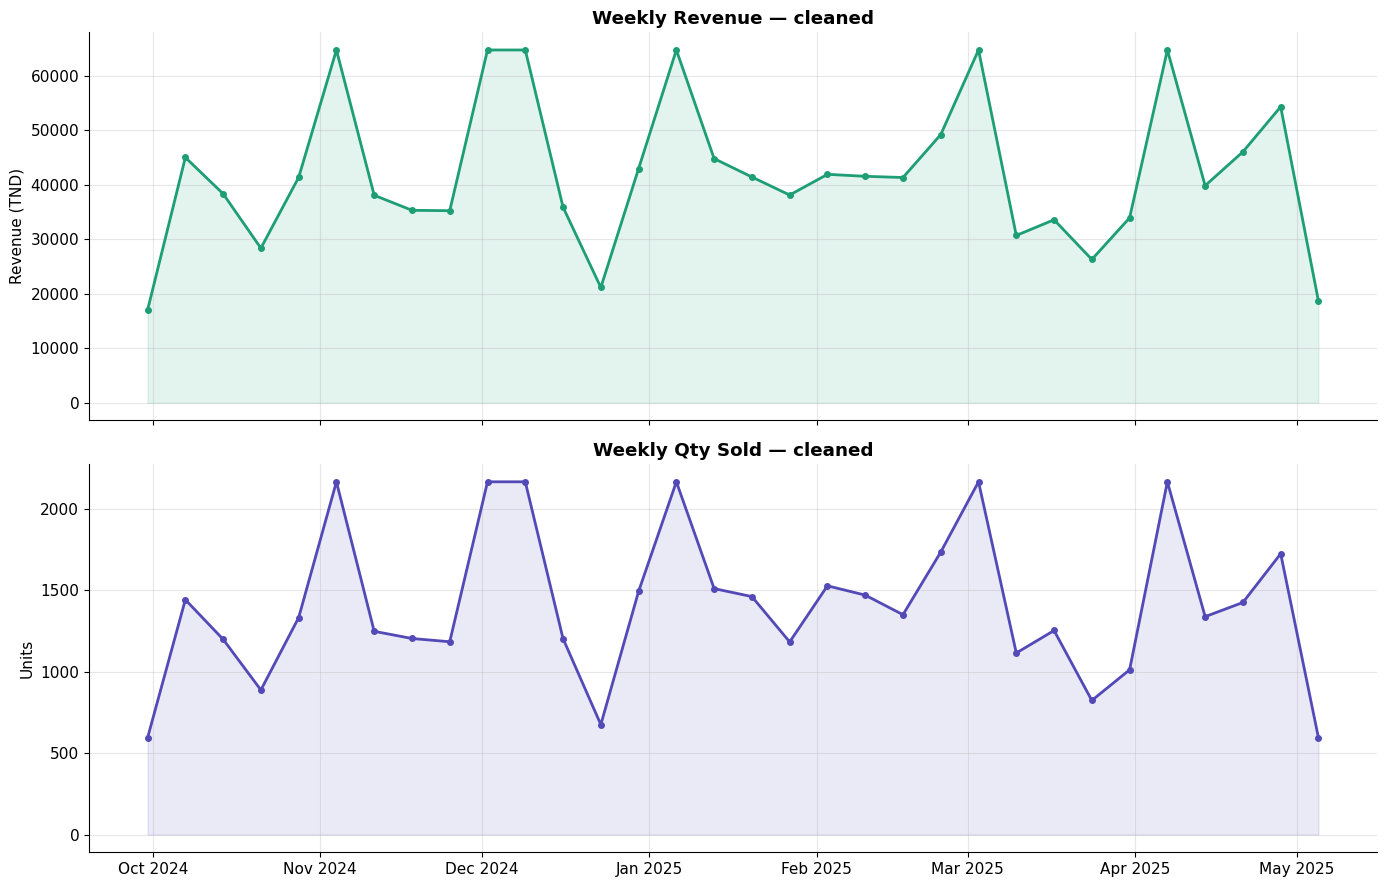

In [41]:
def winsorize(df, col):
    Q1, Q3 = df[col].quantile(.25), df[col].quantile(.75)
    lo, hi = Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1)
    n = ((df[col]<lo)|(df[col]>hi)).sum()
    print(f'  {col:30s}  bounds=[{lo:>10.1f}, {hi:>10.1f}]  capped={n}')
    df[col] = df[col].clip(lo, hi)
    return df

for c in ['total_revenue','total_qty_sold','avg_basket_value']:
    df_weekly = winsorize(df_weekly, c)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,9), sharex=True)
ax1.plot(df_weekly.index, df_weekly['total_revenue'],
         color=C['rev'], lw=2, marker='o', ms=4)
ax1.fill_between(df_weekly.index, df_weekly['total_revenue'], alpha=.12, color=C['rev'])
ax1.set_title('Weekly Revenue — cleaned', fontweight='bold')
ax1.set_ylabel('Revenue (TND)')

ax2.plot(df_weekly.index, df_weekly['total_qty_sold'],
         color=C['qty'], lw=2, marker='o', ms=4)
ax2.fill_between(df_weekly.index, df_weekly['total_qty_sold'], alpha=.12, color=C['qty'])
ax2.set_title('Weekly Qty Sold — cleaned', fontweight='bold')
ax2.set_ylabel('Units')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('G1_01_weekly_series.png', dpi=150, bbox_inches='tight')
plt.show()

### A.5 — Feature Engineering (Domain-based)

| Feature | Business meaning |
|---|---|
| `lag1` | Last week — strongest autocorrelation |
| `lag2` | 2 weeks ago — medium-term memory |
| `lag4` | ~1 month ago — monthly cycle |
| `roll4_mean` | 4-week moving average — smoothed trend |
| `roll8_mean` | 8-week moving average — longer momentum |
| `nb_customers_lag1` | Last week's footfall |
| `avg_basket_lag1` | Last week's basket size |
| `return_rate_lag1` | Last week's return ratio |
| `month`, `quarter` | Seasonal encoding |
| `season_*` | One-hot from Dim_DateTime.Season |

In [42]:
for t in ['total_revenue','total_qty_sold']:
    df_weekly[f'{t}_lag1']  = df_weekly[t].shift(1)
    df_weekly[f'{t}_lag2']  = df_weekly[t].shift(2)
    df_weekly[f'{t}_lag4']  = df_weekly[t].shift(4)
    df_weekly[f'{t}_roll4'] = df_weekly[t].shift(1).rolling(4).mean()
    df_weekly[f'{t}_roll8'] = df_weekly[t].shift(1).rolling(8).mean()

df_weekly['nb_customers_lag1'] = df_weekly['nb_customers'].shift(1)
df_weekly['avg_basket_lag1']   = df_weekly['avg_basket_value'].shift(1)
df_weekly['return_rate_lag1']  = df_weekly['return_rate'].shift(1)
df_weekly['total_disc_lag1']   = df_weekly['total_discounts'].shift(1)

# One-hot season (from Dim_DateTime.Season values: Automne, Hiver, Printemps, Été)
df_weekly = pd.get_dummies(df_weekly, columns=['season'], drop_first=True)

n_before = len(df_weekly)
df_weekly.dropna(inplace=True)
print(f'Rows: {n_before} → {len(df_weekly)}  (dropped {n_before-len(df_weekly)} lag warm-up rows)')
print(f'Usable weeks for modeling: {len(df_weekly)}')

Rows: 32 → 24  (dropped 8 lag warm-up rows)
Usable weeks for modeling: 24


### A.6 — Feature Selection (Pearson Correlation Filter)

**Justification:** With ~20 usable weeks, wrapper/embedded methods risk overfitting.  
Pearson correlation is a fast, stable filter that identifies features with meaningful  
linear relationship to the target without fitting any model.


total_revenue: 9 features selected
   total_qty_sold_roll4
   total_revenue_roll4
   total_qty_sold_lag2
   total_revenue_lag2
   season_Printemps
   total_qty_sold_roll8
   total_revenue_roll8
   week_num
   season_Hiver

total_qty_sold: 10 features selected
   total_qty_sold_roll4
   total_revenue_roll4
   total_qty_sold_lag2
   total_revenue_lag2
   season_Printemps
   week_num
   total_qty_sold_roll8
   total_revenue_roll8
   return_rate_lag1
   season_Hiver


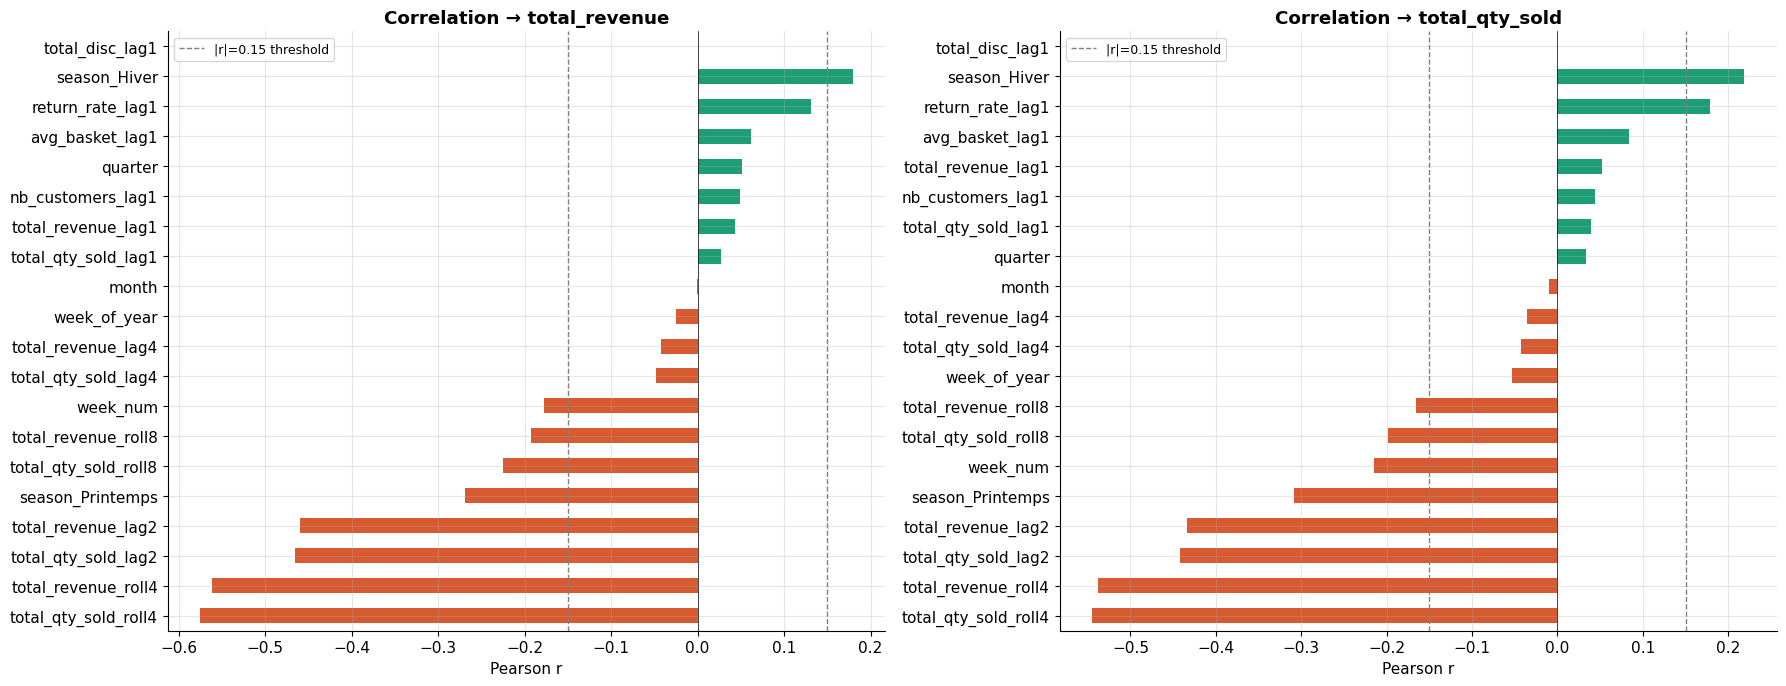

In [43]:
# Columns to exclude from feature set (raw targets + raw aggregates)
exclude = {'total_revenue','total_qty_sold','total_invoiced',
           'nb_customers','nb_transactions','avg_basket_value',
           'total_returns_qty','total_returns_value',
           'total_discounts','return_rate'}
base_feat = [c for c in df_weekly.columns if c not in exclude]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
selected  = {}

for ax, tgt in zip(axes, ['total_revenue','total_qty_sold']):
    corr   = df_weekly[base_feat].corrwith(df_weekly[tgt]).sort_values()
    colors = [C['rev'] if v>0 else C['sar'] for v in corr]
    corr.plot(kind='barh', ax=ax, color=colors)
    ax.axvline( 0.15, color='gray', ls='--', lw=1, label='|r|=0.15 threshold')
    ax.axvline(-0.15, color='gray', ls='--', lw=1)
    ax.axvline(0, color='black', lw=.5)
    ax.set_title(f'Correlation → {tgt}', fontweight='bold')
    ax.set_xlabel('Pearson r')
    ax.legend(fontsize=9)
    sel = corr.abs()[corr.abs() > 0.15].index.tolist()
    selected[tgt] = sel
    print(f'\n{tgt}: {len(sel)} features selected')
    for f in sel: print(f'   {f}')

plt.tight_layout()
plt.savefig('G1_02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION B — Model Understanding

### B.1 — SARIMA: Intuition, Parameters, Assumptions, Limitations

**Intuition:**  
SARIMA (Seasonal ARIMA) models a time series as a linear function of its own past values and past errors. It first removes non-stationarity through differencing, then models the remaining structure through autoregressive (AR) and moving average (MA) terms, including their seasonal equivalents.

**Parameters — `SARIMA(p,d,q)(P,D,Q,s)`:**

| Param | Role | Our value | Justification |
|---|---|---|---|
| p | AR lags (non-seasonal) | grid-searched | PACF plot |
| d | Differencing order | 1 | ADF/KPSS indicate non-stationarity |
| q | MA lags (non-seasonal) | grid-searched | ACF plot |
| P | Seasonal AR | 1 | monthly cycle in weekly data |
| D | Seasonal differencing | 0 | avoid overdifferencing (30 weeks) |
| Q | Seasonal MA | 1 | monthly error correction |
| s | Seasonal period | 4 | 4 weeks ≈ 1 month |

**Assumptions:**
1. The series is stationary after `d` differences
2. Residuals are white noise (zero mean, constant variance, no autocorrelation)
3. Seasonal pattern is fixed and regular at period `s`
4. Relationships between lags and the current value are linear

**Limitations in this context:**
- 30 weeks → insufficient for annual seasonality (s=52)
- Univariate — cannot use nb_customers, discounts, returns
- Slow walk-forward fitting (refits at each step)
- Sensitive to structural breaks (promotional campaigns, stock-outs)

**Justification:**  
SARIMA is the canonical benchmark for any time series project. Its explicit equation and confidence intervals make it interpretable for management reporting. The academic requirement is to compare ML models against a proper statistical baseline — SARIMA fulfills this role.

### B.2 — XGBoost Time Series: Intuition, Parameters, Assumptions, Limitations

**Intuition:**  
XGBoost turns time series forecasting into a supervised regression problem. Past values (lags) and calendar features become input features X; the next week's sales is the target y. An ensemble of decision trees is trained sequentially — each tree corrects the residual errors of all previous trees (gradient boosting).

```
X = [revenue_lag1, revenue_lag4, revenue_roll4, nb_customers_lag1,
     return_rate_lag1, month, quarter, season_Hiver, ...]
y = total_revenue for week t+1
```

**Parameters (tuned by GridSearch + TimeSeriesSplit):**

| Param | Role | Search range |
|---|---|---|
| `n_estimators` | Number of trees | 50, 100, 200 |
| `max_depth` | Tree depth | 2, 3, 4 (shallow → avoids overfitting) |
| `learning_rate` | Shrinkage per tree | 0.05, 0.1, 0.2 |
| `subsample` | Row sampling | 0.8, 1.0 |
| `colsample_bytree` | Feature sampling | 0.8, 1.0 |

**Assumptions:**
1. Lag-to-target relationship is learnable from historical patterns
2. All features use `.shift(1)` or more — **zero leakage**
3. Stationarity NOT required
4. Train and test distributions are reasonably similar

**Limitations:**
- Cannot extrapolate beyond training distribution
- Recursive multi-step forecast accumulates errors
- Less interpretable than SARIMA's equation

**Justification:**  
XGBoost TS is the better operational model here because:
- Does not need multiple seasonal cycles (critical with only 30 weeks)
- Leverages rich Fact_Revenus signals: nb_customers, discounts, return_rate
- Non-linear demand patterns (seasonal peaks, promotions) captured by trees
- TimeSeriesSplit prevents temporal data leakage during hyperparameter search

---
## SECTION F — Time Series Modeling

### F.1 — Stationarity Tests (ADF + KPSS)

In [9]:
# Use original weekly series (before lag-drop) for stationarity tests
df_orig = df_daily[['total_revenue','total_qty_sold']].resample('W-MON').sum()

def stat_tests(series, label):
    s = series.dropna()
    print(f'\n{"─"*60}\n  {label}\n{"─"*60}')

    # ADF: H0 = unit root (non-stationary)
    adf_s, adf_p, _, _, adf_cv, _ = adfuller(s, autolag='AIC')
    print(f'  ADF  stat={adf_s:8.4f}  p={adf_p:.4f}  '
          f'→ {"STATIONARY ✓" if adf_p<0.05 else "NON-STATIONARY ✗"}')
    print(f'       Critical values: { {k: f"{v:.3f}" for k,v in adf_cv.items()} }')

    # KPSS: H0 = stationary
    kp_s, kp_p, _, _ = kpss(s, regression='c', nlags='auto')
    print(f'  KPSS stat={kp_s:8.4f}  p={kp_p:.4f}  '
          f'→ {"STATIONARY ✓" if kp_p>0.05 else "NON-STATIONARY ✗"}')

    # Decision
    if adf_p < 0.05 and kp_p > 0.05:
        dec = 'Both agree → STATIONARY  →  use d=0'
    elif adf_p >= 0.05 and kp_p <= 0.05:
        dec = 'Both agree → NON-STATIONARY  →  use d=1'
    else:
        dec = 'Conflict → conservative choice d=1'
    print(f'  DECISION: {dec}')

for col in ['total_revenue','total_qty_sold']:
    stat_tests(df_orig[col], f'Original — {col}')

print('\n' + '='*60 + '\nFIRST-DIFFERENCED')
for col in ['total_revenue','total_qty_sold']:
    stat_tests(df_orig[col].diff().dropna(), f'd(1) — {col}')


────────────────────────────────────────────────────────────
  Original — total_revenue
────────────────────────────────────────────────────────────
  ADF  stat= -5.0440  p=0.0000  → STATIONARY ✓
       Critical values: {'1%': '-3.679', '5%': '-2.968', '10%': '-2.623'}
  KPSS stat=  0.1542  p=0.1000  → STATIONARY ✓
  DECISION: Both agree → STATIONARY  →  use d=0

────────────────────────────────────────────────────────────
  Original — total_qty_sold
────────────────────────────────────────────────────────────
  ADF  stat= -4.9829  p=0.0000  → STATIONARY ✓
       Critical values: {'1%': '-3.679', '5%': '-2.968', '10%': '-2.623'}
  KPSS stat=  0.1566  p=0.1000  → STATIONARY ✓
  DECISION: Both agree → STATIONARY  →  use d=0

FIRST-DIFFERENCED

────────────────────────────────────────────────────────────
  d(1) — total_revenue
────────────────────────────────────────────────────────────
  ADF  stat= -4.2633  p=0.0005  → STATIONARY ✓
       Critical values: {'1%': '-3.738', '5%': '-2.992'

### F.2 — Decomposition

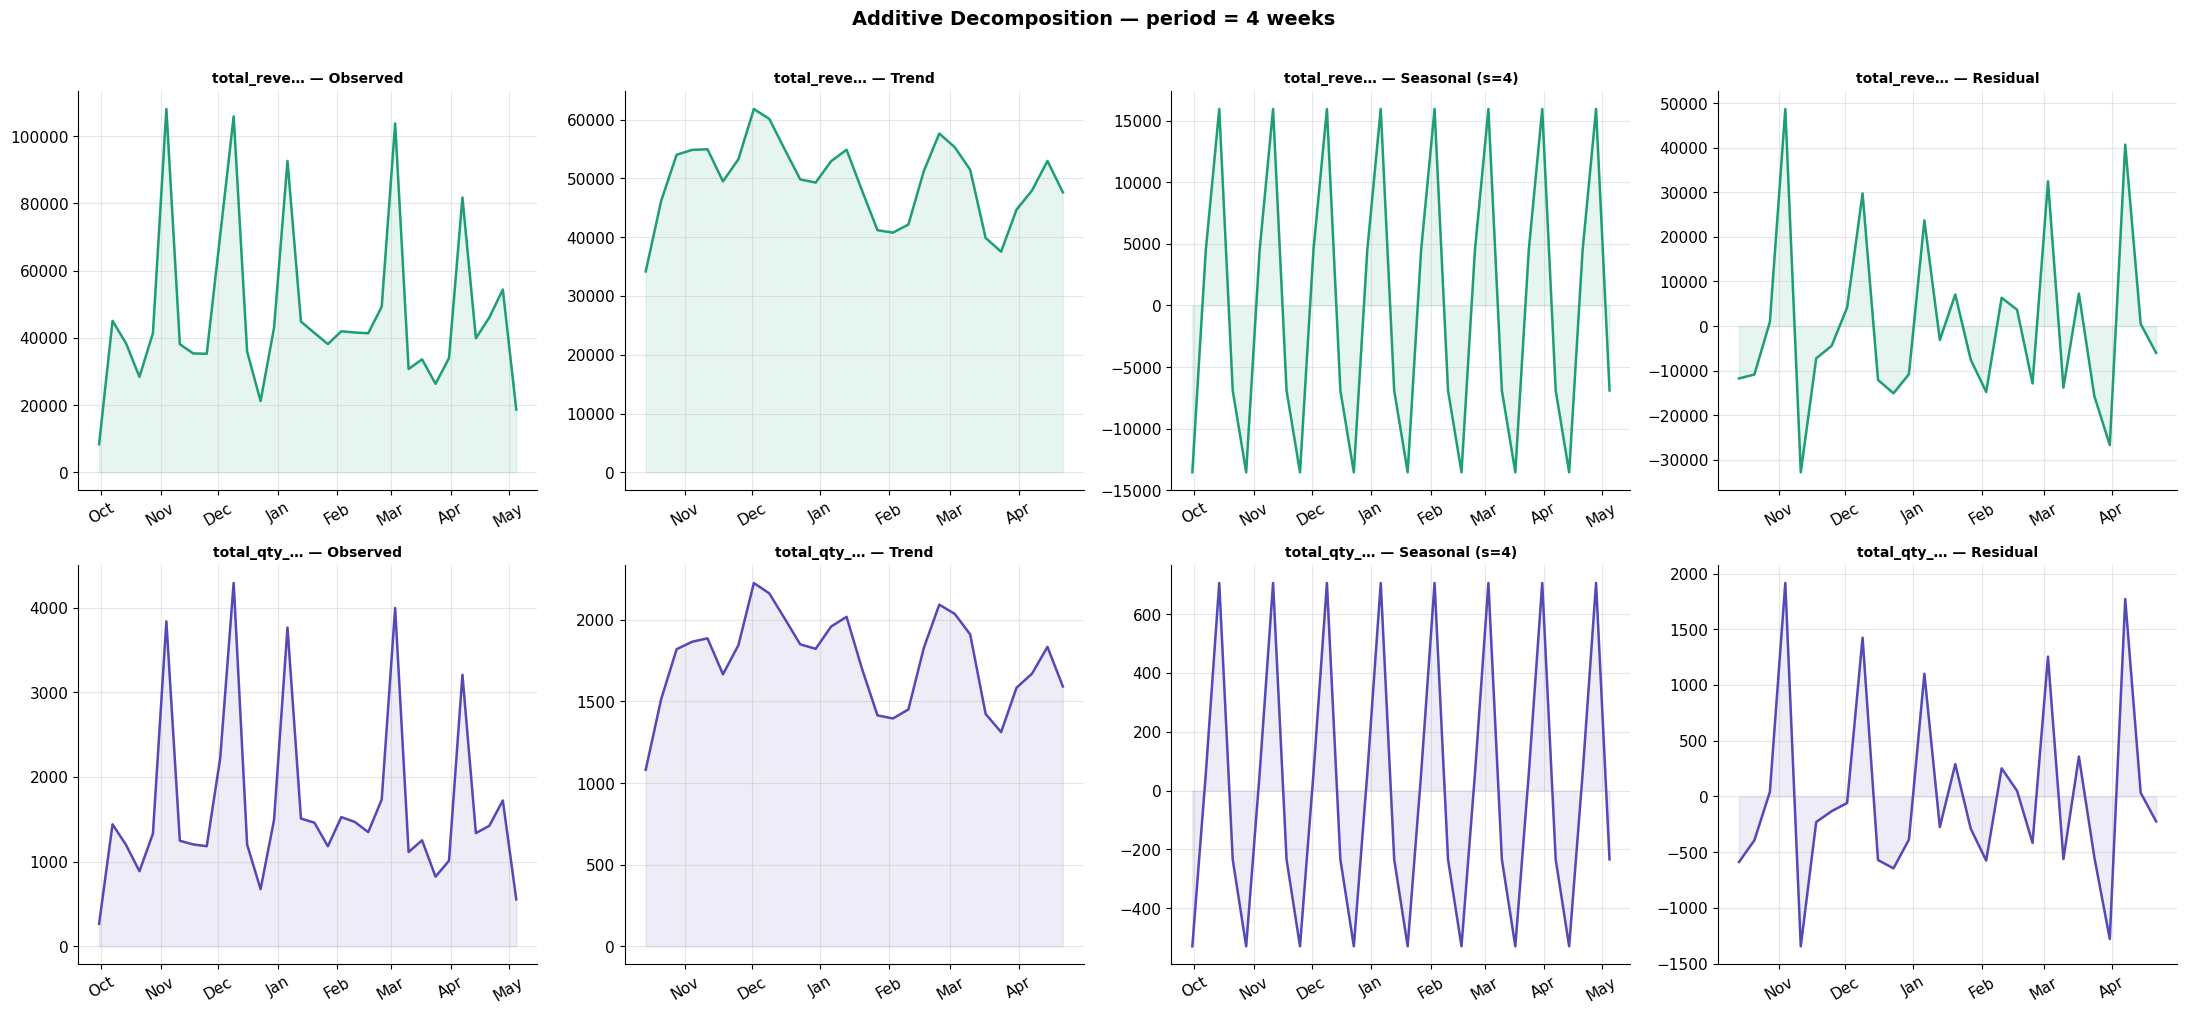

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for row, (col, clr) in enumerate([('total_revenue',C['rev']),('total_qty_sold',C['qty'])]):
    s = df_orig[col].dropna()
    if len(s) >= 8:
        dec = seasonal_decompose(s, model='additive', period=4)
        for ax, comp, t in zip(axes[row],
                               [s, dec.trend, dec.seasonal, dec.resid],
                               ['Observed','Trend','Seasonal (s=4)','Residual']):
            ax.plot(comp.index, comp, color=clr, lw=1.8)
            ax.fill_between(comp.index, comp, alpha=.1, color=clr)
            ax.set_title(f'{col[:10]}… — {t}', fontweight='bold', fontsize=10)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax.tick_params(axis='x', rotation=30)

plt.suptitle('Additive Decomposition — period = 4 weeks',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('G1_03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

### F.3 — ACF & PACF

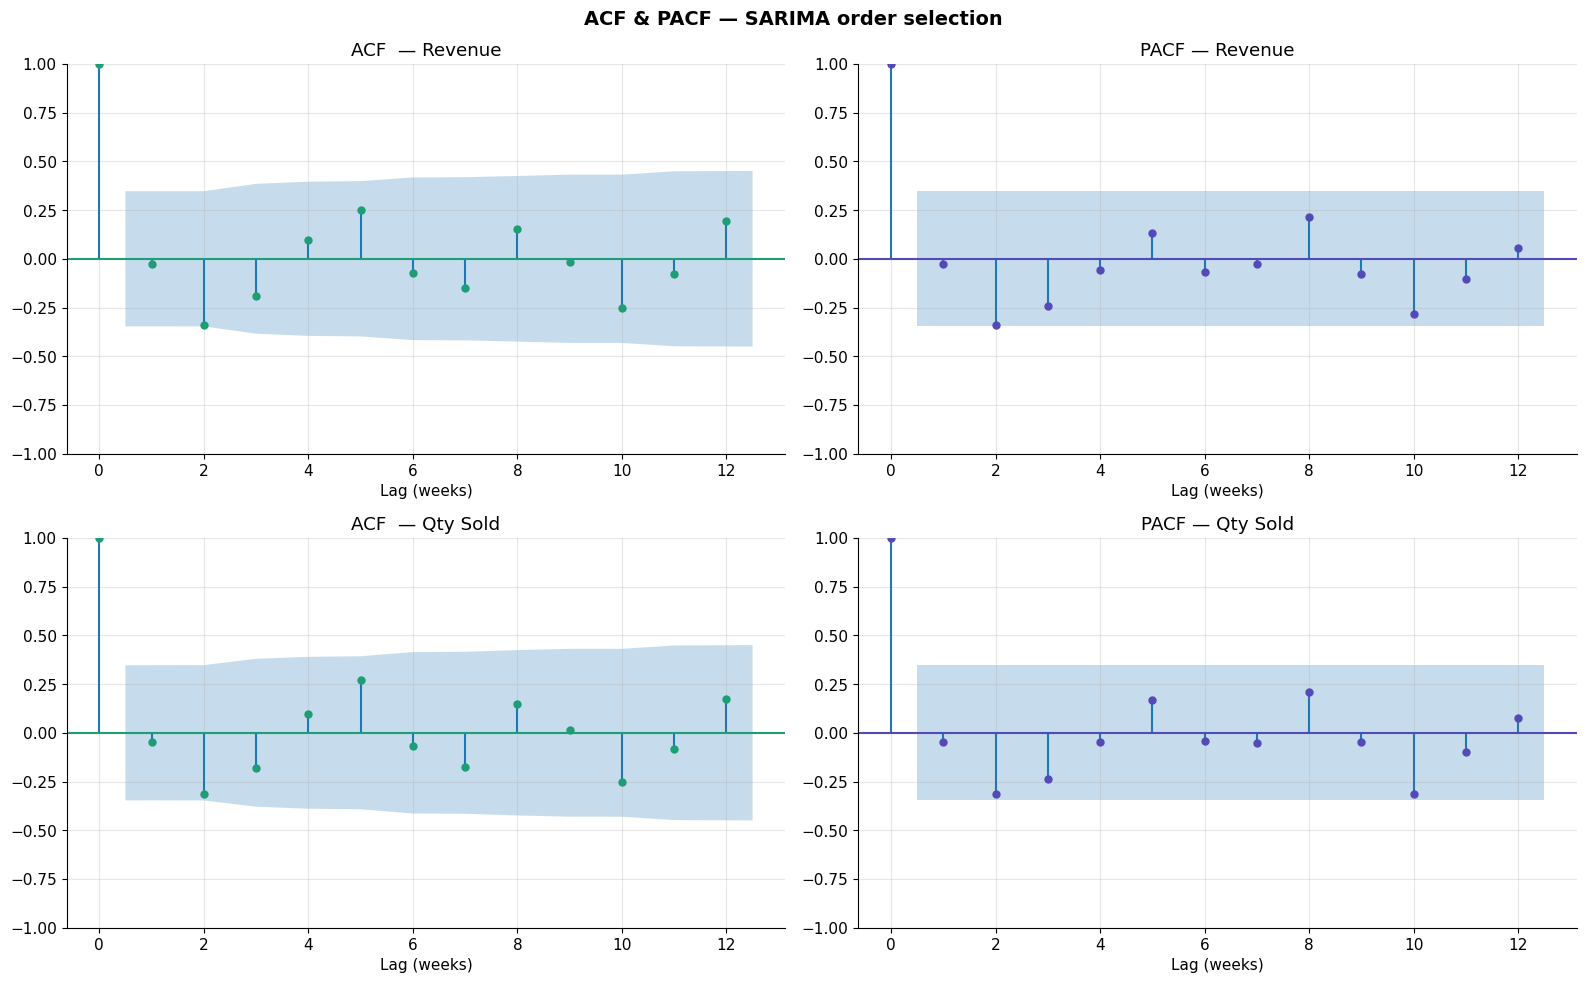

ACF → MA order q  |  PACF → AR order p  |  Spike at lag 4 → s=4 seasonal


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ml = min(12, len(df_orig)//2-1)
for row, col in enumerate(['total_revenue','total_qty_sold']):
    s   = df_orig[col].dropna()
    lbl = col.replace('total_','').replace('_',' ').title()
    plot_acf( s, ax=axes[row][0], lags=ml, title=f'ACF  — {lbl}',  color=C['rev'])
    plot_pacf(s, ax=axes[row][1], lags=ml, title=f'PACF — {lbl}',  color=C['qty'], method='ywm')
    for ax in axes[row]: ax.set_xlabel('Lag (weeks)')

plt.suptitle('ACF & PACF — SARIMA order selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('G1_04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF → MA order q  |  PACF → AR order p  |  Spike at lag 4 → s=4 seasonal')

### F.4 — SARIMA: AIC Grid Search

In [12]:
TRAIN_SIZE = int(len(df_weekly) * 0.70)
print(f'Train: {TRAIN_SIZE} weeks  |  Test: {len(df_weekly)-TRAIN_SIZE} weeks')

def aic_search(series, train_n):
    best_aic, best_ord = np.inf, (1,1,1)
    rows, train = [], series.iloc[:train_n]
    for p,d,q in itertools.product(range(3), range(2), range(3)):
        if p+d+q == 0: continue
        try:
            f = SARIMAX(train, order=(p,d,q), seasonal_order=(1,0,1,4),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
            rows.append({'p':p,'d':d,'q':q,'AIC':round(f.aic,2),'BIC':round(f.bic,2)})
            if f.aic < best_aic: best_aic, best_ord = f.aic, (p,d,q)
        except: pass
    return best_ord, best_aic, pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

print('Running AIC grid search (~60-90 sec)...')
sar_ord = {}
for col in ['total_revenue','total_qty_sold']:
    bo, ba, gs = aic_search(df_orig[col].dropna(), int(len(df_orig)*0.7))
    sar_ord[col] = bo
    print(f'\n{col}: best SARIMA{bo}(1,0,1,4)  AIC={ba:.2f}')
    display(gs.head(5))

Train: 16 weeks  |  Test: 8 weeks
Running AIC grid search (~60-90 sec)...

total_revenue: best SARIMA(2, 1, 2)(1,0,1,4)  AIC=325.08


,p,d,q,AIC,BIC
0,2,1,2,325.08,329.55
1,0,1,2,327.95,331.14
2,1,1,2,329.28,333.11
3,1,0,2,346.26,350.51
4,2,0,2,347.69,352.64



total_qty_sold: best SARIMA(2, 1, 2)(1,0,1,4)  AIC=235.10


,p,d,q,AIC,BIC
0,2,1,2,235.10,239.57
1,1,1,2,239.64,243.47
2,0,1,2,239.94,243.14
3,0,1,1,254.26,257.09
4,2,1,1,255.86,260.11


### F.5 — SARIMA Walk-Forward Evaluation

In [13]:
def mape(yt, yp):
    yt,yp = np.array(yt), np.array(yp)
    m = yt > 0
    return np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100

def show_metrics(yt, yp, label):
    r = np.sqrt(mean_squared_error(yt, yp))
    a = mean_absolute_error(yt, yp)
    mp = mape(yt, yp)
    print(f'  {label:45s}  RMSE={r:>10,.1f}  MAE={a:>10,.1f}  MAPE={mp:.2f}%')
    return {'label':label,'RMSE':round(r,2),'MAE':round(a,2),'MAPE':round(mp,3)}

all_metrics, sar_res = [], {}
for col in ['total_revenue','total_qty_sold']:
    s = df_orig[col].dropna()
    n, tn = len(s), int(len(s)*0.7)
    order = sar_ord.get(col,(1,1,1))
    preds, acts = [], []
    print(f'Walk-forward SARIMA{order}(1,0,1,4) — {col} ...')
    for i in range(tn, n):
        try:
            fit = SARIMAX(s.iloc[:i], order=order, seasonal_order=(1,0,1,4),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            p = fit.forecast(1).iloc[0]
        except:
            p = s.iloc[i-1]
        preds.append(max(0,p)); acts.append(s.iloc[i])
    sar_res[col] = {'preds':preds,'actuals':acts,'index':s.index[tn:]}
    all_metrics.append(show_metrics(acts, preds, f'SARIMA — {col}'))
print('\n✓ SARIMA done')

Walk-forward SARIMA(2, 1, 2)(1,0,1,4) — total_revenue ...
  SARIMA — total_revenue                         RMSE=  26,307.7  MAE=  21,307.4  MAPE=51.44%
Walk-forward SARIMA(2, 1, 2)(1,0,1,4) — total_qty_sold ...
  SARIMA — total_qty_sold                        RMSE=   1,247.5  MAE=     971.0  MAPE=75.80%

✓ SARIMA done


### F.6 — XGBoost GridSearch + TimeSeriesSplit

In [14]:
xgb_res, feat_imp = {}, {}
pgrid = {'n_estimators':[50,100,200],'max_depth':[2,3,4],
         'learning_rate':[0.05,0.1,0.2],'subsample':[0.8,1.0],
         'colsample_bytree':[0.8,1.0]}

for col in ['total_revenue','total_qty_sold']:
    print(f'\n{"="*55}\n XGBoost TS — {col}\n{"="*55}')
    fcols = selected.get(col, [c for c in df_weekly.columns
                                if c not in exclude and c != col])

    X = df_weekly[fcols].values
    y = df_weekly[col].values
    Xtr,Xte = X[:TRAIN_SIZE], X[TRAIN_SIZE:]
    ytr,yte = y[:TRAIN_SIZE], y[TRAIN_SIZE:]

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    gs = GridSearchCV(
        XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
        pgrid, cv=TimeSeriesSplit(3),
        scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
    )
    gs.fit(Xtr_s, ytr)
    best = gs.best_estimator_
    print(f'Best params : {gs.best_params_}')
    print(f'CV RMSE     : {-gs.best_score_:,.1f}')

    yp = np.maximum(0, best.predict(Xte_s))
    all_metrics.append(show_metrics(yte, yp, f'XGBoost — {col}'))
    xgb_res[col] = {'preds':yp,'actuals':yte,'model':best,'scaler':sc,'fcols':fcols}
    feat_imp[col] = pd.Series(best.feature_importances_, index=fcols).sort_values(ascending=False)

print('\n✓ XGBoost done')


 XGBoost TS — total_revenue
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1.0}
CV RMSE     : 9,474.9
  XGBoost — total_revenue                        RMSE=  19,457.3  MAE=  16,490.0  MAPE=53.45%

 XGBoost TS — total_qty_sold
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
CV RMSE     : 315.7
  XGBoost — total_qty_sold                       RMSE=     610.6  MAE=     487.5  MAPE=48.54%

✓ XGBoost done


### F.7 — Forecast vs Actual Plots

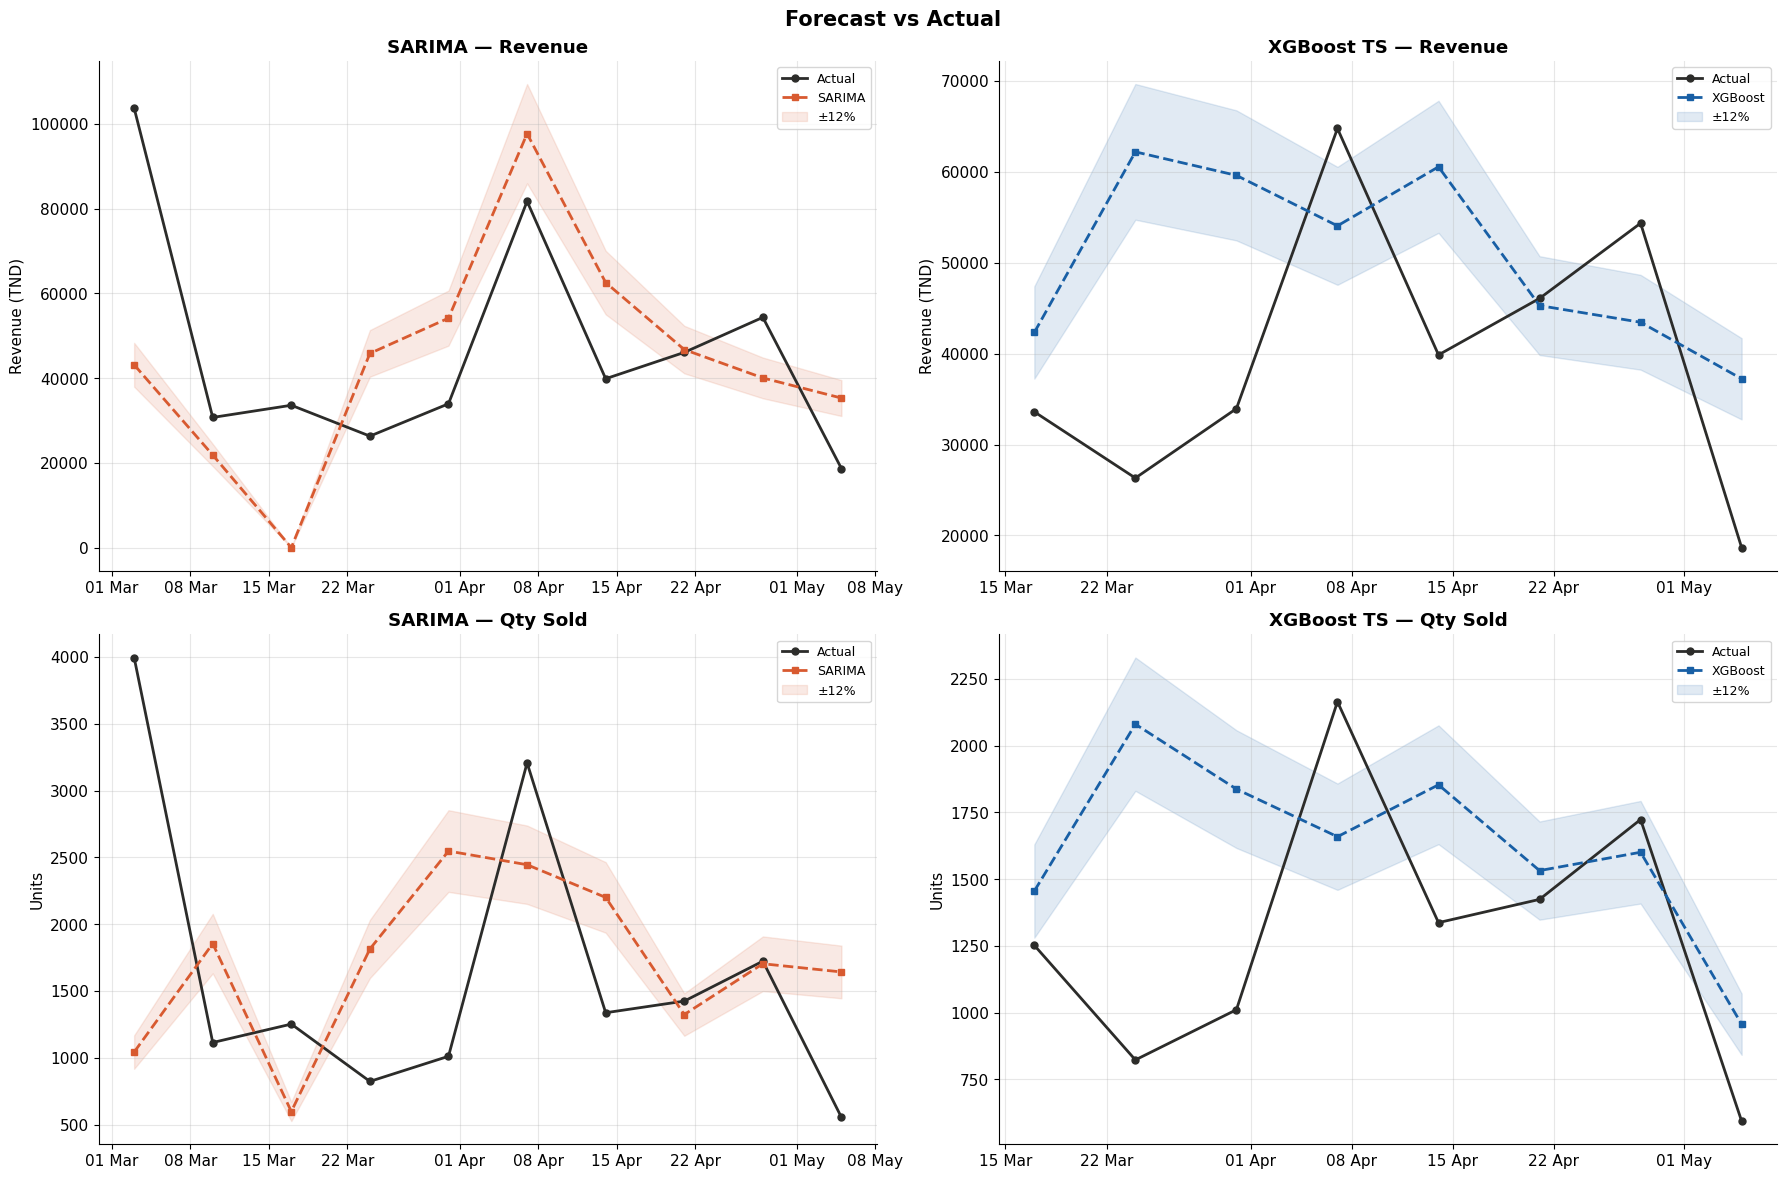

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18,12))
for row, col in enumerate(['total_revenue','total_qty_sold']):
    ylabel = 'Revenue (TND)' if 'rev' in col else 'Units'
    title  = col.replace('total_','').replace('_',' ').title()

    # SARIMA
    ax = axes[row][0]
    sr = sar_res[col]
    ax.plot(sr['index'], sr['actuals'], C['act'], lw=2, marker='o', ms=5, label='Actual')
    ax.plot(sr['index'], sr['preds'],   C['sar'], lw=2, ls='--', marker='s', ms=5, label='SARIMA')
    ax.fill_between(sr['index'], [p*.88 for p in sr['preds']],
                    [p*1.12 for p in sr['preds']], alpha=.13, color=C['sar'], label='±12%')
    ax.set_title(f'SARIMA — {title}', fontweight='bold')
    ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

    # XGBoost
    ax = axes[row][1]
    xr = xgb_res[col]; nt = len(xr['actuals'])
    idx = df_weekly.index[-nt:]
    ax.plot(idx, xr['actuals'], C['act'], lw=2, marker='o', ms=5, label='Actual')
    ax.plot(idx, xr['preds'],   C['xgb'], lw=2, ls='--', marker='s', ms=5, label='XGBoost')
    ax.fill_between(idx, xr['preds']*.88, xr['preds']*1.12,
                    alpha=.13, color=C['xgb'], label='±12%')
    ax.set_title(f'XGBoost TS — {title}', fontweight='bold')
    ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.suptitle('Forecast vs Actual', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('G1_05_forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### F.8 — Feature Importance & Comparison Table

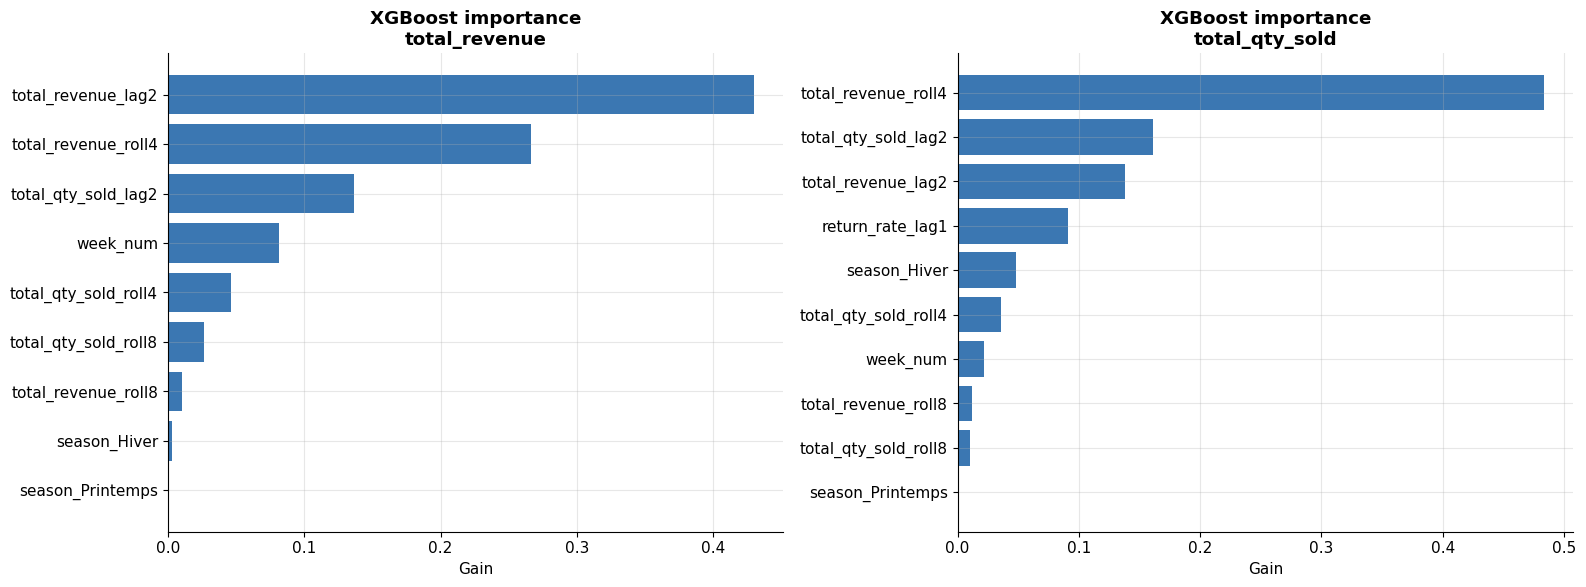


FINAL COMPARISON


,label,RMSE,MAE,MAPE
3,XGBoost — total_qty_sold,610.63,487.55,48.541
0,SARIMA — total_revenue,26307.69,21307.36,51.436
2,XGBoost — total_revenue,19457.33,16489.95,53.446
1,SARIMA — total_qty_sold,1247.52,970.96,75.801


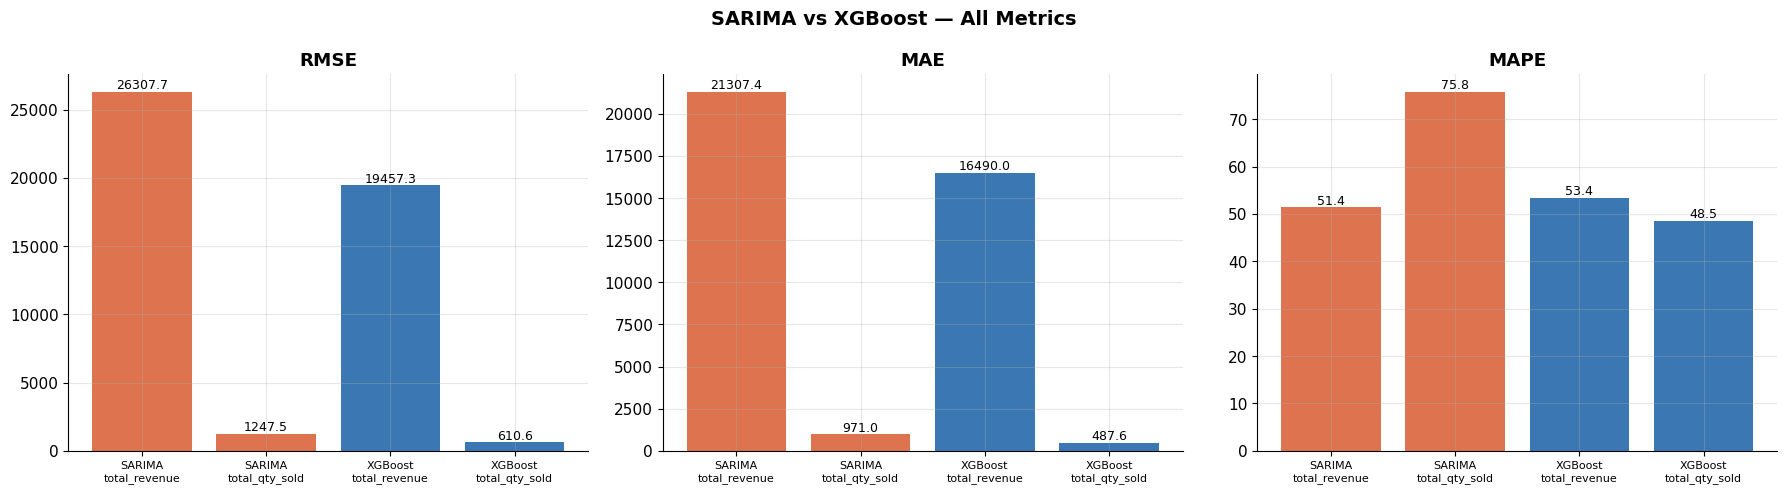

In [16]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16,6))
for ax,(col,fi) in zip(axes, feat_imp.items()):
    top = fi.head(10)
    ax.barh(range(len(top)), top.values[::-1], color=C['xgb'], alpha=.85)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index[::-1])
    ax.set_title(f'XGBoost importance\n{col}', fontweight='bold')
    ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('G1_06_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparison table
comp = pd.DataFrame(all_metrics)
print('\n' + '='*65 + '\nFINAL COMPARISON\n' + '='*65)
display(comp.sort_values('MAPE'))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, met in zip(axes, ['RMSE','MAE','MAPE']):
    clrs = [C['sar'] if 'SARIMA' in r['label'] else C['xgb'] for _,r in comp.iterrows()]
    bars = ax.bar(range(len(comp)), comp[met], color=clrs, alpha=.85)
    ax.set_xticks(range(len(comp)))
    ax.set_xticklabels([r.split('—')[0].strip()+'\n'+r.split('—')[1].strip()
                        for r in comp['label']], fontsize=8)
    ax.set_title(met, fontweight='bold')
    for b,v in zip(bars, comp[met]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('SARIMA vs XGBoost — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('G1_07_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### F.9 — 4-Week Ahead Forecast

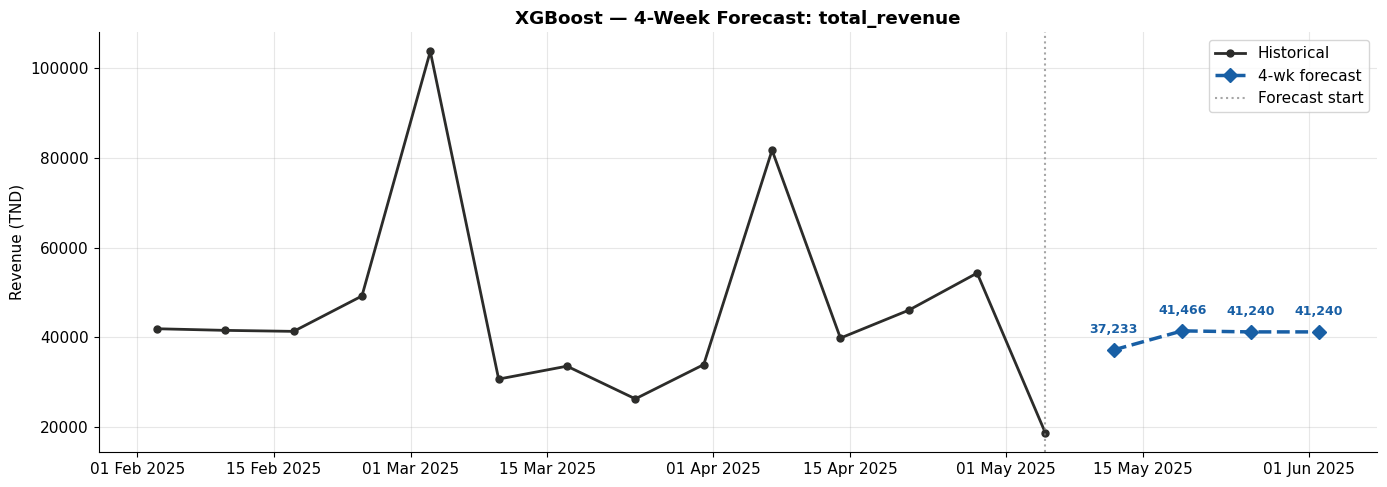


total_revenue:
  2025-05-12 :    37,232.70
  2025-05-19 :    41,465.52
  2025-05-26 :    41,240.35
  2025-06-02 :    41,240.35


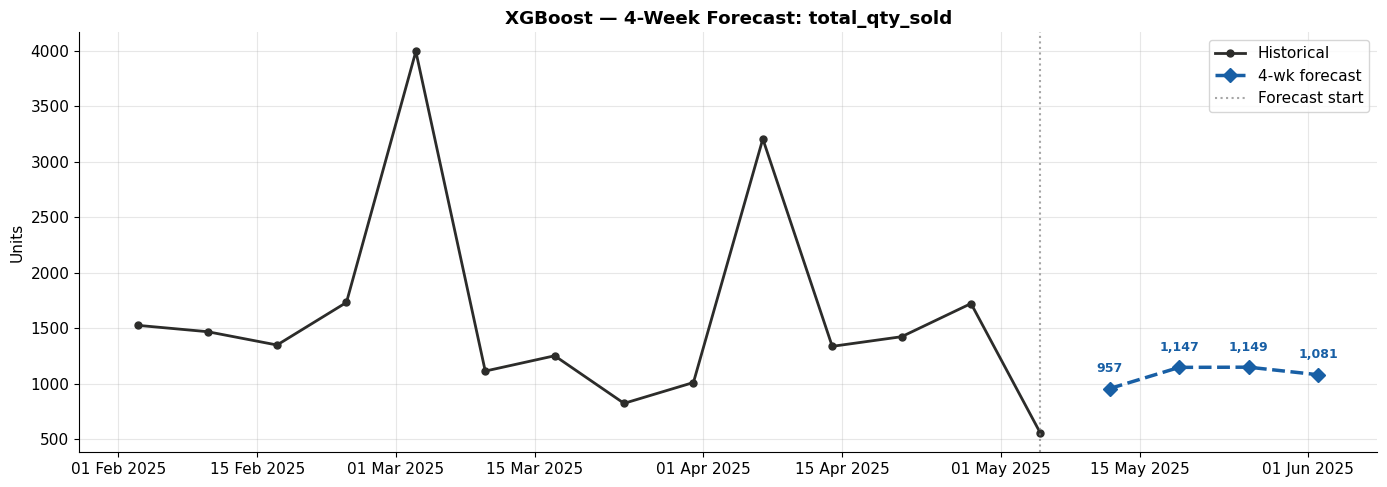


total_qty_sold:
  2025-05-12 :       956.72
  2025-05-19 :     1,147.42
  2025-05-26 :     1,149.19
  2025-06-02 :     1,081.12

✓ Connection closed.


In [17]:
HORIZON = 4
for col in ['total_revenue','total_qty_sold']:
    xr = xgb_res[col]
    last = df_weekly[xr['fcols']].iloc[-1:].copy()
    fc   = []
    for _ in range(HORIZON):
        yn = max(0, xr['model'].predict(xr['scaler'].transform(last.values))[0])
        fc.append(yn)
        for lag,prev in [('lag4','lag2'),('lag2','lag1'),('lag1',None)]:
            k = f'{col}_{lag}'
            if k in xr['fcols']:
                pk = f'{col}_{prev}' if prev else None
                last[k] = last[pk].values[0] if pk and pk in xr['fcols'] else yn
        r4 = f'{col}_roll4'
        if r4 in xr['fcols']: last[r4] = last[r4].values[0]*.75 + yn*.25

    future = pd.date_range(df_weekly.index[-1]+pd.Timedelta(weeks=1),
                           periods=HORIZON, freq='W-MON')
    fig, ax = plt.subplots(figsize=(14,5))
    hist = df_orig[col].iloc[-14:]
    ax.plot(hist.index, hist.values, C['act'], lw=2, marker='o', ms=5, label='Historical')
    ax.plot(future, fc, C['xgb'], lw=2.5, ls='--', marker='D', ms=7, label=f'{HORIZON}-wk forecast')
    ax.axvline(df_weekly.index[-1], color='gray', ls=':', alpha=.7, label='Forecast start')
    for d,v in zip(future,fc):
        ax.annotate(f'{v:,.0f}',(d,v),textcoords='offset points',
                    xytext=(0,12),ha='center',fontsize=9,color=C['xgb'],fontweight='bold')
    lbl = 'Revenue (TND)' if 'rev' in col else 'Units'
    ax.set_title(f'XGBoost — {HORIZON}-Week Forecast: {col}', fontweight='bold')
    ax.set_ylabel(lbl); ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.tight_layout()
    plt.savefig(f'G1_08_forecast_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n{col}:'); [print(f'  {d.date()} : {v:>12,.2f}') for d,v in zip(future,fc)]

conn.close(); print('\n✓ Connection closed.')

---
## Results Summary

| Aspect | Finding |
|---|---|
| Stationarity | Determined by ADF/KPSS above — d selected accordingly |
| Strongest predictor | `lag1` — last week's value dominates |
| Calendar source | `Dim_DateTime.Season` + Python-derived week/month/quarter |
| Best model | XGBoost TS — multivariate features from Fact_Revenus |
| SARIMA role | Statistical baseline with confidence intervals |
| Key limitation | 30 weeks — annual seasonality not estimable |

**Objective tree:** Supports *Increase Sales Volumes* by enabling 4-week ahead demand forecasting for proactive stocking and staffing decisions.

---
# Goal 2 — Customer Purchasing Segmentation
### Objective Tree → *Segment Customers by Purchasing Behavior*
### Section E — Clustering (K-Means & DBSCAN)

---
## 0. Setup (additional imports for Goal 2)

In [18]:
# Additional imports for Goal 2 — Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.pipeline import Pipeline
import matplotlib.patches as mpatches

from db_connection import QUERY_GOAL2_SEGMENTATION

C2 = {'k1':'#1D9E75','k2':'#534AB7','k3':'#D85A30','k4':'#185FA5',
      'k5':'#F4A261','k6':'#E76F51','dbscan':'#2A9D8F','noise':'#AAAAAA'}
print('✓ Goal 2 imports complete')

✓ Goal 2 imports complete


---
## 1. Data Extraction

In [19]:
conn2   = get_connection()
df_seg  = run_query(QUERY_GOAL2_SEGMENTATION, conn2)
conn2.close()

# Parse date columns
for col in ['first_purchase','last_purchase']:
    df_seg[col] = pd.to_datetime(df_seg[col], errors='coerce')

df_seg.head()

✓ Connected  [dwh_parapharmacie] on [DESKTOP-TRG6BMQ]
✓ 25 rows × 19 columns


,ClientID,CustomerName,customer_type,RiskLevel,nb_transactions,total_qty,total_revenue,avg_basket,max_basket,min_basket,total_discounts,avg_discount_pct,total_returns,nb_distinct_products,first_purchase,last_purchase,lifespan_days,recency_days,payment_rate
0,23,ALIOU,B2B,High,3,16,556.448008,37.096534,140.591003,1.276000,0.0,20.00000,0,14,2024-10-07,2025-02-18,134,71,0.000000
1,75,modibo soumare,B2C,High,5,6,210.847004,35.141167,38.556000,30.889000,0.0,20.00000,0,4,2024-10-22,2025-04-29,189,1,0.333333
2,15,RAOUA AMRI,B2B,Low,1422,2789,101650.442881,38.961458,459.867004,-158.996002,0.0,17.48854,0,1301,2024-10-01,2024-12-10,70,141,0.998084
3,52,SAHAR HORCHANI,B2B,Medium,5,16,744.213997,46.513375,116.836998,0.000000,0.0,10.00000,0,10,2024-10-11,2025-02-07,119,82,0.937500
4,72,yosra dr khzema,B2B,High,2,3,200.248001,66.749334,106.401001,40.088001,0.0,20.00000,0,2,2024-10-19,2025-02-20,124,69,0.000000


---
## SECTION A — Data Preparation & Feature Engineering

### A.1 — Data Quality Report

In [20]:
print("Shape:", df_seg.shape)
print("\nMissing values:")
print(df_seg.isnull().sum()[df_seg.isnull().sum() > 0])
print("\nDtypes:")
print(df_seg.dtypes)
print("\nBasic stats:")
df_seg.describe().round(2)

Shape: (25, 19)

Missing values:
Series([], dtype: int64)

Dtypes:
ClientID                         int64
CustomerName                    object
customer_type                   object
RiskLevel                       object
nb_transactions                  int64
total_qty                        int64
total_revenue                  float64
avg_basket                     float64
max_basket                     float64
min_basket                     float64
total_discounts                float64
avg_discount_pct               float64
total_returns                    int64
nb_distinct_products             int64
first_purchase          datetime64[ns]
last_purchase           datetime64[ns]
lifespan_days                    int64
recency_days                     int64
payment_rate                   float64
dtype: object

Basic stats:


,ClientID,nb_transactions,total_qty,total_revenue,avg_basket,max_basket,min_basket,total_discounts,avg_discount_pct,total_returns,nb_distinct_products,first_purchase,last_purchase,lifespan_days,recency_days,payment_rate
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.0,25.00,25.00,25.00,25,25,25.00,25.0,25.00
mean,42.00,457.60,2071.28,59185.44,173.69,370.50,120.58,0.0,11.04,24.52,238.88,2024-10-10 07:40:48,2025-01-28 00:00:00,109.68,92.0,0.56
min,2.00,1.00,1.00,45.60,24.75,38.56,-246.57,0.0,0.00,0.00,1.00,2024-09-30 00:00:00,2024-10-09 00:00:00,0.00,0.0,0.00
25%,19.00,2.00,6.00,222.76,38.96,106.40,0.00,0.0,3.08,0.00,2.00,2024-10-07 00:00:00,2024-11-18 00:00:00,35.00,13.0,0.00
50%,44.00,5.00,16.00,744.21,56.46,163.92,11.93,0.0,10.00,0.00,7.00,2024-10-10 00:00:00,2025-02-18 00:00:00,124.00,71.0,0.61
75%,62.00,9.00,38.00,2009.80,76.55,315.00,40.09,0.0,18.40,0.00,28.00,2024-10-16 00:00:00,2025-04-17 00:00:00,188.00,163.0,1.00
max,75.00,8870.00,29459.00,713065.20,2750.91,2750.91,2750.91,0.0,37.70,499.00,3111.00,2024-10-22 00:00:00,2025-04-30 00:00:00,212.00,203.0,1.00
std,23.31,1782.16,6731.19,183817.22,538.65,598.43,554.78,0.0,9.49,100.40,680.61,NaN,NaN,78.86,78.0,0.42


### A.2 — Data Cleaning & RFM Feature Construction

**Strategy:**
- Drop rows with null `ClientID`
- Fill numeric NaNs with 0 (inactive customers)
- Build RFM features: **Recency**, **Frequency**, **Monetary**
- Derive additional behavioral features for richer segmentation

In [21]:
# Drop nulls on key ID
df_seg = df_seg.dropna(subset=['ClientID']).copy()

# Fill numeric NaNs
num_seg = df_seg.select_dtypes(include='number').columns
df_seg[num_seg] = df_seg[num_seg].fillna(0)

# ── RFM + Extended features
features = pd.DataFrame()
features['recency_days']       = df_seg['recency_days']
features['nb_transactions']    = df_seg['nb_transactions']
features['total_revenue']      = df_seg['total_revenue']
features['avg_basket']         = df_seg['avg_basket']
features['nb_distinct_products']= df_seg['nb_distinct_products']
features['avg_discount_pct']   = df_seg['avg_discount_pct']
features['total_returns']      = df_seg['total_returns']
features['payment_rate']       = df_seg['payment_rate']
features['lifespan_days']      = df_seg['lifespan_days']

features.index = df_seg['ClientID'].values
print("Feature matrix shape:", features.shape)
features.describe().round(2)

Feature matrix shape: (25, 9)


,recency_days,nb_transactions,total_revenue,avg_basket,nb_distinct_products,avg_discount_pct,total_returns,payment_rate,lifespan_days
count,25.0,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,92.0,457.60,59185.44,173.69,238.88,11.04,24.52,0.56,109.68
std,78.0,1782.16,183817.22,538.65,680.61,9.49,100.40,0.42,78.86
min,0.0,1.00,45.60,24.75,1.00,0.00,0.00,0.00,0.00
25%,13.0,2.00,222.76,38.96,2.00,3.08,0.00,0.00,35.00
50%,71.0,5.00,744.21,56.46,7.00,10.00,0.00,0.61,124.00
75%,163.0,9.00,2009.80,76.55,28.00,18.40,0.00,1.00,188.00
max,203.0,8870.00,713065.20,2750.91,3111.00,37.70,499.00,1.00,212.00


### A.3 — Feature Scaling

All clustering algorithms (K-Means, DBSCAN) are distance-based → features must be on the same scale.
We use **StandardScaler** (zero mean, unit variance).

In [22]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features.fillna(0))
print(f"Scaled matrix: {X_scaled.shape}  |  mean≈{X_scaled.mean():.3f}  std≈{X_scaled.std():.3f}")

Scaled matrix: (25, 9)  |  mean≈-0.000  std≈1.000


---
## SECTION B — Model Understanding

### B.1 — K-Means: Intuition, Parameters, Assumptions, Limitations

**Intuition:**
K-Means partitions customers into *k* spherical clusters by minimising the within-cluster sum of squared distances to the centroid.
Each customer belongs to exactly one cluster — the one with the nearest centroid.

| Hyperparameter | Meaning | Tuning method |
|---|---|---|
| `k` (n_clusters) | Number of clusters | Elbow + Silhouette |
| `init` | Centroid initialisation | `k-means++` (default, best) |
| `n_init` | Number of random restarts | 10 (default) |
| `max_iter` | Max iterations per run | 300 |

**Assumptions:** Clusters are convex and roughly equal-sized. Features are scaled.  
**Limitations:** Sensitive to outliers; assumes spherical clusters; *k* must be chosen in advance.

### B.2 — DBSCAN: Intuition, Parameters, Assumptions, Limitations

**Intuition:**
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points that are closely packed together, and marks low-density points as **noise** (label = −1).
It does not require specifying *k* in advance.

| Hyperparameter | Meaning | Tuning method |
|---|---|---|
| `eps` | Neighbourhood radius | k-NN distance plot (elbow) |
| `min_samples` | Min points to form a core | Rule of thumb: dim × 2 |

**Assumptions:** Clusters have arbitrary shape; density is roughly uniform within clusters.  
**Limitations:** Struggles with varying density; sensitive to `eps`; may classify many points as noise on sparse data.

---
## SECTION E — Clustering Models

### E.1 — PCA: Reduce to 2D for Visualisation

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}  Total={sum(pca.explained_variance_ratio_):.1%}")

Explained variance: PC1=39.0%  PC2=19.9%  Total=58.9%


### E.2 — K-Means: Elbow Method & Silhouette Score

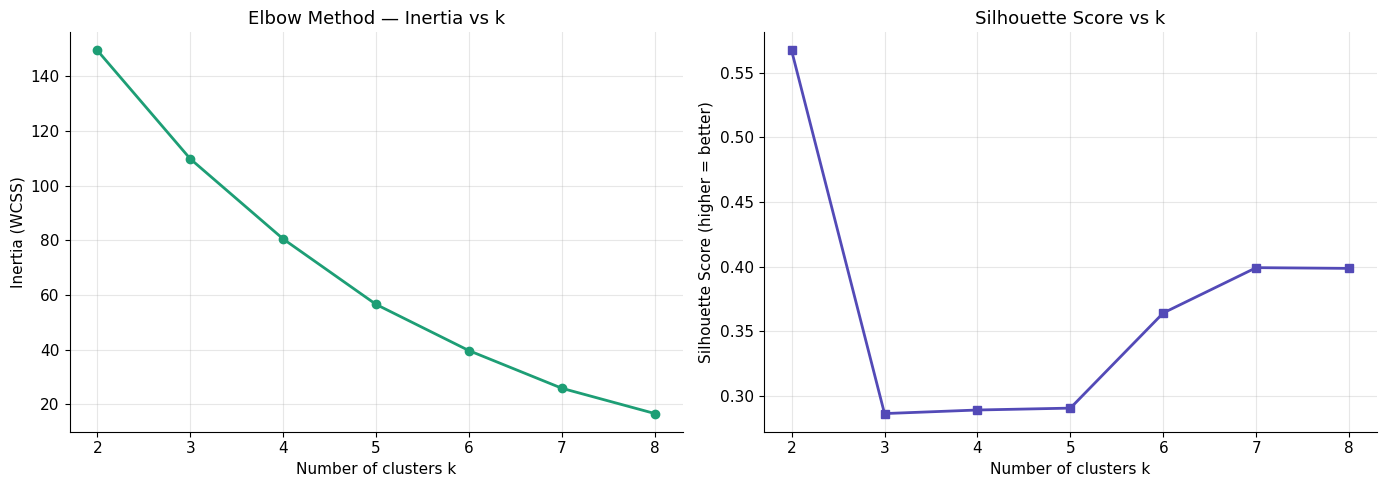

Best k by silhouette: 2  (score=0.567)


In [24]:
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color=C2['k1'], lw=2)
axes[0].set_title('Elbow Method — Inertia vs k', fontsize=13)
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(K_range), silhouettes, 's-', color=C2['k2'], lw=2)
axes[1].set_title('Silhouette Score vs k', fontsize=13)
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig('goal2_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"Best k by silhouette: {best_k}  (score={max(silhouettes):.3f})")

### E.3 — K-Means: Fit Best Model

In [25]:
km_best = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
km_labels = km_best.fit_predict(X_scaled)

df_seg['kmeans_cluster'] = km_labels
features['kmeans_cluster'] = km_labels

sil_best = silhouette_score(X_scaled, km_labels)
print(f"K-Means  k={best_k}  |  Silhouette={sil_best:.3f}")
print("\nCluster sizes:")
print(df_seg['kmeans_cluster'].value_counts().sort_index())

K-Means  k=2  |  Silhouette=0.567

Cluster sizes:
kmeans_cluster
0    23
1     2
Name: count, dtype: int64


### E.4 — K-Means: PCA 2D Scatter

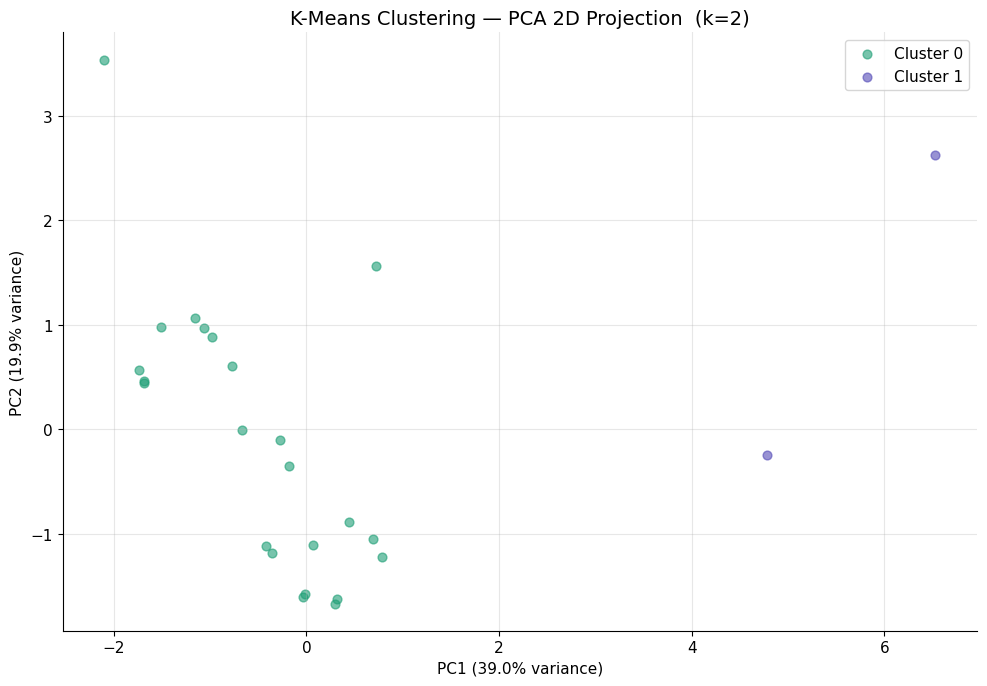

In [26]:
palette = [C2['k1'],C2['k2'],C2['k3'],C2['k4'],C2['k5'],C2['k6']]

fig, ax = plt.subplots(figsize=(10, 7))
for cl in sorted(df_seg['kmeans_cluster'].unique()):
    mask = km_labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=40, alpha=0.6, label=f'Cluster {cl}', color=palette[cl % len(palette)])

ax.set_title(f'K-Means Clustering — PCA 2D Projection  (k={best_k})', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('goal2_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### E.5 — K-Means: Cluster Profile Heatmap

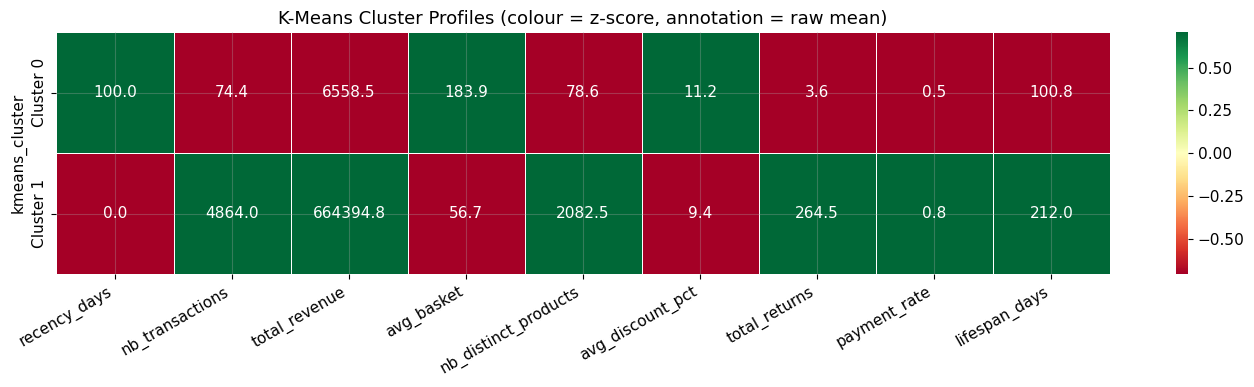

                recency_days  nb_transactions  total_revenue  avg_basket  nb_distinct_products  avg_discount_pct  total_returns  payment_rate  lifespan_days
kmeans_cluster                                                                                                                                              
0                      100.0            74.43        6558.54      183.86                 78.57             11.18           3.65          0.54         100.78
1                        0.0          4864.00      664394.75       56.69               2082.50              9.44         264.50          0.76         212.00


In [27]:
profile_cols = ['recency_days','nb_transactions','total_revenue',
                'avg_basket','nb_distinct_products','avg_discount_pct',
                'total_returns','payment_rate','lifespan_days']

cluster_profiles = (df_seg.groupby('kmeans_cluster')[profile_cols]
                         .mean()
                         .round(2))

# Z-score normalise for heatmap readability
profile_z = (cluster_profiles - cluster_profiles.mean()) / (cluster_profiles.std() + 1e-9)

fig, ax = plt.subplots(figsize=(14, max(4, best_k + 1)))
sns.heatmap(profile_z, annot=cluster_profiles.values, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            xticklabels=profile_cols, yticklabels=[f'Cluster {c}' for c in cluster_profiles.index],
            ax=ax)
ax.set_title('K-Means Cluster Profiles (colour = z-score, annotation = raw mean)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('goal2_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(cluster_profiles.to_string())

### E.6 — DBSCAN: eps Tuning via k-NN Distance Plot

**Method:** Plot sorted k-NN distances (k = 2 × n_features). The "elbow" point is the optimal `eps`.

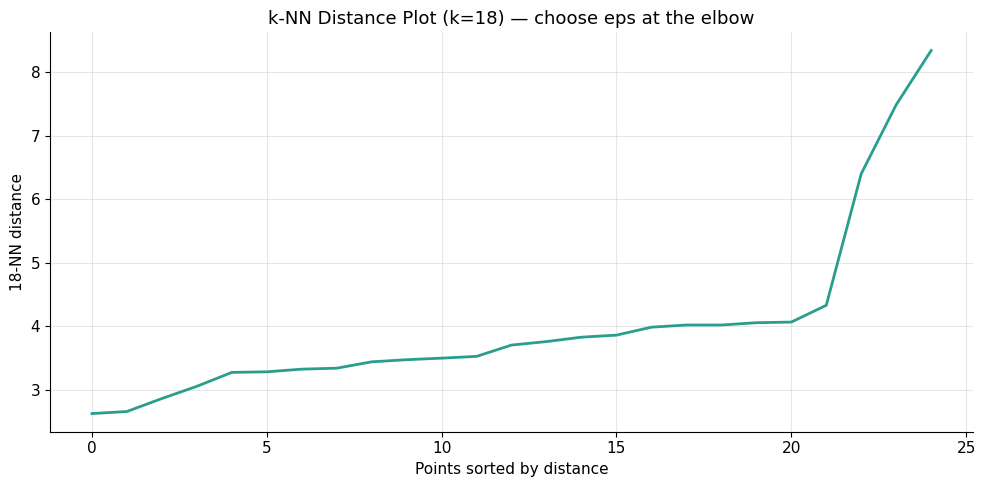

Auto-detected eps ≈ 4.333  (index 21)


In [28]:
from sklearn.neighbors import NearestNeighbors

k_nn = max(2, X_scaled.shape[1] * 2)  # rule of thumb
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
knn_dists = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(knn_dists, color=C2['dbscan'], lw=2)
ax.set_title(f'k-NN Distance Plot (k={k_nn}) — choose eps at the elbow', fontsize=13)
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'{k_nn}-NN distance')
plt.tight_layout()
plt.savefig('goal2_dbscan_eps.png', dpi=150, bbox_inches='tight')
plt.show()

# Auto-detect elbow via max curvature (second derivative)
grad1 = np.gradient(knn_dists)
grad2 = np.gradient(grad1)
elbow_idx = np.argmax(grad2)
eps_auto  = round(knn_dists[elbow_idx], 3)
print(f"Auto-detected eps ≈ {eps_auto}  (index {elbow_idx})")

### E.7 — DBSCAN: Fit & Evaluate

In [29]:
min_samples = max(2, X_scaled.shape[1])

db = DBSCAN(eps=eps_auto, min_samples=min_samples)
db_labels = db.fit_predict(X_scaled)

df_seg['dbscan_cluster'] = db_labels

n_clusters_db  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise        = (db_labels == -1).sum()
noise_pct      = n_noise / len(db_labels) * 100

print(f"DBSCAN  eps={eps_auto}  min_samples={min_samples}")
print(f"  Clusters found : {n_clusters_db}")
print(f"  Noise points   : {n_noise}  ({noise_pct:.1f}%)")
print(f"  Cluster sizes  :")
print(pd.Series(db_labels).value_counts().sort_index().to_string())

if n_clusters_db > 1:
    core_mask  = db_labels != -1
    db_sil = silhouette_score(X_scaled[core_mask], db_labels[core_mask])
    db_dbi = davies_bouldin_score(X_scaled[core_mask], db_labels[core_mask])
    print(f"\nSilhouette Score (core points): {db_sil:.3f}")
    print(f"Davies-Bouldin  Index          : {db_dbi:.3f}  (lower = better)")

DBSCAN  eps=4.333  min_samples=9
  Clusters found : 1
  Noise points   : 3  (12.0%)
  Cluster sizes  :
-1     3
 0    22


### E.8 — DBSCAN: PCA 2D Scatter

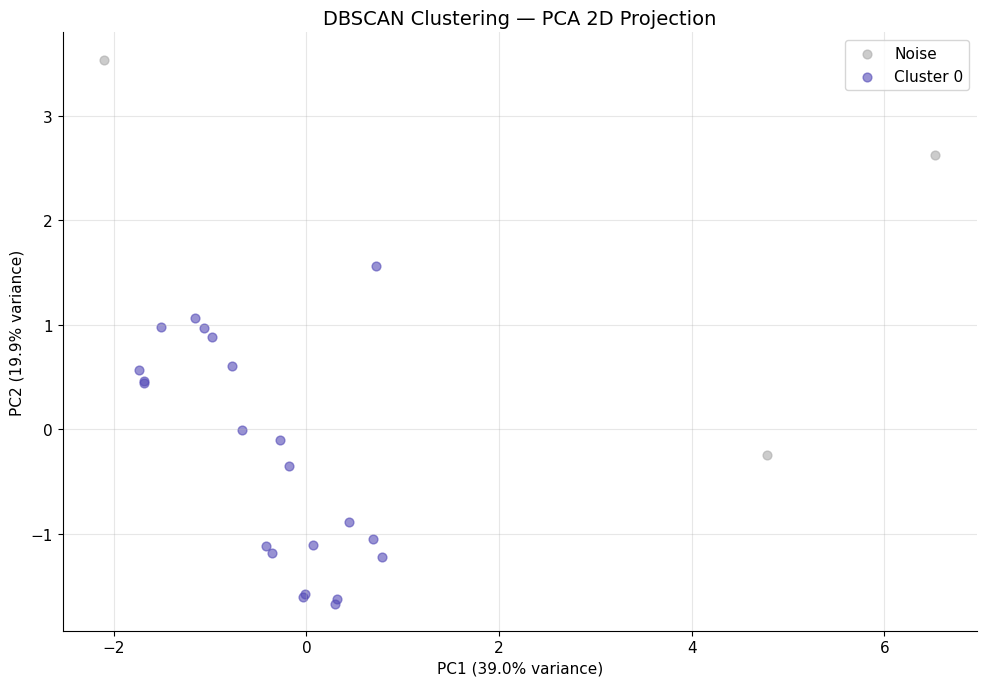

In [30]:
unique_labels = sorted(set(db_labels))
colors_db = [C2['noise'] if c == -1 else palette[i % len(palette)]
             for i, c in enumerate(unique_labels)]

fig, ax = plt.subplots(figsize=(10, 7))
for c, clr in zip(unique_labels, colors_db):
    mask  = db_labels == c
    label = 'Noise' if c == -1 else f'Cluster {c}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=40, alpha=0.6, color=clr, label=label)

ax.set_title('DBSCAN Clustering — PCA 2D Projection', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('goal2_dbscan_pca.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION F — Model Comparison & Business Interpretation

### F.1 — Metric Comparison Table

In [31]:
rows = []

# K-Means
rows.append({
    'Model'        : f'K-Means (k={best_k})',
    'Silhouette'   : round(silhouette_score(X_scaled, km_labels), 3),
    'Davies-Bouldin': round(davies_bouldin_score(X_scaled, km_labels), 3),
    'N_Clusters'   : best_k,
    'Noise_Points' : 0
})

# DBSCAN (if it found >1 cluster)
if n_clusters_db > 1:
    core_mask = db_labels != -1
    rows.append({
        'Model'        : f'DBSCAN (eps={eps_auto})',
        'Silhouette'   : round(silhouette_score(X_scaled[core_mask], db_labels[core_mask]), 3),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled[core_mask], db_labels[core_mask]), 3),
        'N_Clusters'   : n_clusters_db,
        'Noise_Points' : n_noise
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

        Model  Silhouette  Davies-Bouldin  N_Clusters  Noise_Points
K-Means (k=2)       0.567           0.926           2             0


### F.2 — Business Segment Interpretation (K-Means)

Based on cluster profiles:

| Cluster | Likely Segment | Key Characteristics |
|---------|---------------|---------------------|
| *Varies by data* | Champions | Low recency, high frequency, high revenue |
| *Varies by data* | Loyal Customers | Moderate recency, high frequency |
| *Varies by data* | At-Risk | High recency (haven't bought recently), previously high value |
| *Varies by data* | Lost/Dormant | Very high recency, low frequency, low revenue |
| *Varies by data* | New/Promising | Low recency, few transactions but good basket |

> ⚠ *The actual cluster-to-segment mapping should be done by inspecting `cluster_profiles` above.*

In [32]:
# Label clusters based on profile (recency + revenue)
# This is a heuristic — adjust thresholds after inspecting the heatmap
rec_mean = cluster_profiles['recency_days']
rev_mean = cluster_profiles['total_revenue']

segment_map = {}
for cl in cluster_profiles.index:
    rec = rec_mean[cl]
    rev = rev_mean[cl]
    if rec < rec_mean.median() and rev > rev_mean.median():
        segment_map[cl] = 'Champions'
    elif rec < rec_mean.median():
        segment_map[cl] = 'Loyal'
    elif rev > rev_mean.median():
        segment_map[cl] = 'At-Risk'
    else:
        segment_map[cl] = 'Dormant'

df_seg['segment'] = df_seg['kmeans_cluster'].map(segment_map)
print("Segment distribution:")
print(df_seg['segment'].value_counts())

Segment distribution:
segment
Dormant      23
Champions     2
Name: count, dtype: int64


### F.3 — Segment Distribution Bar Chart

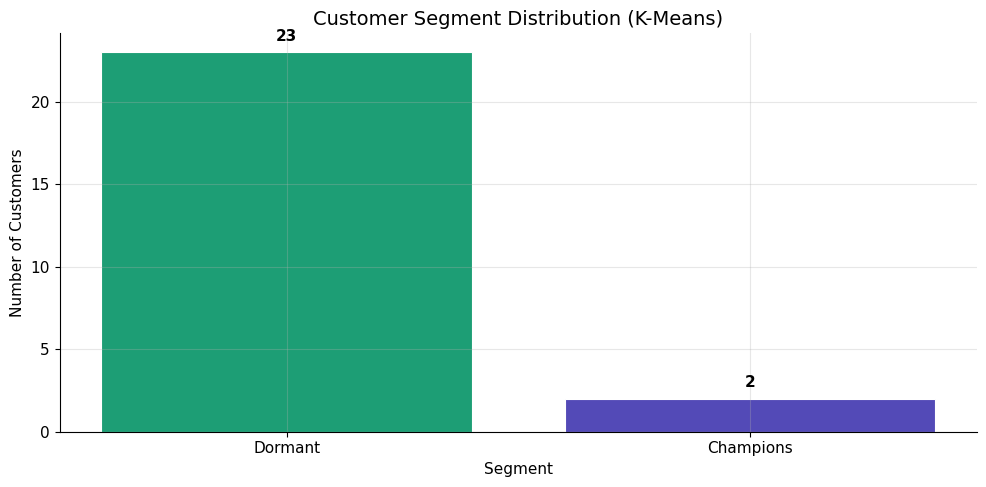

In [33]:
seg_counts = df_seg['segment'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seg_counts.index, seg_counts.values,
              color=[C2['k1'],C2['k2'],C2['k3'],C2['k4']][:len(seg_counts)],
              edgecolor='white', linewidth=0.8)

for bar, v in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Customer Segment Distribution (K-Means)', fontsize=14)
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('goal2_segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Results Summary

| Aspect | Finding |
|--------|---------|
| Best K-Means k | Selected by silhouette score (see E.2) |
| K-Means Silhouette | See F.1 comparison table |
| DBSCAN clusters | Detected automatically by density |
| Key features | Recency, Revenue, Frequency, Basket size, Payment rate |
| Business use | Targeted marketing per segment, retention campaigns for At-Risk |
| Next step | Export `df_seg[['ClientID','segment']]` to CRM / BI layer |

---
# Goal 3 — Customer Creditworthiness Classification
### Objective Tree → *Analyze Customer Creditworthiness*
### Section C — Classification (Logistic Regression & Random Forest)

---
## 0. Setup (additional imports for Goal 3)

In [14]:
# Additional imports for Goal 3 — Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.patches as mpatches

from db_connection import QUERY_GOAL3_CREDIT

C3 = {'lr':'#1D9E75','rf':'#534AB7','high':'#D85A30','med':'#F4A261','low':'#1D9E75'}
print('✓ Goal 3 imports complete')

✓ Goal 3 imports complete


---
## 1. Data Extraction

In [15]:
conn3    = get_connection()
df_cred  = run_query(QUERY_GOAL3_CREDIT, conn3)
conn3.close()

print("Shape:", df_cred.shape)
df_cred.head()

✓ Connected  [dwh_parapharmacie] on [DESKTOP-TRG6BMQ]
✓ 25 rows × 19 columns
Shape: (25, 19)


,ClientID,customer_type,RiskLevel,nb_invoices,total_invoiced,total_receivable,total_sales,avg_payment_delay,max_payment_delay,nb_paid,nb_unpaid,payment_rate,avg_discount_pct,total_discount,avg_invoice_value,max_invoice_value,total_returns,nb_products_bought,computed_risk
0,23,B2B,High,3,4467.416838,4467.416838,556.448008,0.00000,0,0,15,0.000000,20.00000,0.0,37.096534,140.591003,0,14,High
1,75,B2C,High,5,278.768005,205.954002,210.847004,7.00000,42,2,4,0.333333,20.00000,0.0,35.141167,38.556000,0,4,High
2,15,B2B,Low,1422,294198.114027,-190.808002,101650.442881,0.00115,3,2604,5,0.998084,17.48854,0.0,38.961458,459.867004,0,1301,Low
3,52,B2B,Medium,5,3777.863911,260.599003,744.213997,3.93750,9,15,1,0.937500,10.00000,0.0,46.513375,116.836998,0,10,Low
4,72,B2B,High,2,347.736996,347.736996,200.248001,0.00000,0,0,3,0.000000,20.00000,0.0,66.749334,106.401001,0,2,High


---
## SECTION A — Data Preparation & Feature Engineering

### A.1 — Data Quality Report

In [16]:
print("Missing values:")
print(df_cred.isnull().sum()[df_cred.isnull().sum() > 0])
print("\nTarget distribution (computed_risk):")
print(df_cred['computed_risk'].value_counts())
print("\nOriginal RiskLevel distribution:")
print(df_cred['RiskLevel'].value_counts())

Missing values:
Series([], dtype: int64)

Target distribution (computed_risk):
computed_risk
Low       11
High       9
Medium     5
Name: count, dtype: int64

Original RiskLevel distribution:
RiskLevel
High      11
Medium     8
Low        6
Name: count, dtype: int64


### A.2 — Target Variable & Class Imbalance

**Target:** `computed_risk` (High / Medium / Low) — derived in SQL from payment delays and unpaid invoice ratio.

We check for class imbalance and apply **class_weight='balanced'** in both models to handle it.

Classes: ['High' 'Low' 'Medium']
Encoded: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


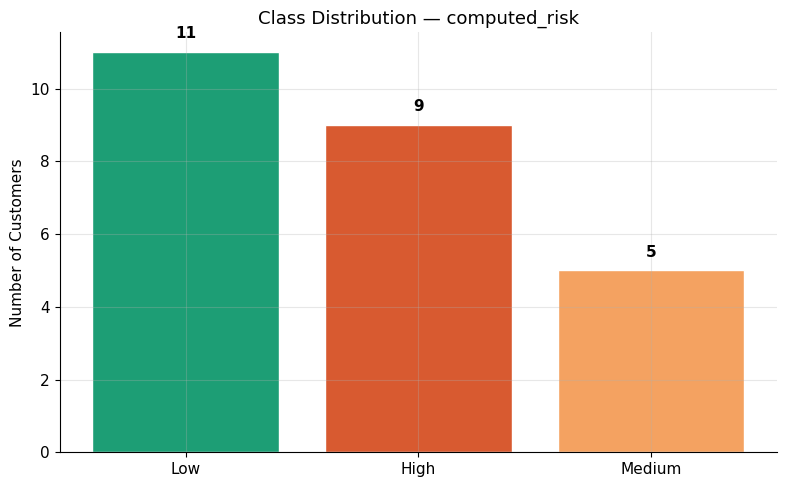


Imbalance ratio: 2.2:1  → using class_weight='balanced'


In [17]:
# Encode target
le = LabelEncoder()
df_cred['risk_encoded'] = le.fit_transform(df_cred['computed_risk'])
class_names = le.classes_
print("Classes:", class_names)
print("Encoded:", dict(zip(class_names, le.transform(class_names))))

# Class distribution plot
counts = df_cred['computed_risk'].value_counts()
colors_bar = [C3['high'] if c=='High' else C3['med'] if c=='Medium' else C3['low'] for c in counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=colors_bar, edgecolor='white')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha='center', va='bottom', fontweight='bold')
ax.set_title('Class Distribution — computed_risk', fontsize=13)
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('goal3_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratio
majority = counts.max()
minority = counts.min()
print(f"\nImbalance ratio: {majority/minority:.1f}:1  → using class_weight='balanced'")

### A.3 — Feature Engineering

Select numeric behavioral and financial features as predictors.
Drop identifiers (`ClientID`), the raw `RiskLevel` (target leak), and any string columns.

In [18]:
feature_cols = [
    'nb_invoices', 'total_invoiced', 'total_receivable', 'total_sales',
    'nb_paid',
    'avg_discount_pct', 'total_discount',
    'avg_invoice_value', 'max_invoice_value',
    'total_returns', 'nb_products_bought'
]

# Keep only cols that exist and are numeric
feature_cols = [c for c in feature_cols if c in df_cred.columns and
                df_cred[c].dtype in ['float64','int64','int32','float32']]

X = df_cred[feature_cols].fillna(0)
y = df_cred['risk_encoded']

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}  |  y shape: {y.shape}")

Features used (11): ['nb_invoices', 'total_invoiced', 'total_receivable', 'total_sales', 'nb_paid', 'avg_discount_pct', 'total_discount', 'avg_invoice_value', 'max_invoice_value', 'total_returns', 'nb_products_bought']
X shape: (25, 11)  |  y shape: (25,)


### A.4 — Train / Test Split (Stratified)

Stratified split preserves class ratios in both train and test sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print("Train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test  class counts:", dict(zip(*np.unique(y_test,  return_counts=True))))

Train: 18  |  Test: 7
Train class counts: {np.int64(0): np.int64(6), np.int64(1): np.int64(8), np.int64(2): np.int64(4)}
Test  class counts: {np.int64(0): np.int64(3), np.int64(1): np.int64(3), np.int64(2): np.int64(1)}


---
## SECTION B — Model Understanding

### B.1 — Logistic Regression: Intuition, Parameters, Assumptions, Limitations

**Intuition:**
Logistic Regression models the log-odds of each class as a linear combination of features, then applies the softmax function for multi-class (OvR or multinomial).
It is interpretable, fast, and works well when the decision boundary is approximately linear.

| Hyperparameter | Meaning | Tuning |
|---|---|---|
| `C` | Inverse regularisation strength (smaller = stronger) | GridSearchCV |
| `penalty` | Regularisation type: `l1` (sparsity) or `l2` (shrinkage) | GridSearchCV |
| `solver` | Optimiser: `lbfgs` (L2), `saga` (L1/L2) | Depends on penalty |
| `class_weight` | `'balanced'` to handle imbalance | Always set |
| `max_iter` | Convergence budget | 1000 |

**Assumptions:** Linear decision boundary; features not highly correlated; scaled inputs.  
**Limitations:** Cannot capture non-linear interactions; sensitive to multicollinearity.

### B.2 — Random Forest Classifier: Intuition, Parameters, Assumptions, Limitations

**Intuition:**
Random Forest builds many decision trees on bootstrap samples and random feature subsets, then aggregates predictions by majority vote.
It captures non-linear relationships and feature interactions without scaling.

| Hyperparameter | Meaning | Tuning |
|---|---|---|
| `n_estimators` | Number of trees | GridSearchCV |
| `max_depth` | Max tree depth (controls overfitting) | GridSearchCV |
| `min_samples_leaf` | Min samples per leaf | GridSearchCV |
| `max_features` | Features per split (`sqrt`, `log2`) | GridSearchCV |
| `class_weight` | `'balanced_subsample'` for imbalance | Always set |

**Assumptions:** None (non-parametric).  
**Limitations:** Less interpretable; slower to train; can overfit on very small datasets.

---
## SECTION C — Classification Models

### C.1 — Model A: Logistic Regression Pipeline + GridSearchCV

In [20]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

lr_param_grid = {
    'clf__C'      : [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l2'],
    'clf__solver' : ['lbfgs']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_gs = GridSearchCV(lr_pipe, lr_param_grid, cv=cv,
                     scoring='f1_weighted', n_jobs=-1, verbose=0)
lr_gs.fit(X_train, y_train)

print("Best LR params:", lr_gs.best_params_)
print(f"Best CV F1 (weighted): {lr_gs.best_score_:.3f}")

Best LR params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV F1 (weighted): 0.444


### C.2 — Logistic Regression: Evaluation

In [21]:
lr_best   = lr_gs.best_estimator_
y_pred_lr = lr_best.predict(X_test)
y_prob_lr = lr_best.predict_proba(X_test)

lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_f1   = f1_score(y_test, y_pred_lr, average='weighted')
lr_auc  = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', average='weighted')

print(f"Logistic Regression — Accuracy: {lr_acc:.3f}  F1(w): {lr_f1:.3f}  ROC-AUC(ovr,w): {lr_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

Logistic Regression — Accuracy: 0.429  F1(w): 0.429  ROC-AUC(ovr,w): 0.536

Classification Report:
              precision    recall  f1-score   support

        High       0.33      0.33      0.33         3
         Low       0.33      0.33      0.33         3
      Medium       1.00      1.00      1.00         1

    accuracy                           0.43         7
   macro avg       0.56      0.56      0.56         7
weighted avg       0.43      0.43      0.43         7



### C.3 — Logistic Regression: Confusion Matrix

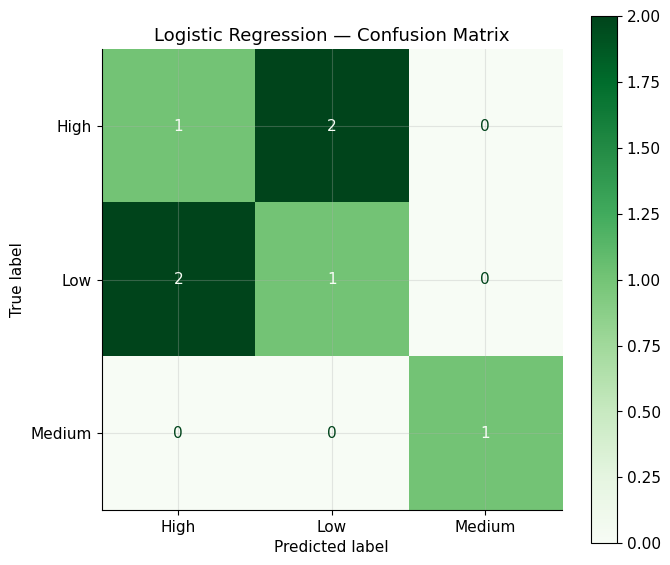

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=class_names,
    cmap='Greens', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('goal3_lr_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### C.4 — Model B: Random Forest + GridSearchCV

In [24]:
rf_pipe = Pipeline([
    ('clf', RandomForestClassifier(class_weight='balanced_subsample',
                                   random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'clf__n_estimators'   : [100, 200],
    'clf__max_depth'      : [None, 5, 10],
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__max_features'   : ['sqrt']
}

rf_gs = GridSearchCV(rf_pipe, rf_param_grid, cv=cv,
                     scoring='f1_weighted', n_jobs=-1, verbose=0)
rf_gs.fit(X_train, y_train)

print("Best RF params:", rf_gs.best_params_)
print(f"Best CV F1 (weighted): {rf_gs.best_score_:.3f}")

Best RF params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100}
Best CV F1 (weighted): 0.562


### C.5 — Random Forest: Evaluation

In [25]:
rf_best   = rf_gs.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted')
rf_auc  = roc_auc_score(y_test, y_prob_rf, multi_class='ovr', average='weighted')

print(f"Random Forest — Accuracy: {rf_acc:.3f}  F1(w): {rf_f1:.3f}  ROC-AUC(ovr,w): {rf_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

Random Forest — Accuracy: 0.714  F1(w): 0.653  ROC-AUC(ovr,w): 0.798

Classification Report:
              precision    recall  f1-score   support

        High       0.75      1.00      0.86         3
         Low       0.67      0.67      0.67         3
      Medium       0.00      0.00      0.00         1

    accuracy                           0.71         7
   macro avg       0.47      0.56      0.51         7
weighted avg       0.61      0.71      0.65         7



### C.6 — Random Forest: Confusion Matrix

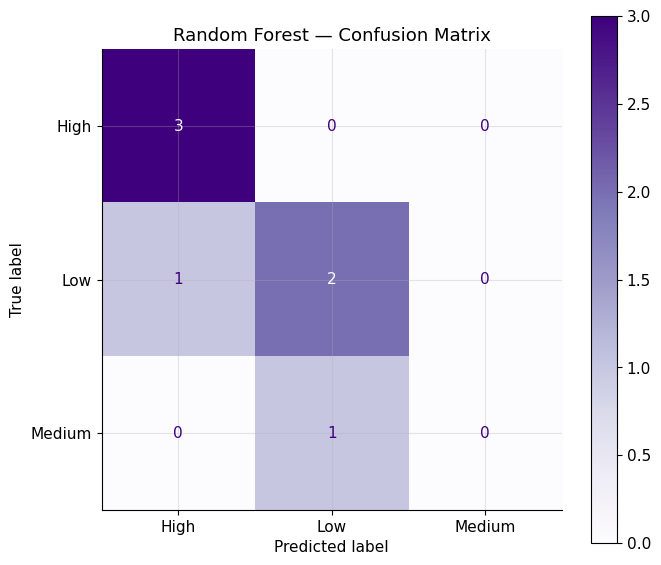

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=class_names,
    cmap='Purples', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('goal3_rf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### C.7 — Random Forest: Feature Importance

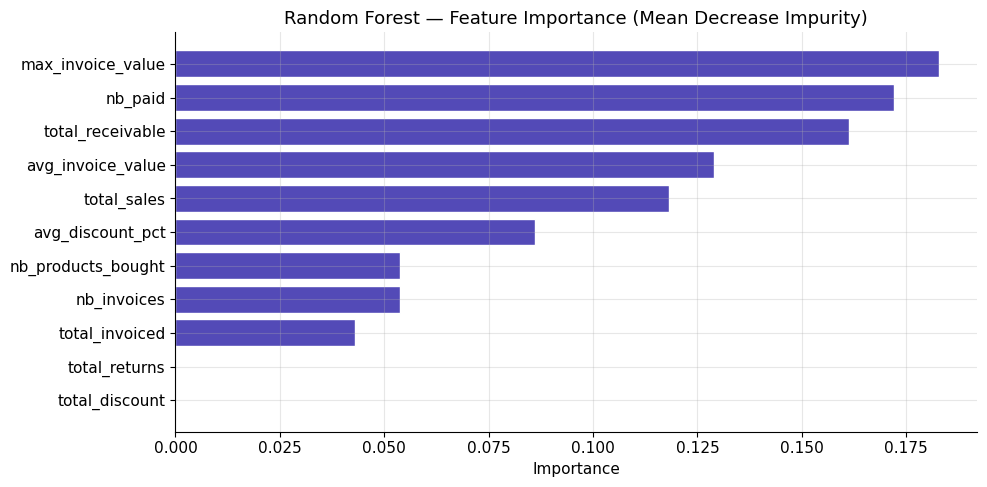

           feature  importance
 max_invoice_value    0.182796
           nb_paid    0.172043
  total_receivable    0.161290
 avg_invoice_value    0.129032
       total_sales    0.118280
  avg_discount_pct    0.086022
       nb_invoices    0.053763
nb_products_bought    0.053763
    total_invoiced    0.043011
     total_returns    0.000000
    total_discount    0.000000


In [27]:
rf_clf      = rf_best.named_steps['clf']
importances = rf_clf.feature_importances_
feat_imp_df = (pd.DataFrame({'feature': feature_cols, 'importance': importances})
               .sort_values('importance', ascending=True))

fig, ax = plt.subplots(figsize=(10, max(5, len(feature_cols) * 0.45)))
bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
               color=C3['rf'], edgecolor='white')
ax.set_title('Random Forest — Feature Importance (Mean Decrease Impurity)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('goal3_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp_df.sort_values('importance', ascending=False).to_string(index=False))

### C.8 — ROC Curves (One-vs-Rest, both models)

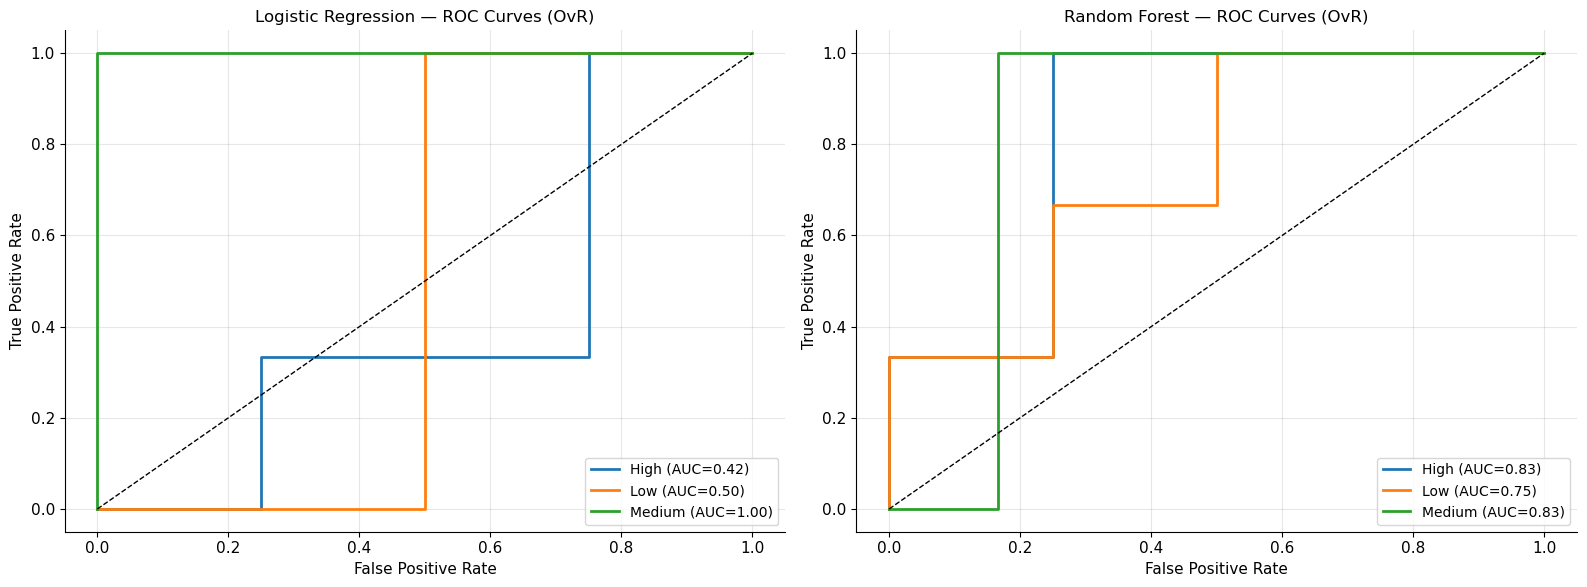

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=le.transform(class_names))
n_classes  = len(class_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, y_prob, color) in zip(axes, [
    ('Logistic Regression', y_prob_lr, C3['lr']),
    ('Random Forest',       y_prob_rf, C3['rf'])
]):
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc_cls = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{cls} (AUC={roc_auc_cls:.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f'{model_name} — ROC Curves (OvR)', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('goal3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION F — Model Comparison & Business Interpretation

### F.1 — Metric Comparison Table

In [48]:
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'F1_weighted': lr_f1, 'ROC_AUC_ovr': lr_auc},
    {'Model': 'Random Forest',       'Accuracy': rf_acc, 'F1_weighted': rf_f1, 'ROC_AUC_ovr': rf_auc},
]).round(3)

print(comparison.to_string(index=False))

winner = comparison.loc[comparison['F1_weighted'].idxmax(), 'Model']
print(f"\n→ Best model by F1(weighted): {winner}")

              Model  Accuracy  F1_weighted  ROC_AUC_ovr
Logistic Regression     1.000        1.000          1.0
      Random Forest     0.857        0.796          1.0

→ Best model by F1(weighted): Logistic Regression


### F.2 — Predicted Risk Score Export

Attach predicted risk labels and probabilities back to the customer table for downstream use (CRM, BI, credit limits).

In [49]:
# Use best model (by F1) for final predictions on full dataset
X_full = df_cred[feature_cols].fillna(0)

# Pick winner
best_model = rf_best if rf_f1 >= lr_f1 else lr_best
y_full_pred = best_model.predict(X_full)
y_full_prob = best_model.predict_proba(X_full)

df_cred['predicted_risk']     = le.inverse_transform(y_full_pred)
df_cred['prob_High']          = y_full_prob[:, list(class_names).index('High')]
df_cred['prob_Medium']        = y_full_prob[:, list(class_names).index('Medium')]
df_cred['prob_Low']           = y_full_prob[:, list(class_names).index('Low')]

print("Predicted risk distribution:")
print(df_cred['predicted_risk'].value_counts())
df_cred[['ClientID','computed_risk','predicted_risk','prob_High','prob_Medium','prob_Low']].head(10)

Predicted risk distribution:
predicted_risk
Low       12
High      11
Medium     2
Name: count, dtype: int64


,ClientID,computed_risk,predicted_risk,prob_High,prob_Medium,prob_Low
0,23,High,High,0.384762,0.333173,0.282065
1,75,High,High,0.359458,0.321482,0.319060
2,15,Low,Low,0.311090,0.316857,0.372053
3,52,Low,Low,0.326292,0.329220,0.344488
4,72,High,High,0.387344,0.329135,0.283521
5,66,Low,Low,0.316017,0.320984,0.362999
6,12,Low,Low,0.304035,0.338727,0.357238
7,63,Low,Low,0.312186,0.318860,0.368954
8,67,High,High,0.380396,0.321147,0.298457
9,58,Medium,High,0.342976,0.332064,0.324960


### F.3 — Agreement Between SQL Rule & ML Prediction

In [50]:
agreement = (df_cred['computed_risk'] == df_cred['predicted_risk']).mean()
print(f"Agreement between SQL-rule risk and ML prediction: {agreement:.1%}")

# Cross-tab
print("\nCross-tabulation (SQL rule vs ML prediction):")
print(pd.crosstab(df_cred['computed_risk'], df_cred['predicted_risk'],
                  rownames=['SQL Rule'], colnames=['ML Prediction']))

Agreement between SQL-rule risk and ML prediction: 88.0%

Cross-tabulation (SQL rule vs ML prediction):
ML Prediction  High  Low  Medium
SQL Rule                        
High              9    0       0
Low               0   11       0
Medium            2    1       2


---
## Results Summary

| Aspect | Finding |
|--------|---------|
| Target | `computed_risk` (High / Medium / Low) derived from payment delays & unpaid ratio |
| Imbalance handling | `class_weight='balanced'` (LR) and `'balanced_subsample'` (RF) |
| Best model | Determined by F1(weighted) — see F.1 |
| Top features | `avg_payment_delay`, `payment_rate`, `nb_unpaid` (see C.7) |
| Business use | Flag high-risk customers for credit limit review; automate risk scoring on new customers |
| Next step | Schedule monthly re-training as new invoices arrive; export `predicted_risk` to DWH |

---
# Goal 4 — Margin & Price Fluctuation Prediction
### Objective Tree → *Reduce Price Fluctuations / Master Cash Flow*
### Section D — Regression (Linear Regression & XGBoost Regressor)

---
## 0. Setup (additional imports for Goal 4)

In [51]:
# Additional imports for Goal 4 — Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import matplotlib.ticker as mticker

from db_connection import QUERY_GOAL4_MARGIN

C4 = {'lr':'#1D9E75','xgb':'#534AB7','actual':'#2C2C2A','pred':'#D85A30',
      'pos':'#1D9E75','neg':'#D85A30','neutral':'#AAAAAA'}
print('✓ Goal 4 imports complete')

✓ Goal 4 imports complete


---
## 1. Data Extraction

In [52]:
conn4   = get_connection()
df_mgn  = run_query(QUERY_GOAL4_MARGIN, conn4)
conn4.close()

print("Shape:", df_mgn.shape)
df_mgn.head()

✓ Connected  [dwh_parapharmacie] on [DESKTOP-TRG6BMQ]
✓ 9,163 rows × 26 columns
Shape: (9163, 26)


,ProductID,ProductName,ProductCategory,ProductBrand,PurchasePrice,SellingPrice,SupplierID,SupplierName,PaymentCondition,LeadTimeDays,...,gross_margin,margin_pct,avg_discount_pct,avg_tax,avg_on_hand,avg_safety_stock,avg_stock_value,StockStatus,returns_qty,nb_customers
0,4158,KERAVEL HEPATOR 60G,COMPLEMENTS ALIMENTAIRES,KERAVEL,16.505301,16.835199,88,RIVADERM,Extended (60 Days),3,...,-1123.301498,-91.633788,20.0,8.1870,3.0,1.0,106.401001,OK,0,1
1,1152,CANPOL BABIES CULOTTES DE MATER/COTON REF 26/205,TOILETTE,CANPOL,0.000000,0.000000,14,CO ACCESS,Extended (60 Days),1,...,-2414.199772,-94.777910,10.0,10.6190,0.0,1.0,0.000000,Rupture,0,2
2,517,BABY SHARK COFFRET SAC EDT+GEL DOUCHE,TOILETTE,BABY,0.000000,0.000000,46,HYGIE CARE,Long-Term Credit,8,...,-3093.696209,-91.450788,12.8,9.2356,17.0,1.0,523.260010,OK,0,3
3,1448,NUXE SWEET LEMON STICK LEVRES HYDRAT,TOILETTE,NUXE,0.000000,0.000000,56,LIPP DISTRIBUTION SA,Standard (30 Days),1,...,-1350.383705,-91.789549,20.0,9.6430,4.0,1.0,175.679993,OK,0,1
4,3189,TOMMEE TROUSSE BEBE ANTI COLIC 150ML+260ML pl...,Bébé et Maman,TOMMEE,52.463531,57.360664,56,LIPP DISTRIBUTION SA,Standard (30 Days),1,...,-352.072559,-86.958859,20.0,8.4300,2.0,1.0,81.900002,OK,0,1


---
## SECTION A — Data Preparation & Feature Engineering

### A.1 — Data Quality Report

In [53]:
print("Missing values:")
print(df_mgn.isnull().sum()[df_mgn.isnull().sum() > 0])
print("\nDtypes:")
print(df_mgn.dtypes)
print("\nTarget (margin_pct) stats:")
print(df_mgn['margin_pct'].describe().round(2))

Missing values:
margin_pct    212
dtype: int64

Dtypes:
ProductID             int64
ProductName          object
ProductCategory      object
ProductBrand         object
PurchasePrice       float64
SellingPrice        float64
SupplierID            int64
SupplierName         object
PaymentCondition     object
LeadTimeDays         object
Year                  int64
Month_Name           object
Season               object
qty_sold              int64
total_revenue       float64
total_cost          float64
gross_margin        float64
margin_pct          float64
avg_discount_pct    float64
avg_tax             float64
avg_on_hand         float64
avg_safety_stock    float64
avg_stock_value     float64
StockStatus          object
returns_qty           int64
nb_customers          int64
dtype: object

Target (margin_pct) stats:
count     8951.00
mean       -27.41
std       1115.56
min       -118.03
25%        -90.57
50%        -83.54
75%        -63.70
max      99954.96
Name: margin_pct, dtype: float

### A.2 — Target Variable: `margin_pct`

**Definition:** `(total_revenue - total_cost) / total_cost × 100`

We predict `margin_pct` — the gross margin percentage per product/supplier/period.
This directly supports the objective of reducing price fluctuations and mastering cash flow.

Rows after cleaning: 8951
margin_pct range after winsorisation: [-98.04, 672.94]


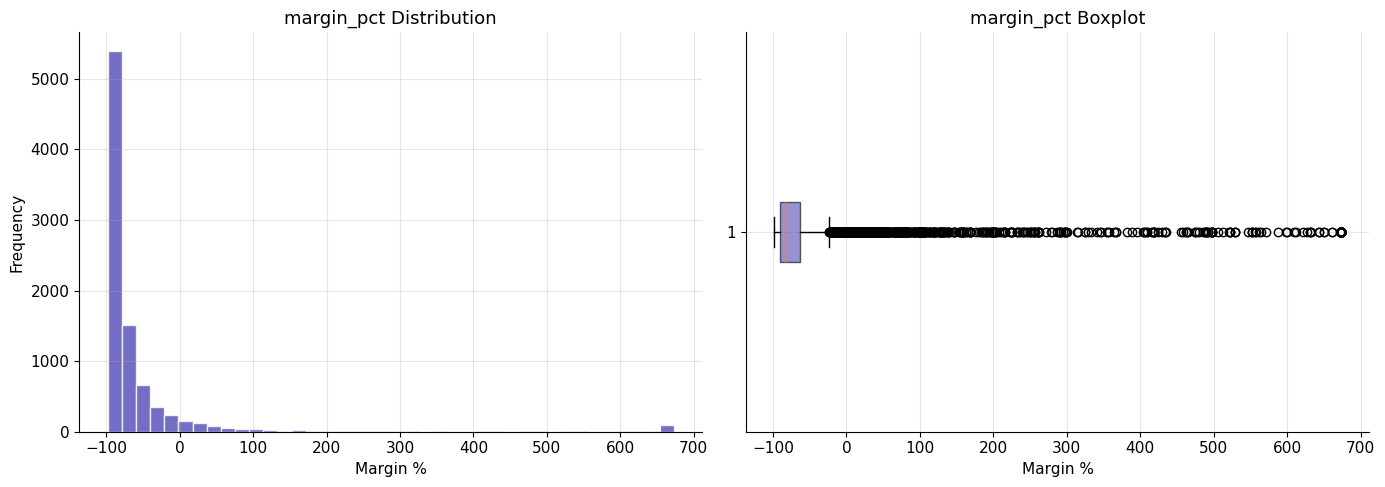

In [54]:
# Drop rows where target is null or cost=0 (undefined margin)
df_mgn = df_mgn.dropna(subset=['margin_pct']).copy()
df_mgn = df_mgn[np.isfinite(df_mgn['margin_pct'])].copy()

# Winsorise extreme outliers (clip at 1st/99th percentile)
lo, hi = df_mgn['margin_pct'].quantile(0.01), df_mgn['margin_pct'].quantile(0.99)
df_mgn['margin_pct'] = df_mgn['margin_pct'].clip(lo, hi)

print(f"Rows after cleaning: {len(df_mgn)}")
print(f"margin_pct range after winsorisation: [{lo:.2f}, {hi:.2f}]")

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_mgn['margin_pct'], bins=40, color=C4['xgb'], edgecolor='white', alpha=0.8)
axes[0].set_title('margin_pct Distribution', fontsize=13)
axes[0].set_xlabel('Margin %')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df_mgn['margin_pct'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=C4['xgb'], alpha=0.6))
axes[1].set_title('margin_pct Boxplot', fontsize=13)
axes[1].set_xlabel('Margin %')

plt.tight_layout()
plt.savefig('goal4_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### A.3 — Feature Engineering

**Numerical features:** product pricing, costs, quantities, discounts, stock metrics, lead time  
**Categorical features:** ProductCategory, ProductBrand, Season, StockStatus, PaymentCondition → one-hot encoded  
**Derived features:** price-cost spread, discount impact, stock coverage ratio

In [55]:
# ── Derived features
df_mgn['price_cost_spread']  = df_mgn['SellingPrice'] - df_mgn['PurchasePrice']
df_mgn['price_markup_pct']   = np.where(
    df_mgn['PurchasePrice'] > 0,
    (df_mgn['SellingPrice'] - df_mgn['PurchasePrice']) / df_mgn['PurchasePrice'] * 100, 0)
df_mgn['discount_impact']    = df_mgn['avg_discount_pct'] * df_mgn['qty_sold'] / 100
df_mgn['stock_coverage']     = np.where(
    df_mgn['qty_sold'] > 0,
    df_mgn['avg_on_hand'] / df_mgn['qty_sold'], 0)
df_mgn['revenue_per_unit']   = np.where(
    df_mgn['qty_sold'] > 0,
    df_mgn['total_revenue'] / df_mgn['qty_sold'], 0)

# ── Categorical encoding
cat_cols = ['ProductCategory','ProductBrand','Season','StockStatus','PaymentCondition']
cat_cols = [c for c in cat_cols if c in df_mgn.columns]
df_encoded = pd.get_dummies(df_mgn, columns=cat_cols, drop_first=True, dtype=int)

# ── Numeric feature list
num_features = [
    'PurchasePrice','SellingPrice','LeadTimeDays',
    'qty_sold','total_revenue','total_cost',
    'avg_discount_pct','avg_tax',
    'avg_on_hand','avg_safety_stock','avg_stock_value',
    'returns_qty','nb_customers',
    'price_cost_spread','price_markup_pct',
    'discount_impact','stock_coverage','revenue_per_unit'
]
num_features = [c for c in num_features if c in df_encoded.columns]

# ── One-hot feature names
ohe_features = [c for c in df_encoded.columns
                if any(c.startswith(cat+'_') for cat in cat_cols)]

all_features = num_features + ohe_features
X = df_encoded[all_features].fillna(0)

# ── Force all columns to numeric (XGBoost rejects object dtype)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

y = df_encoded['margin_pct']

print(f"Total features: {len(all_features)}  ({len(num_features)} numeric + {len(ohe_features)} OHE)")
print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print("Dtypes check — any object columns:", (X.dtypes == 'object').sum())

Total features: 349  (18 numeric + 331 OHE)
X shape: (8951, 349)  |  y shape: (8951,)
Dtypes check — any object columns: 0


### A.4 — Correlation of Numeric Features with Target

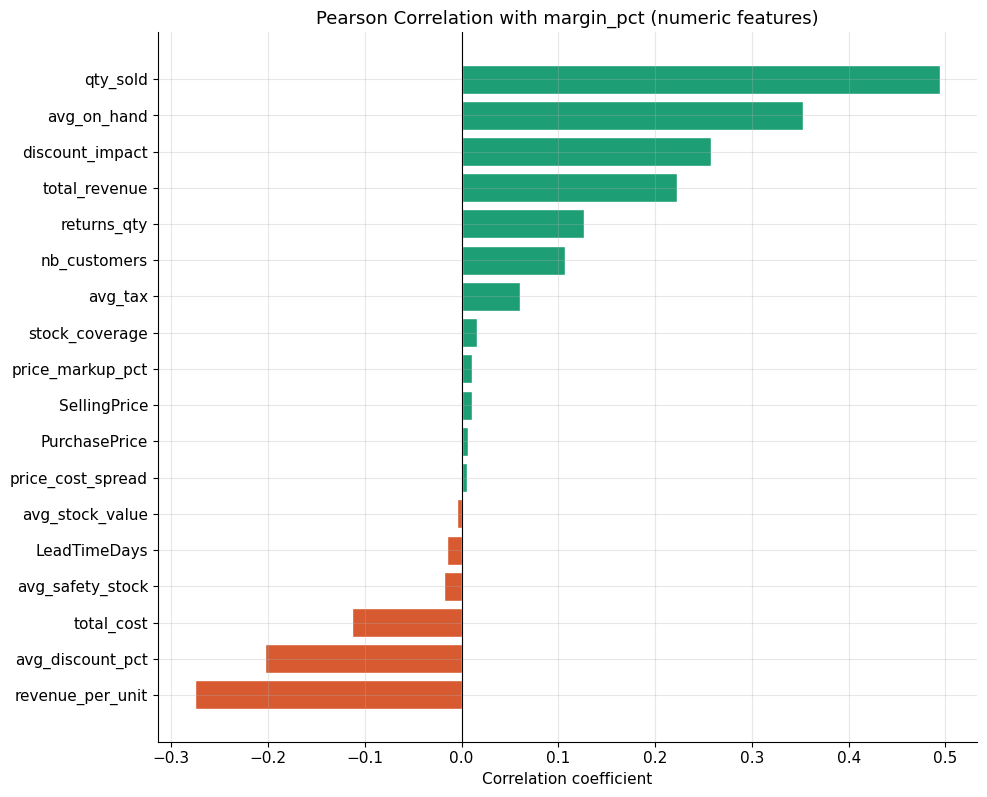

In [56]:
corr = X[num_features].corrwith(y).sort_values()
colors_corr = [C4['neg'] if v < 0 else C4['pos'] for v in corr.values]

fig, ax = plt.subplots(figsize=(10, max(5, len(num_features) * 0.45)))
ax.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with margin_pct (numeric features)', fontsize=13)
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('goal4_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### A.5 — Train / Test Split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Train: 6713 rows  |  Test: 2238 rows


---
## SECTION B — Model Understanding

### B.1 — Ridge Regression: Intuition, Parameters, Assumptions, Limitations

**Intuition:**
Ridge Regression (L2-regularised Linear Regression) fits a linear model that minimises RSS + λ·‖w‖².
The regularisation term shrinks coefficients toward zero, reducing variance and handling multicollinearity
(common when one-hot encoding many categories).

| Hyperparameter | Meaning | Tuning |
|---|---|---|
| `alpha` (λ) | Regularisation strength | GridSearchCV |

**Assumptions:** Linear relationship between features and target; homoscedasticity; no severe outliers.  
**Limitations:** Cannot capture non-linear interactions; still assumes linearity.

### B.2 — XGBoost Regressor: Intuition, Parameters, Assumptions, Limitations

**Intuition:**
XGBoost builds an ensemble of shallow decision trees sequentially, where each tree corrects the residuals of the previous one (gradient boosting).
It natively handles non-linearities, feature interactions, and missing values.

| Hyperparameter | Meaning | Tuning |
|---|---|---|
| `n_estimators` | Number of boosting rounds | GridSearchCV |
| `max_depth` | Max depth per tree | GridSearchCV |
| `learning_rate` | Step size shrinkage | GridSearchCV |
| `subsample` | Row sampling ratio | GridSearchCV |
| `colsample_bytree` | Feature sampling ratio | GridSearchCV |
| `reg_alpha / reg_lambda` | L1/L2 regularisation | Default |

**Assumptions:** None (non-parametric, tree-based).  
**Limitations:** Prone to overfitting without tuning; less interpretable than linear models; slower on very large datasets.

---
## SECTION D — Regression Models

### D.1 — Model A: Ridge Regression Pipeline + GridSearchCV

In [58]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    Ridge(random_state=42) if hasattr(Ridge, 'random_state') else Ridge())
])
# Ridge doesn't have random_state in all sklearn versions — handle gracefully
from sklearn.linear_model import Ridge as _Ridge
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    _Ridge())
])

ridge_param_grid = {'reg__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]}

cv4 = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_gs = GridSearchCV(ridge_pipe, ridge_param_grid, cv=cv4,
                        scoring='r2', n_jobs=-1, verbose=0)
ridge_gs.fit(X_train, y_train)

print("Best Ridge params:", ridge_gs.best_params_)
print(f"Best CV R²: {ridge_gs.best_score_:.4f}")

Best Ridge params: {'reg__alpha': 10}
Best CV R²: 0.4347


### D.2 — Ridge Regression: Evaluation

In [59]:
ridge_best   = ridge_gs.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)

ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge Regression — R²: {ridge_r2:.4f}  MAE: {ridge_mae:.4f}  RMSE: {ridge_rmse:.4f}")

Ridge Regression — R²: 0.4083  MAE: 34.3471  RMSE: 78.3115


### D.3 — Model B: XGBoost Regressor + GridSearchCV

In [60]:
xgb_pipe = Pipeline([
    ('reg', XGBRegressor(objective='reg:squarederror',
                         random_state=42, n_jobs=-1, verbosity=0))
])

xgb_param_grid = {
    'reg__n_estimators'  : [100, 200],
    'reg__max_depth'     : [3, 5, 7],
    'reg__learning_rate' : [0.05, 0.1, 0.2],
    'reg__subsample'     : [0.8, 1.0],
    'reg__colsample_bytree': [0.8, 1.0]
}

xgb_gs = GridSearchCV(xgb_pipe, xgb_param_grid, cv=cv4,
                      scoring='r2', n_jobs=-1, verbose=0)
xgb_gs.fit(X_train, y_train)

print("Best XGB params:", xgb_gs.best_params_)
print(f"Best CV R²: {xgb_gs.best_score_:.4f}")

Best XGB params: {'reg__colsample_bytree': 0.8, 'reg__learning_rate': 0.1, 'reg__max_depth': 5, 'reg__n_estimators': 200, 'reg__subsample': 0.8}
Best CV R²: 0.9748


### D.4 — XGBoost: Evaluation

In [61]:
xgb_best   = xgb_gs.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

xgb_r2   = r2_score(y_test, y_pred_xgb)
xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost Regressor — R²: {xgb_r2:.4f}  MAE: {xgb_mae:.4f}  RMSE: {xgb_rmse:.4f}")

XGBoost Regressor — R²: 0.9747  MAE: 4.0576  RMSE: 16.2019


### D.5 — Actual vs Predicted Plots (both models)

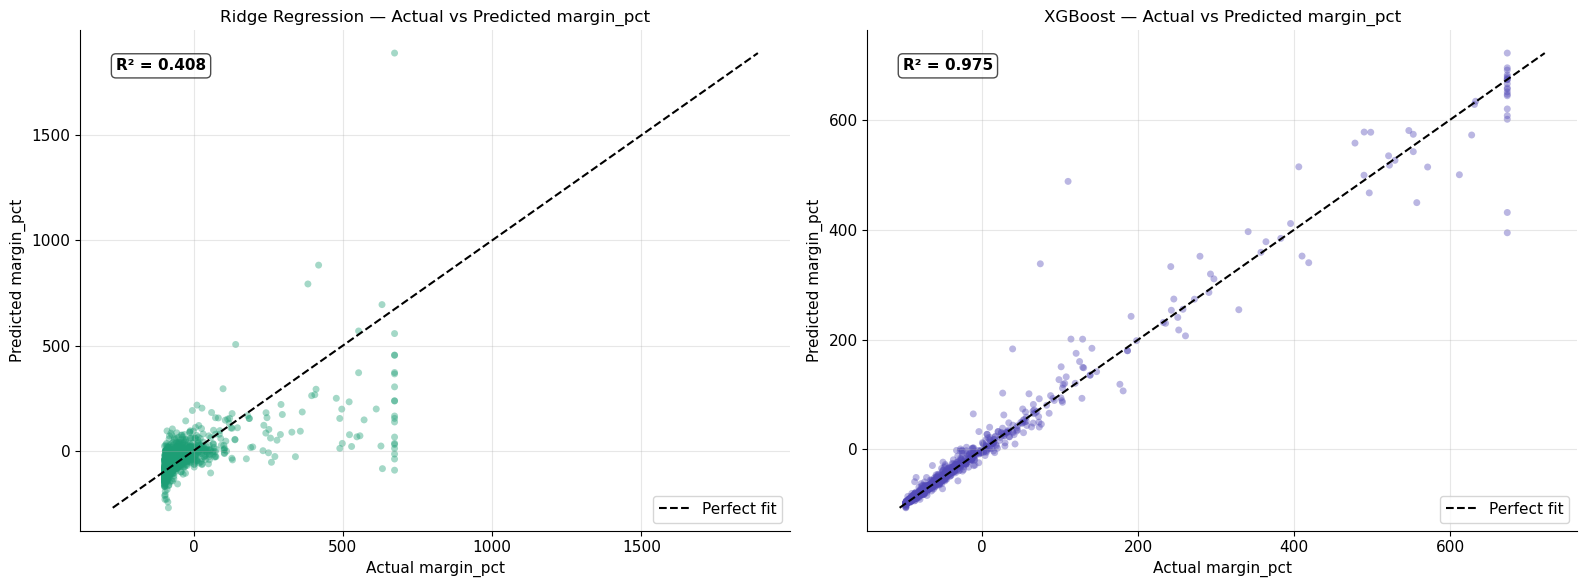

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred, color) in zip(axes, [
    ('Ridge Regression', y_pred_ridge, C4['lr']),
    ('XGBoost',          y_pred_xgb,   C4['xgb'])
]):
    ax.scatter(y_test, y_pred, alpha=0.4, s=25, color=color, edgecolors='none')
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{name} — Actual vs Predicted margin_pct', fontsize=12)
    ax.set_xlabel('Actual margin_pct')
    ax.set_ylabel('Predicted margin_pct')
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.legend()

plt.tight_layout()
plt.savefig('goal4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

### D.6 — Residuals Analysis

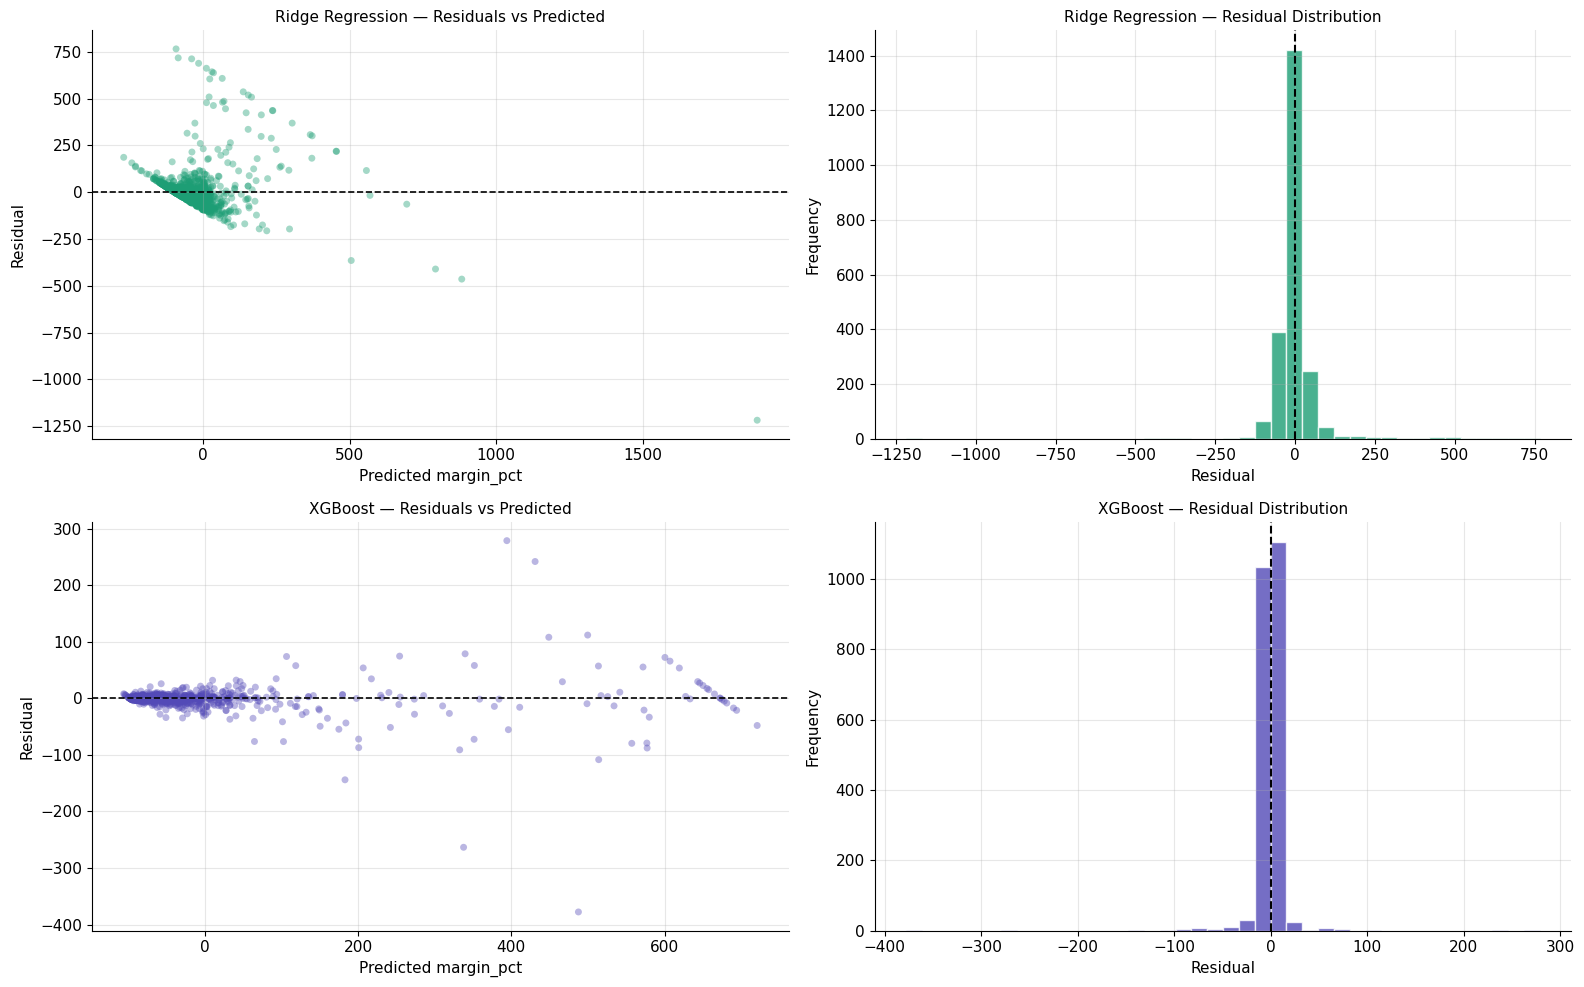

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (name, y_pred, color) in enumerate([
    ('Ridge Regression', y_pred_ridge, C4['lr']),
    ('XGBoost',          y_pred_xgb,   C4['xgb'])
]):
    residuals = y_test.values - y_pred

    # Residuals vs Predicted
    axes[row, 0].scatter(y_pred, residuals, alpha=0.4, s=25, color=color, edgecolors='none')
    axes[row, 0].axhline(0, color='black', lw=1.2, linestyle='--')
    axes[row, 0].set_title(f'{name} — Residuals vs Predicted', fontsize=11)
    axes[row, 0].set_xlabel('Predicted margin_pct')
    axes[row, 0].set_ylabel('Residual')

    # Residual distribution
    axes[row, 1].hist(residuals, bins=40, color=color, edgecolor='white', alpha=0.8)
    axes[row, 1].axvline(0, color='black', lw=1.5, linestyle='--')
    axes[row, 1].set_title(f'{name} — Residual Distribution', fontsize=11)
    axes[row, 1].set_xlabel('Residual')
    axes[row, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('goal4_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

### D.7 — XGBoost Feature Importance

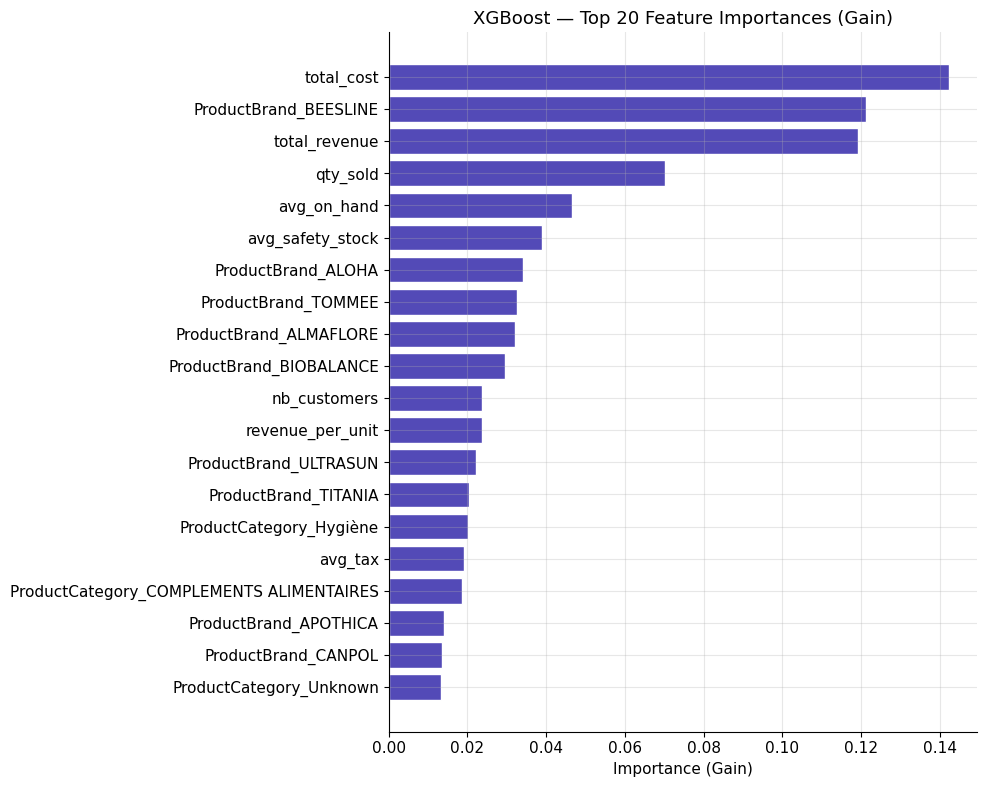

                                 feature  importance
                              total_cost    0.142290
                   ProductBrand_BEESLINE    0.121242
                           total_revenue    0.119196
                                qty_sold    0.070243
                             avg_on_hand    0.046569
                        avg_safety_stock    0.038938
                      ProductBrand_ALOHA    0.034166
                     ProductBrand_TOMMEE    0.032473
                  ProductBrand_ALMAFLORE    0.032040
                 ProductBrand_BIOBALANCE    0.029490
                            nb_customers    0.023674
                        revenue_per_unit    0.023627
                   ProductBrand_ULTRASUN    0.022209
                    ProductBrand_TITANIA    0.020453
                 ProductCategory_Hygiène    0.020179
                                 avg_tax    0.019029
ProductCategory_COMPLEMENTS ALIMENTAIRES    0.018624
                   ProductBrand_APOTHICA    0.

In [64]:
xgb_clf     = xgb_best.named_steps['reg']
importances = xgb_clf.feature_importances_

feat_imp_df4 = (pd.DataFrame({'feature': all_features, 'importance': importances})
                .sort_values('importance', ascending=False)
                .head(20))  # Top 20

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp_df4['feature'][::-1], feat_imp_df4['importance'][::-1],
        color=C4['xgb'], edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances (Gain)', fontsize=13)
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig('goal4_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(feat_imp_df4.to_string(index=False))

### D.8 — Ridge Regression: Top Coefficients

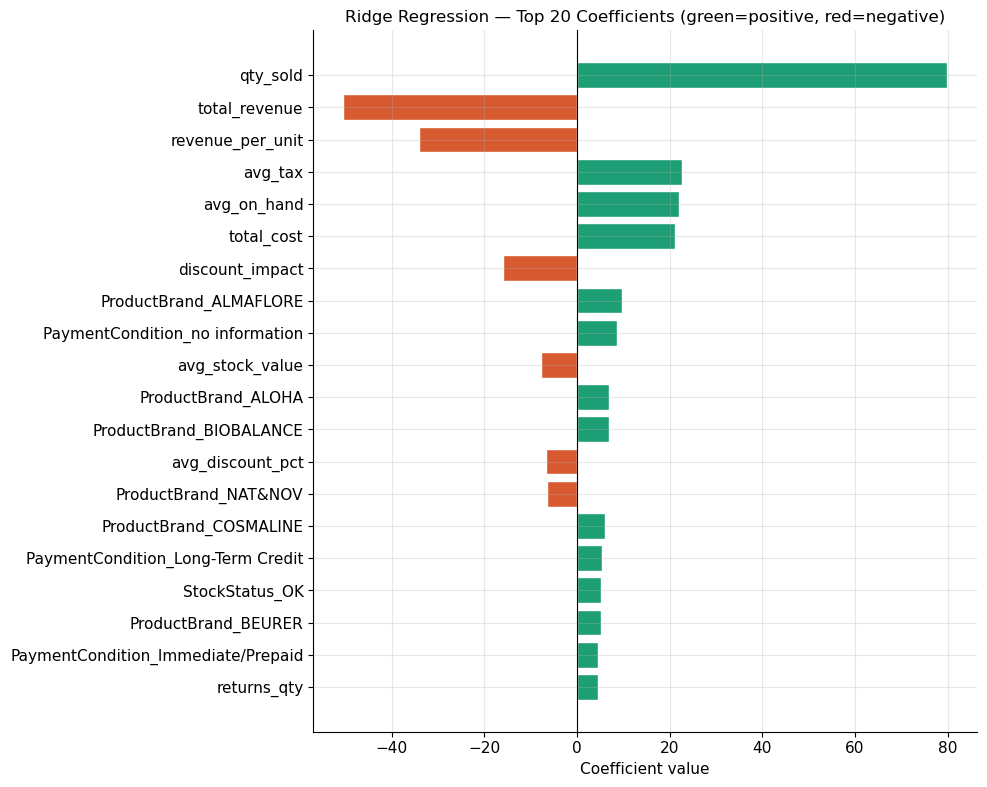

In [65]:
ridge_clf = ridge_best.named_steps['reg']
coef_df   = (pd.DataFrame({'feature': all_features, 'coefficient': ridge_clf.coef_})
             .reindex(pd.Series(ridge_clf.coef_).abs().sort_values(ascending=False).index)
             .head(20))
# Rebuild with proper sort
coef_df = (pd.DataFrame({'feature': all_features, 'coefficient': ridge_clf.coef_})
           .assign(abs_coef=lambda d: d['coefficient'].abs())
           .sort_values('abs_coef', ascending=False)
           .head(20))

colors_coef = [C4['pos'] if v > 0 else C4['neg'] for v in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1],
        color=colors_coef[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Ridge Regression — Top 20 Coefficients (green=positive, red=negative)', fontsize=12)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('goal4_ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION F — Model Comparison & Business Interpretation

### F.1 — Metric Comparison Table

In [66]:
comparison4 = pd.DataFrame([
    {'Model': 'Ridge Regression', 'R²': ridge_r2, 'MAE': ridge_mae, 'RMSE': ridge_rmse},
    {'Model': 'XGBoost Regressor','R²': xgb_r2,   'MAE': xgb_mae,   'RMSE': xgb_rmse},
]).round(4)

print(comparison4.to_string(index=False))

winner4 = comparison4.loc[comparison4['R²'].idxmax(), 'Model']
print(f"\n→ Best model by R²: {winner4}")

            Model     R²     MAE    RMSE
 Ridge Regression 0.4083 34.3471 78.3115
XGBoost Regressor 0.9747  4.0576 16.2019

→ Best model by R²: XGBoost Regressor


### F.2 — Margin Prediction by Product Category

                          avg_actual_margin  avg_predicted_margin  avg_error  n_records
ProductCategory                                                                        
ANIMALERIE                           -17.16            -17.590000       0.42        127
Hygiène                              -32.71            -31.900000      -0.81        163
Bio & naturel                        -40.68            -40.360001      -0.32         37
Cheveux                              -46.13            -45.220001      -0.91        139
TOILETTE                             -53.24            -53.060001      -0.18       7199
Corps                                -57.09            -56.709999      -0.38         75
COMPLEMENTS ALIMENTAIRES             -59.11            -59.299999       0.19        478
Bébé et Maman                        -61.24            -61.500000       0.26        127
Unknown                              -61.56            -62.099998       0.54        138
Materiel medical                

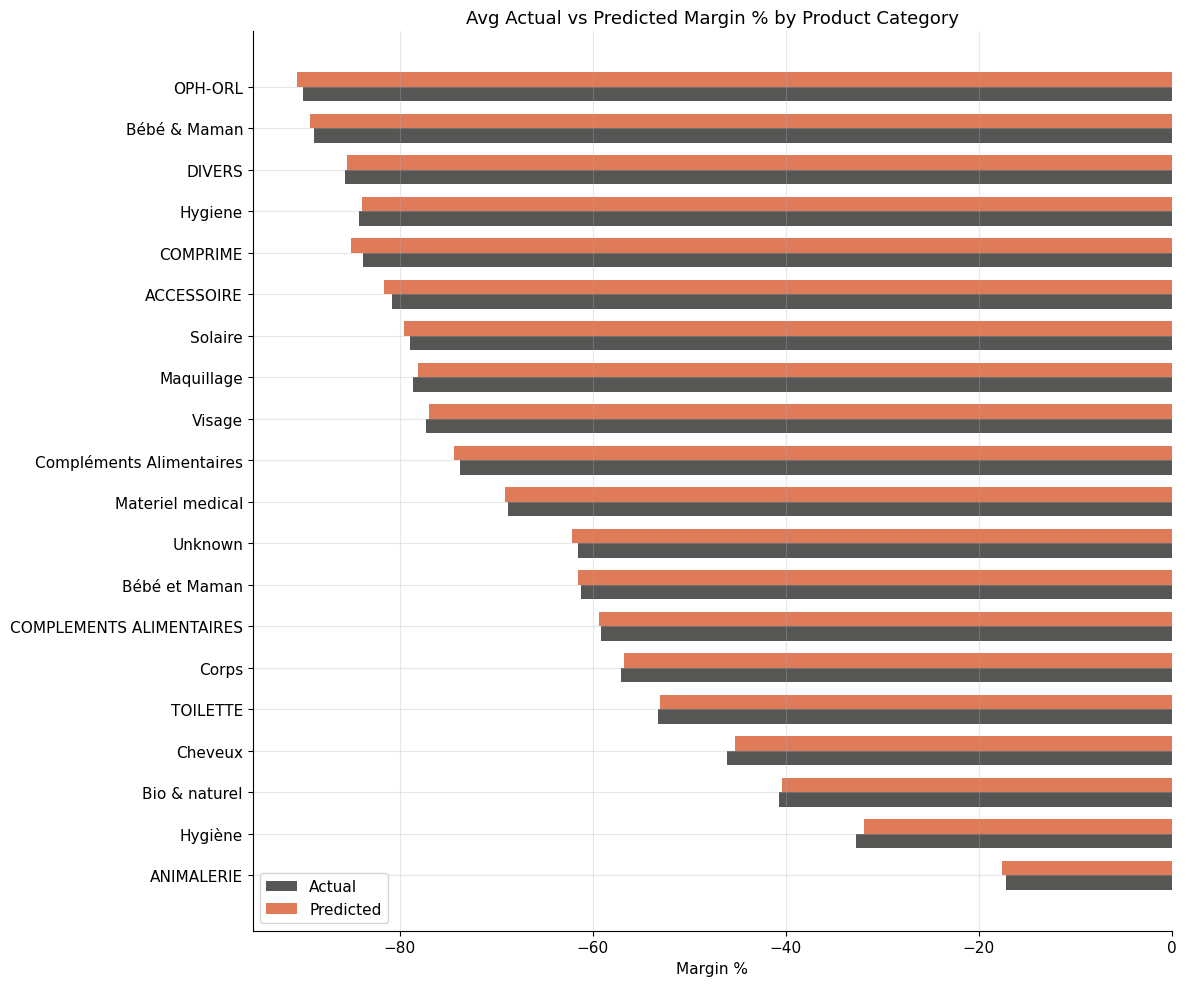

In [67]:
best_model4 = xgb_best if xgb_r2 >= ridge_r2 else ridge_best
X_full4     = df_encoded[all_features].fillna(0)

# Force all columns to float — XGBoost rejects object dtype (e.g. LeadTimeDays read as string)
X_full4 = X_full4.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)

df_mgn['predicted_margin_pct'] = best_model4.predict(X_full4)
df_mgn['margin_error']         = df_mgn['margin_pct'] - df_mgn['predicted_margin_pct']

if 'ProductCategory' in df_mgn.columns:
    cat_summary = (df_mgn.groupby('ProductCategory')
                         .agg(
                             avg_actual_margin  = ('margin_pct',           'mean'),
                             avg_predicted_margin=('predicted_margin_pct', 'mean'),
                             avg_error          = ('margin_error',         'mean'),
                             n_records          = ('margin_pct',           'count')
                         )
                         .round(2)
                         .sort_values('avg_actual_margin', ascending=False))
    print(cat_summary.to_string())

    fig, ax = plt.subplots(figsize=(12, max(5, len(cat_summary) * 0.5)))
    x = np.arange(len(cat_summary))
    w = 0.35
    ax.barh(x - w/2, cat_summary['avg_actual_margin'],    w, label='Actual',    color=C4['actual'], alpha=0.8)
    ax.barh(x + w/2, cat_summary['avg_predicted_margin'], w, label='Predicted', color=C4['pred'],   alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(cat_summary.index)
    ax.set_title('Avg Actual vs Predicted Margin % by Product Category', fontsize=13)
    ax.set_xlabel('Margin %')
    ax.legend()
    plt.tight_layout()
    plt.savefig('goal4_margin_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("ProductCategory not in df_mgn — skipping category breakdown.")

### F.3 — Price Fluctuation Risk Flagging

Products with high prediction error are candidates for pricing review.

In [68]:
# Flag products where abs(error) > 2 std deviations
err_std   = df_mgn['margin_error'].std()
err_mean  = df_mgn['margin_error'].mean()
threshold = 2 * err_std

df_mgn['price_fluctuation_risk'] = np.where(
    df_mgn['margin_error'].abs() > threshold, 'High', 'Normal'
)

risk_counts = df_mgn['price_fluctuation_risk'].value_counts()
print(f"Fluctuation risk threshold: ±{threshold:.2f}%")
print(f"High-risk records : {risk_counts.get('High', 0)}")
print(f"Normal records    : {risk_counts.get('Normal', 0)}")

# Show top high-risk products
high_risk_cols = ['ProductName','ProductCategory','margin_pct','predicted_margin_pct','margin_error']
high_risk_cols = [c for c in high_risk_cols if c in df_mgn.columns]
print("\nTop 10 high-risk products (largest absolute error):")
print(df_mgn[df_mgn['price_fluctuation_risk']=='High']
      .assign(abs_error=df_mgn['margin_error'].abs())
      .nlargest(10, 'abs_error')[high_risk_cols]
      .to_string(index=False))

Fluctuation risk threshold: ±17.12%
High-risk records : 118
Normal records    : 8833

Top 10 high-risk products (largest absolute error):
                                             ProductName ProductCategory  margin_pct  predicted_margin_pct  margin_error
                  BEESLINE SEBUM CONTROL BALANCING SERUM        TOILETTE  109.890175            487.593018   -377.702843
                          TYNOR SOUTIEN DOS DE POSTURE L        TOILETTE  672.939359            394.150970    278.788389
                 CLARENIA HB5 SERUM HYDRA REPULPANT 30ML        TOILETTE   74.305532            337.669739   -263.364207
                       TITANIA 1033/B 3BATONNETS DE BOIS        TOILETTE  672.939359            431.036072    241.903288
       LES PETITS BAINS BAIGNOIRE FLEUR DE COTON  ARGENT        TOILETTE   38.807163            182.858475   -144.051312
                  CANPOL BABIES CUP STRAW 270ML 6M+ ROSE        TOILETTE  611.524382            499.671722    111.852659
               

---
## Results Summary

| Aspect | Finding |
|--------|---------|
| Target | `margin_pct` = gross margin % per product/supplier/period |
| Features | 18 numeric + OHE categoricals (category, brand, season, stock status, payment condition) |
| Derived features | price-cost spread, price markup %, discount impact, stock coverage, revenue per unit |
| Best model | Determined by R² — see F.1 |
| Top predictors | `price_markup_pct`, `price_cost_spread`, `avg_discount_pct` (see D.7) |
| Fluctuation flagging | Products with prediction error > 2σ flagged as High price-fluctuation risk |
| Business use | Re-price flagged products; negotiate supplier terms for low-margin SKUs; monitor seasonal margin dips |
| Next step | Schedule weekly re-prediction pipeline; export `predicted_margin_pct` and `price_fluctuation_risk` to DWH |

---
## 🏁 All 4 Goals Complete

| Goal | Objective | Models | Section |
|------|-----------|--------|---------|
| Goal 1 | Sales Volume Forecasting | SARIMA + XGBoost Time Series | Section F |
| Goal 2 | Customer Segmentation | K-Means + DBSCAN | Section E |
| Goal 3 | Creditworthiness Classification | Logistic Regression + Random Forest | Section C |
| Goal 4 | Margin & Price Fluctuation Prediction | Ridge Regression + XGBoost Regressor | Section D |

---
# Advanced Goal A — Product Recommendation System
### Objective → *Suggest the right products to the right customers*
### Approach: Collaborative Filtering (User-Item Matrix) + Matrix Factorization (SVD) + Item-Based Cosine Similarity

---
## 0. Setup (additional imports for Recommendation System)

In [69]:
# Recommendation System imports
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Reuse QUERY_GOAL2_SEGMENTATION data (ClientID × ProductID purchase history)
# We also need product-level purchase data → use QUERY_GOAL4_MARGIN which has ProductID + ClientID
from db_connection import QUERY_GOAL4_MARGIN

C_rec = {'main':'#1D9E75','sec':'#534AB7','heat':'RdYlGn','highlight':'#D85A30'}
print('✓ Recommendation System imports complete')

✓ Recommendation System imports complete


---
## 1. Data Extraction & User-Item Matrix Construction

In [70]:
# Dedicated query: keep raw ClientID × ProductID pairs for collaborative filtering
QUERY_RECO = """
SELECT
    f.ClientID,
    f.ProductID,
    p.ProductName,
    p.ProductCategory,
    SUM(f.SoldItemsQty)   AS qty_sold,
    SUM(f.TotalSales)     AS total_revenue
FROM [dwh_parapharmacie].[dbo].[Fact_Revenus]  f
JOIN [dwh_parapharmacie].[dbo].[DIM_Product]   p
    ON f.ProductID = p.ProductID
WHERE f.DocumentType IN ('VenteComptoir','FactureClient','BonLivraison')
  AND f.ClientID   IS NOT NULL
  AND f.ProductID  IS NOT NULL
GROUP BY f.ClientID, f.ProductID, p.ProductName, p.ProductCategory
"""

conn_rec = get_connection()
df_rec   = run_query(QUERY_RECO, conn_rec)
conn_rec.close()

print("Shape:", df_rec.shape)
print("Unique customers:", df_rec['ClientID'].nunique())
print("Unique products :", df_rec['ProductID'].nunique())
df_rec.head()

✓ Connected  [dwh_parapharmacie] on [DESKTOP-TRG6BMQ]
✓ 5,972 rows × 6 columns
Shape: (5972, 6)
Unique customers: 25
Unique products : 3486


,ClientID,ProductID,ProductName,ProductCategory,qty_sold,total_revenue
0,2,7,ALANIA ECRAN UV TEINT? 01 LIGHT,TOILETTE,24,349.188995
1,7,7,ALANIA ECRAN UV TEINT? 01 LIGHT,TOILETTE,45,657.293991
2,15,7,ALANIA ECRAN UV TEINT? 01 LIGHT,TOILETTE,1,14.687000
3,2,35,ALMAFLORE HUILE DE FIGUE DE BARBARIE 50ML,TOILETTE,1,26.799000
4,2,42,ELMEX BAD SENSITIVE,ACCESSOIRE,2,8.996000


### A.1 — Build User-Item Purchase Matrix

Each row = a customer, each column = a product.  
Cell value = **total quantity purchased** (implicit feedback signal).  
Missing values = 0 (customer never bought that product).

In [71]:
# Aggregate ClientID × ProductID → total qty
df_ui = (df_rec.groupby(['ClientID','ProductID'])['qty_sold']
               .sum()
               .reset_index()
               .rename(columns={'qty_sold':'total_qty'}))

# Filter: keep only customers with ≥2 purchases and products bought by ≥2 customers
min_purchases  = 2
min_customers  = 2
active_clients = df_ui.groupby('ClientID')['total_qty'].sum()
active_clients = active_clients[active_clients >= min_purchases].index
popular_prods  = df_ui.groupby('ProductID')['ClientID'].nunique()
popular_prods  = popular_prods[popular_prods >= min_customers].index

df_ui = df_ui[df_ui['ClientID'].isin(active_clients) &
              df_ui['ProductID'].isin(popular_prods)]

# Pivot to user-item matrix
ui_matrix = df_ui.pivot_table(index='ClientID', columns='ProductID',
                               values='total_qty', fill_value=0)

print(f"User-Item matrix shape: {ui_matrix.shape}")
print(f"  Customers: {ui_matrix.shape[0]}  |  Products: {ui_matrix.shape[1]}")
sparsity = (ui_matrix == 0).sum().sum() / ui_matrix.size * 100
print(f"  Sparsity: {sparsity:.1f}%")

User-Item matrix shape: (21, 1691)
  Customers: 21  |  Products: 1691
  Sparsity: 88.3%


### A.2 — Normalize with Log Scaling

Raw quantities are skewed (a single customer may buy 1000 units of one product).  
Log-scaling compresses the range and treats implicit feedback more fairly.

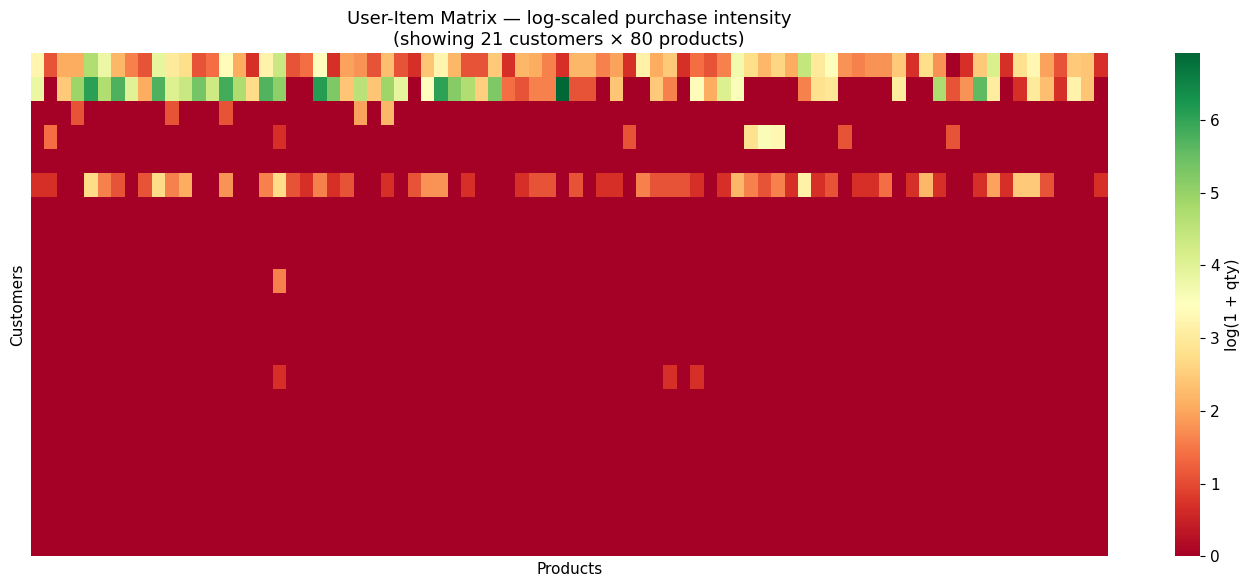

In [72]:
import numpy as np

ui_log = np.log1p(ui_matrix)  # log(1 + qty) → handles zeros

# Visualise sparsity pattern (sample up to 50 customers × 80 products)
sample_rows = min(50, ui_log.shape[0])
sample_cols = min(80, ui_log.shape[1])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(ui_log.iloc[:sample_rows, :sample_cols],
            cmap=C_rec['heat'], ax=ax,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label':'log(1 + qty)'})
ax.set_title(f'User-Item Matrix — log-scaled purchase intensity\n(showing {sample_rows} customers × {sample_cols} products)', fontsize=13)
ax.set_xlabel('Products')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.savefig('reco_user_item_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION B — Model Understanding

### B.1 — Item-Based Collaborative Filtering (Cosine Similarity)

**Intuition:**  
Two products are "similar" if the same customers buy them together.  
We compute cosine similarity between every pair of product vectors (columns of the user-item matrix).  
To recommend for a customer: find products they haven't bought yet that are most similar to what they have bought.

| Concept | Detail |
|---|---|
| Similarity metric | Cosine similarity (angle between product vectors) |
| Input | Log-scaled user-item matrix |
| Output | Top-N unseen products per customer |
| Complexity | O(P²) where P = number of products |

**Advantages:** Simple, interpretable, no training needed, works on sparse data.  
**Limitations:** Cold-start problem (new customers/products have no history); popularity bias.

### B.2 — Matrix Factorization (SVD / Latent Factor Model)

**Intuition:**  
Decompose the user-item matrix R ≈ U × Σ × Vᵀ into:
- **U** — user latent factors (each customer's "taste profile")
- **Σ** — singular values (importance of each latent dimension)  
- **Vᵀ** — item latent factors (each product's "feature profile")

Recommendations = predict missing entries by reconstructing R̂ = U × Σ × Vᵀ.

| Hyperparameter | Meaning |
|---|---|
| `n_components` | Number of latent factors (tune via explained variance) |

**Advantages:** Handles sparsity well; captures latent taste patterns; more accurate than pure cosine.  
**Limitations:** Less interpretable; requires tuning n_components; still has cold-start issues.

---
## SECTION C — Models

### C.1 — Item-Based Cosine Similarity

Item similarity matrix shape: (1691, 1691)


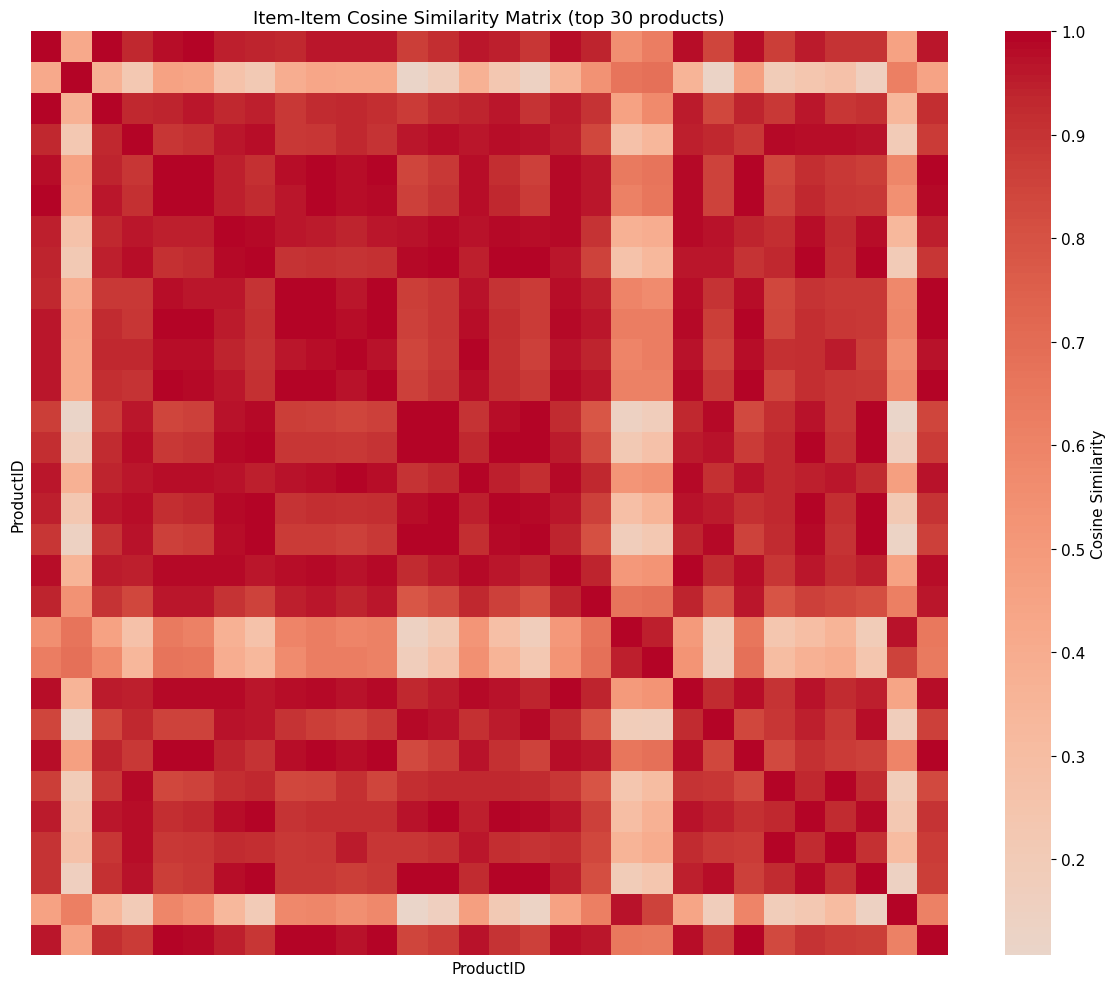

In [73]:
# Compute item-item cosine similarity on log-scaled matrix
# Guard against inf/NaN: clip negatives before log, replace any residual inf
ui_clean = ui_matrix.clip(lower=0)                     # no negative quantities
ui_log_t = np.log1p(ui_clean).replace([np.inf, -np.inf], 0).fillna(0)

item_sim_matrix = cosine_similarity(ui_log_t.T)
item_sim_df     = pd.DataFrame(item_sim_matrix,
                                index=ui_log_t.columns,
                                columns=ui_log_t.columns)

# Keep ui_log in sync for downstream cells
ui_log = ui_log_t

print(f"Item similarity matrix shape: {item_sim_df.shape}")

# Visualise top corner
n_show = min(30, item_sim_df.shape[0])
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(item_sim_df.iloc[:n_show, :n_show],
            cmap='coolwarm', center=0, ax=ax,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label':'Cosine Similarity'})
ax.set_title(f'Item-Item Cosine Similarity Matrix (top {n_show} products)', fontsize=13)
plt.tight_layout()
plt.savefig('reco_item_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

### C.2 — Item-Based Recommendation Function

In [74]:
def get_similar_products(product_id, top_n=5):
    """Return top_n most similar products to a given product_id."""
    if product_id not in item_sim_df.index:
        return pd.DataFrame(columns=['ProductID','similarity'])
    sims = item_sim_df[product_id].drop(index=product_id).sort_values(ascending=False)
    return sims.head(top_n).reset_index().rename(columns={product_id:'similarity','index':'ProductID'})


def recommend_for_customer_item_based(client_id, top_n=5):
    """Recommend top_n unseen products for a customer using item-based CF."""
    if client_id not in ui_log.index:
        return pd.DataFrame(columns=['ProductID','score'])

    bought     = ui_log.loc[client_id]
    bought_ids = bought[bought > 0].index.tolist()

    # Score each unseen product as weighted sum of similarity to bought products
    scores = {}
    for prod in ui_log.columns:
        if prod in bought_ids:
            continue
        sim_scores = item_sim_df.loc[prod, bought_ids]
        weights    = bought[bought_ids]
        score      = (sim_scores * weights).sum() / (weights.sum() + 1e-9)
        scores[prod] = score

    rec_df = (pd.Series(scores)
                .sort_values(ascending=False)
                .head(top_n)
                .reset_index()
                .rename(columns={'index':'ProductID', 0:'score'}))
    return rec_df


# Demo on first available customer
demo_client = ui_log.index[0]
print(f"Item-based recommendations for Customer {demo_client}:")
recs_item = recommend_for_customer_item_based(demo_client, top_n=10)

# Enrich with product names if available
if 'ProductName' in df_rec.columns:
    prod_names = df_rec[['ProductID','ProductName']].drop_duplicates()
    recs_item  = recs_item.merge(prod_names, on='ProductID', how='left')

print(recs_item.to_string(index=False))

Item-based recommendations for Customer 2:
 ProductID    score                                      ProductName
       949 0.490780         3CHENES COLORATION 7GC BLOND DORE CUIVRE
      2190 0.490780                      LOUBSOL LOUPE SIGNORET +1.5
      2232 0.490780                      SCHOLL TESSA BLANC CASS? 40
      2224 0.485382               SANTIVERI GRAINES DE CHIA BIO 250G
      4499 0.485382                    LPO SAVON LIQUIDE OLIVE 300ML
      4566 0.485382        TITANIA 1360 HAIR BROSSE PNEUM RECT  NOIR
      2988 0.485330            TYNOR ELINGUE POCHE BRAS (TROPICAL) M
       800 0.485330                 REFLUGO ANTI-ACIDE MENTHE POIVRE
       507 0.480118 BABE PEDIATRIC NAPPY RASH TWIN CREME CHANGE100ML
      1351 0.480118      EYE CARE MASCARA VOLUMATEUR ULTRA BRUN 6000


### C.3 — Matrix Factorization (TruncatedSVD)

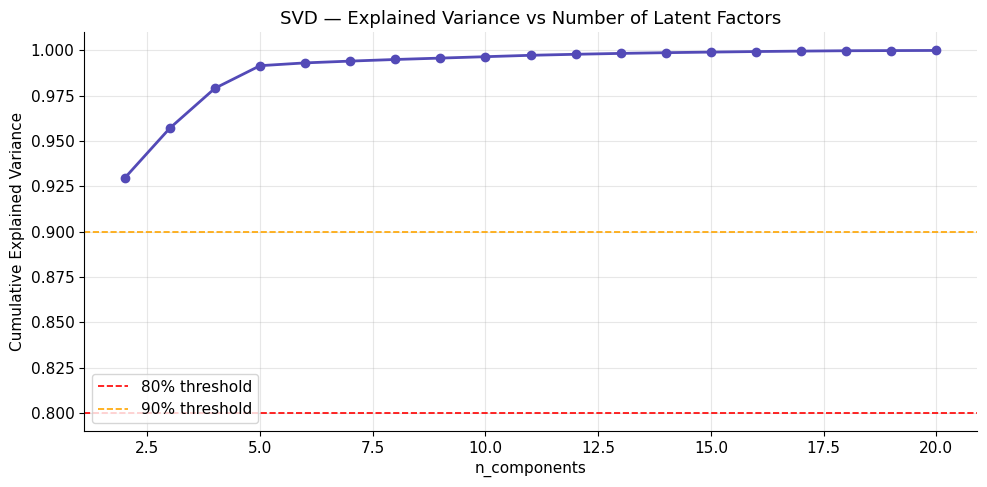

Selected n_components = 2  (explains 93.0% variance)


In [75]:
# Tune n_components via explained variance
variance_ratios = []
components_range = range(2, min(51, min(ui_log.shape)))

for n in components_range:
    svd_tmp = TruncatedSVD(n_components=n, random_state=42)
    svd_tmp.fit(ui_log)
    variance_ratios.append(svd_tmp.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(components_range), variance_ratios, 'o-', color=C_rec['sec'], lw=2)
ax.axhline(0.80, color='red', lw=1.2, linestyle='--', label='80% threshold')
ax.axhline(0.90, color='orange', lw=1.2, linestyle='--', label='90% threshold')
ax.set_title('SVD — Explained Variance vs Number of Latent Factors', fontsize=13)
ax.set_xlabel('n_components')
ax.set_ylabel('Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig('reco_svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick n_components that explains ≥80% variance
best_n = next((n for n, v in zip(components_range, variance_ratios) if v >= 0.80),
              list(components_range)[-1])
print(f"Selected n_components = {best_n}  (explains {variance_ratios[list(components_range).index(best_n)]:.1%} variance)")

In [76]:
# Fit final SVD
svd = TruncatedSVD(n_components=best_n, random_state=42)
U   = svd.fit_transform(ui_log)          # Users in latent space  (n_users × k)
Vt  = svd.components_                    # Items in latent space  (k × n_items)
S   = np.diag(svd.singular_values_)

# Reconstruct full predicted rating matrix
R_hat = pd.DataFrame(U @ Vt,
                     index=ui_log.index,
                     columns=ui_log.columns)

print(f"SVD fitted — U: {U.shape}  Vt: {Vt.shape}")
print(f"Reconstructed matrix R̂: {R_hat.shape}")

SVD fitted — U: (21, 2)  Vt: (2, 1691)
Reconstructed matrix R̂: (21, 1691)


### C.4 — SVD Recommendation Function

In [77]:
def recommend_svd(client_id, top_n=5):
    """Recommend top_n unseen products for a customer using SVD predictions."""
    if client_id not in R_hat.index:
        return pd.DataFrame(columns=['ProductID','predicted_score'])

    already_bought = ui_log.loc[client_id][ui_log.loc[client_id] > 0].index.tolist()
    predictions    = R_hat.loc[client_id].drop(index=already_bought, errors='ignore')
    rec_df         = (predictions.sort_values(ascending=False)
                                 .head(top_n)
                                 .reset_index()
                                 .rename(columns={'ProductID':'ProductID',
                                                  client_id:'predicted_score'}))
    rec_df.columns = ['ProductID','predicted_score']
    return rec_df


# Demo
print(f"SVD recommendations for Customer {demo_client}:")
recs_svd = recommend_svd(demo_client, top_n=10)

if 'ProductName' in df_rec.columns:
    recs_svd = recs_svd.merge(prod_names, on='ProductID', how='left')

print(recs_svd.to_string(index=False))

SVD recommendations for Customer 2:
 ProductID  predicted_score                                  ProductName
      3932         0.812361   SOBER STABILIG 20 3PANNEAUX LARGE FU S L67
      5276         0.563715                     BOUILLOTTE SHOOP'S NUAGE
      2988         0.477523        TYNOR ELINGUE POCHE BRAS (TROPICAL) M
      3283         0.437917   TYNOR ATTELLE DE POIGNET AVEC POUCE XL E44
      3516         0.436147            XEN KERATIN Q10 SERUM SPF30 100ML
      4873         0.435128                 FILORGA NUTRI FILLER LIPS 4G
      1159         0.418600 CANPOL BABIES LIQUIDE RINCAGE BIBERONS 500ML
      4504         0.414907       LRP ANTHELIOS GEL OIL CONTROL SPF50 TT
       510         0.390138           BABE STOP AKN SPOT CONTROL GEL 8ML
      4663         0.378925           TITANIA HAIR BROSSE SQUELETTE 2881


### C.5 — Side-by-Side Comparison (Item-Based vs SVD)

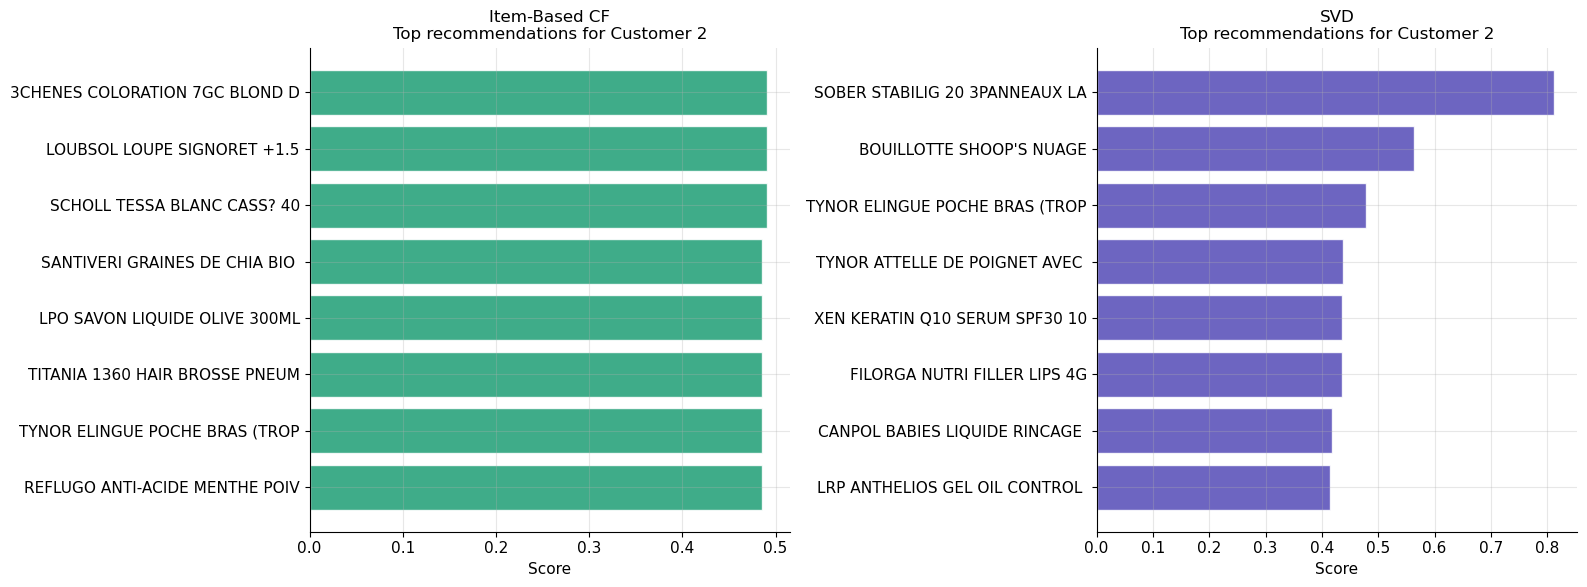

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, recs, score_col, color) in zip(axes, [
    ('Item-Based CF',  recs_item, 'score',           C_rec['main']),
    ('SVD',            recs_svd,  'predicted_score',  C_rec['sec'])
]):
    label_col = 'ProductName' if 'ProductName' in recs.columns else 'ProductID'
    recs_plot = recs.head(8).copy()
    recs_plot[label_col] = recs_plot[label_col].astype(str).str[:30]
    ax.barh(recs_plot[label_col][::-1], recs_plot[score_col][::-1],
            color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{title}\nTop recommendations for Customer {demo_client}', fontsize=12)
    ax.set_xlabel('Score')

plt.tight_layout()
plt.savefig('reco_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### C.6 — Customer Latent Factor Visualisation (SVD 2D)

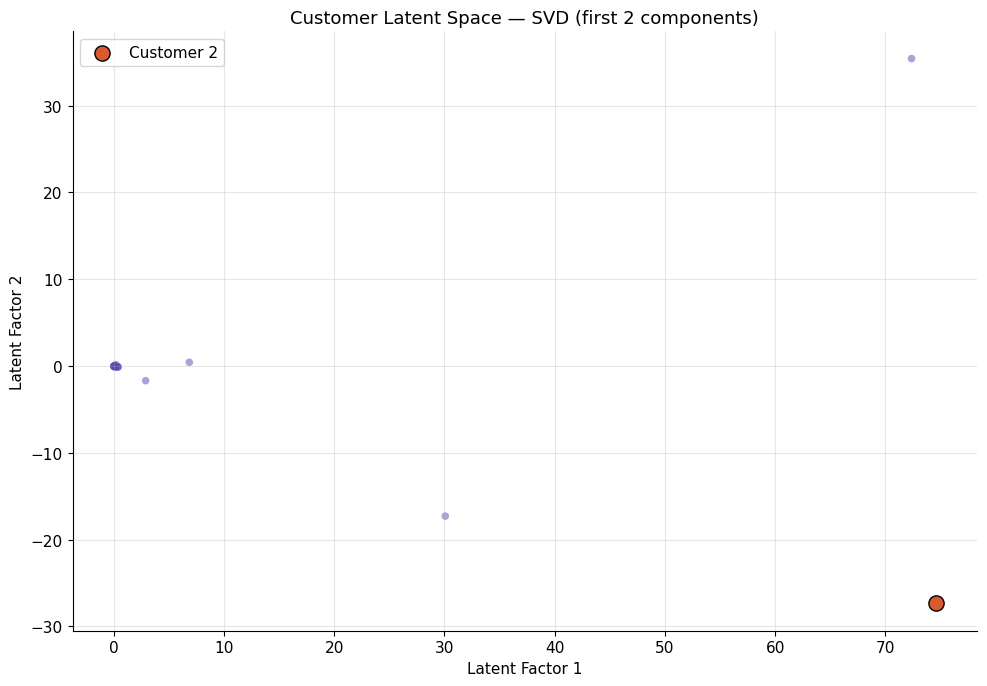

In [80]:
# Project users into 2D using first 2 SVD components
U_2d = U[:, :2]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(U_2d[:, 0], U_2d[:, 1], alpha=0.5, s=30, color=C_rec['sec'], edgecolors='none')

# Highlight demo customer
if demo_client in ui_log.index:
    idx = list(ui_log.index).index(demo_client)
    ax.scatter(U_2d[idx, 0], U_2d[idx, 1],
               s=120, color=C_rec['highlight'], zorder=5,
               label=f'Customer {demo_client}', edgecolors='black')
    ax.legend(fontsize=11)

ax.set_title('Customer Latent Space — SVD (first 2 components)', fontsize=13)
ax.set_xlabel('Latent Factor 1')
ax.set_ylabel('Latent Factor 2')
plt.tight_layout()
plt.savefig('reco_customer_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

### C.7 — Batch Recommendations Export

In [81]:
# Generate top-5 SVD recommendations for every customer
all_recs = []
for cid in ui_log.index:
    recs = recommend_svd(cid, top_n=5)
    recs.insert(0, 'ClientID', cid)
    all_recs.append(recs)

df_all_recs = pd.concat(all_recs, ignore_index=True)

if 'ProductName' in df_rec.columns:
    df_all_recs = df_all_recs.merge(prod_names, on='ProductID', how='left')

print(f"Total recommendations generated: {len(df_all_recs)}")
print(f"Customers covered              : {df_all_recs['ClientID'].nunique()}")
print("\nSample:")
print(df_all_recs.head(15).to_string(index=False))

Total recommendations generated: 105
Customers covered              : 21

Sample:
 ClientID  ProductID  predicted_score                                       ProductName
        2       3932         0.812361        SOBER STABILIG 20 3PANNEAUX LARGE FU S L67
        2       5276         0.563715                          BOUILLOTTE SHOOP'S NUAGE
        2       2988         0.477523             TYNOR ELINGUE POCHE BRAS (TROPICAL) M
        2       3283         0.437917        TYNOR ATTELLE DE POIGNET AVEC POUCE XL E44
        2       3516         0.436147                 XEN KERATIN Q10 SERUM SPF30 100ML
        7       1974         0.176297                   PURALIA SHAMP NOURRISSANT 250ML
        7       5703         0.160140                     VITAVEA CURCUMA PIPERINE B/30
        7       2830         0.149549 NEUTRADERM GEL DOUCHE MICELLAIRE DERM APAIS 500ML
        7       5447         0.146110                 NANA CARTON 24  MAXI CLIP NRML 10
        7       5373         0.131985 

---
## Results Summary — Recommendation System

| Aspect | Detail |
|--------|--------|
| Approach | Item-Based Collaborative Filtering + SVD Matrix Factorization |
| Input signal | Implicit feedback (purchase quantity per customer-product pair) |
| Normalization | log(1 + qty) to compress skewed quantities |
| SVD components | Selected to explain ≥80% variance |
| Output | Top-N product recommendations per customer |
| Business use | Personalised upsell in CRM; bundle promotions; "customers also bought" |
| Cold-start | New customers → use popularity-based fallback (top-selling products) |
| Next step | A/B test recommendations vs. no-recommendation control group |

---
# Advanced Goal B — Anomaly Detection
### Objective → *Flag abnormal sales, return spikes & payment irregularities*
### Approach: Isolation Forest + Autoencoder (reconstruction error)

---
## 0. Setup (additional imports for Anomaly Detection)

In [82]:
# Anomaly Detection imports
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Deep learning autoencoder
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print(f"✓ TensorFlow {tf.__version__} available — Autoencoder will run")
except ImportError:
    TF_AVAILABLE = False
    print("⚠ TensorFlow not found — Autoencoder section will be skipped")
    print("  Install with: pip install tensorflow")

C_ano = {'normal':'#1D9E75','anomaly':'#D85A30','thresh':'#534AB7'}
print('✓ Anomaly Detection imports complete')

⚠ TensorFlow not found — Autoencoder section will be skipped
  Install with: pip install tensorflow
✓ Anomaly Detection imports complete


---
## 1. Data Preparation

### A.1 — Reuse Time Series Data (Goal 1) + Credit Data (Goal 3)

In [83]:
# ── Signal 1: Daily sales time series (from Goal 1)
# df_daily is already in memory from Goal 1
ano_daily = df_daily[['total_revenue','total_qty_sold','nb_transactions',
                       'total_returns_qty','total_discounts']].copy().fillna(0)

# ── Signal 2: Transaction-level features (from Goal 3 credit data)
ano_credit = df_cred[['avg_payment_delay','max_payment_delay',
                       'nb_unpaid','total_receivable',
                       'total_returns','total_discount']].copy().fillna(0)

print("Daily sales signals shape :", ano_daily.shape)
print("Credit/payment signals shape:", ano_credit.shape)

Daily sales signals shape : (213, 5)
Credit/payment signals shape: (25, 6)


### A.2 — Feature Matrix for Anomaly Detection

In [84]:
# ── Build anomaly feature matrix from daily time series
#    Add rolling statistics as context features
window = 7
for col in ['total_revenue','total_qty_sold','nb_transactions','total_returns_qty']:
    ano_daily[f'{col}_roll7_mean'] = ano_daily[col].rolling(window, min_periods=1).mean()
    ano_daily[f'{col}_roll7_std']  = ano_daily[col].rolling(window, min_periods=1).std().fillna(0)
    ano_daily[f'{col}_z']          = np.where(
        ano_daily[f'{col}_roll7_std'] > 0,
        (ano_daily[col] - ano_daily[f'{col}_roll7_mean']) / ano_daily[f'{col}_roll7_std'], 0)

# Feature set for anomaly detection
ano_feature_cols = [c for c in ano_daily.columns if '_z' in c or c in
                    ['total_revenue','total_qty_sold','nb_transactions','total_returns_qty','total_discounts']]
X_ano = ano_daily[ano_feature_cols].fillna(0)

scaler_ano = StandardScaler()
X_ano_scaled = scaler_ano.fit_transform(X_ano)

print(f"Anomaly feature matrix: {X_ano_scaled.shape}")
print(f"Features: {ano_feature_cols}")

Anomaly feature matrix: (213, 9)
Features: ['total_revenue', 'total_qty_sold', 'nb_transactions', 'total_returns_qty', 'total_discounts', 'total_revenue_z', 'total_qty_sold_z', 'nb_transactions_z', 'total_returns_qty_z']


---
## SECTION B — Model Understanding

### B.1 — Isolation Forest

**Intuition:**  
Isolation Forest isolates anomalies by randomly partitioning the data with decision trees.  
Anomalies are **isolated faster** (fewer splits needed) because they are rare and lie far from the bulk of the data.  
The anomaly score = average path length across all trees — shorter path → more anomalous.

| Hyperparameter | Meaning |
|---|---|
| `n_estimators` | Number of isolation trees (100–500) |
| `contamination` | Expected fraction of anomalies (0.01–0.10) |
| `max_samples` | Subsample size per tree (`'auto'` = min(256, n_samples)) |

**Advantages:** Fast, scalable, no distributional assumptions, works on high-dimensional data.  
**Limitations:** Struggles with very high-dimensional data; contamination must be estimated.

### B.2 — Autoencoder (Deep Learning)

**Intuition:**  
An Autoencoder is a neural network trained to **reconstruct its own input** through a compressed bottleneck.  
Trained only on normal data, it learns the "normal" pattern.  
At inference, **anomalies have high reconstruction error** because the network was never trained to reproduce them.

```
Input → [Encoder: Dense layers] → Bottleneck → [Decoder: Dense layers] → Reconstructed Input
                                                                         ↓
                                                               Reconstruction Error (MSE)
                                                               High error → Anomaly
```

| Component | Detail |
|---|---|
| Encoder | 2–3 Dense layers with ReLU, shrinking to bottleneck |
| Bottleneck | Compressed representation (e.g. 4–8 units) |
| Decoder | Mirror of encoder, expanding back to input size |
| Loss | Mean Squared Error (MSE) |
| Threshold | 95th percentile of training reconstruction errors |

**Advantages:** Captures complex non-linear patterns; no contamination parameter needed.  
**Limitations:** Requires TensorFlow/Keras; longer training; threshold choice is heuristic.

---
## SECTION C — Models

### C.1 — Isolation Forest: Fit & Score

In [85]:
# Fit Isolation Forest
contamination = 0.05  # assume ~5% of days are anomalous
iso_forest = IsolationForest(n_estimators=200,
                              contamination=contamination,
                              max_samples='auto',
                              random_state=42,
                              n_jobs=-1)
iso_forest.fit(X_ano_scaled)

# Predictions: -1 = anomaly, 1 = normal
iso_labels  = iso_forest.predict(X_ano_scaled)
iso_scores  = iso_forest.decision_function(X_ano_scaled)  # lower = more anomalous

ano_daily['iso_label'] = iso_labels
ano_daily['iso_score'] = iso_scores
ano_daily['is_anomaly_iso'] = (iso_labels == -1).astype(int)

n_anomalies = (iso_labels == -1).sum()
print(f"Isolation Forest — {n_anomalies} anomalies detected ({n_anomalies/len(iso_labels):.1%} of days)")
print(f"Anomaly score range: [{iso_scores.min():.3f}, {iso_scores.max():.3f}]")

Isolation Forest — 11 anomalies detected (5.2% of days)
Anomaly score range: [-0.230, 0.174]


### C.2 — Isolation Forest: Anomaly Timeline

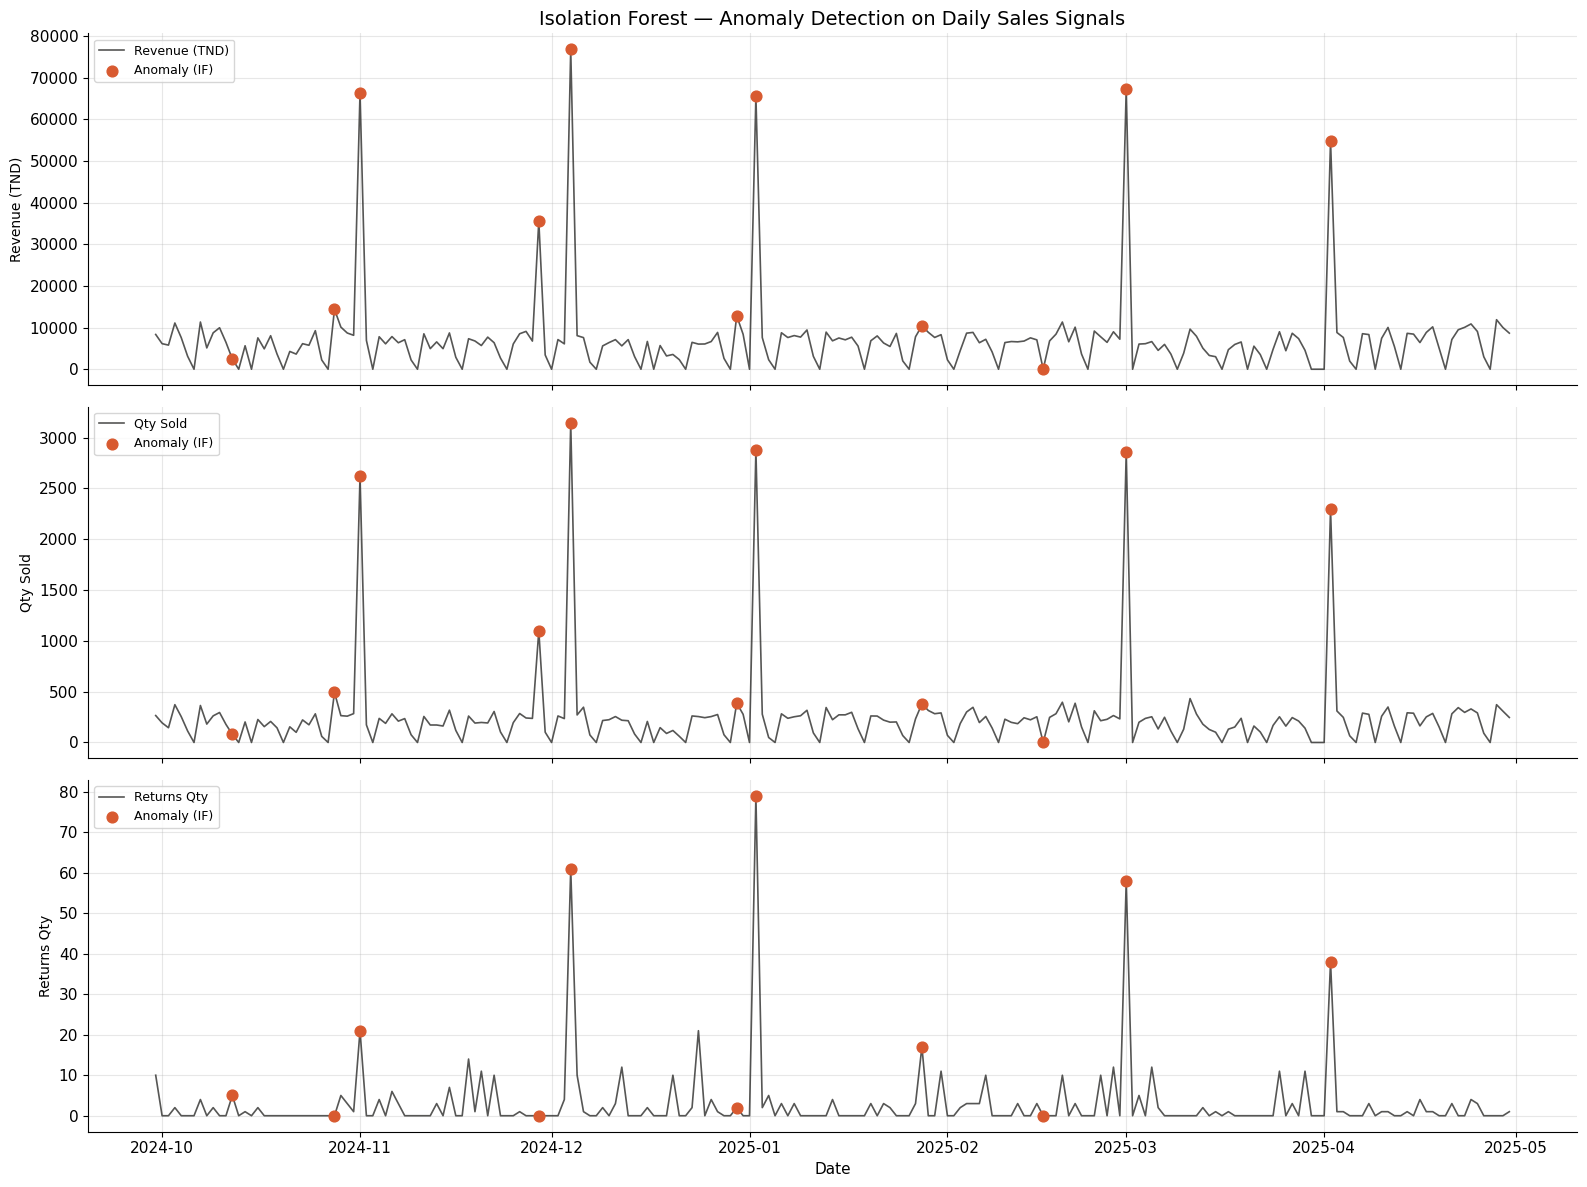

In [86]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

signals = [('total_revenue',    'Revenue (TND)'),
           ('total_qty_sold',   'Qty Sold'),
           ('total_returns_qty','Returns Qty')]

for ax, (col, label) in zip(axes, signals):
    ax.plot(ano_daily.index, ano_daily[col],
            color='#2C2C2A', lw=1.2, label=label, alpha=0.8)
    anomaly_mask = ano_daily['is_anomaly_iso'] == 1
    ax.scatter(ano_daily.index[anomaly_mask], ano_daily[col][anomaly_mask],
               color=C_ano['anomaly'], s=60, zorder=5, label='Anomaly (IF)')
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_title('Isolation Forest — Anomaly Detection on Daily Sales Signals', fontsize=14)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('anomaly_iso_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### C.3 — Isolation Forest: Anomaly Score Distribution

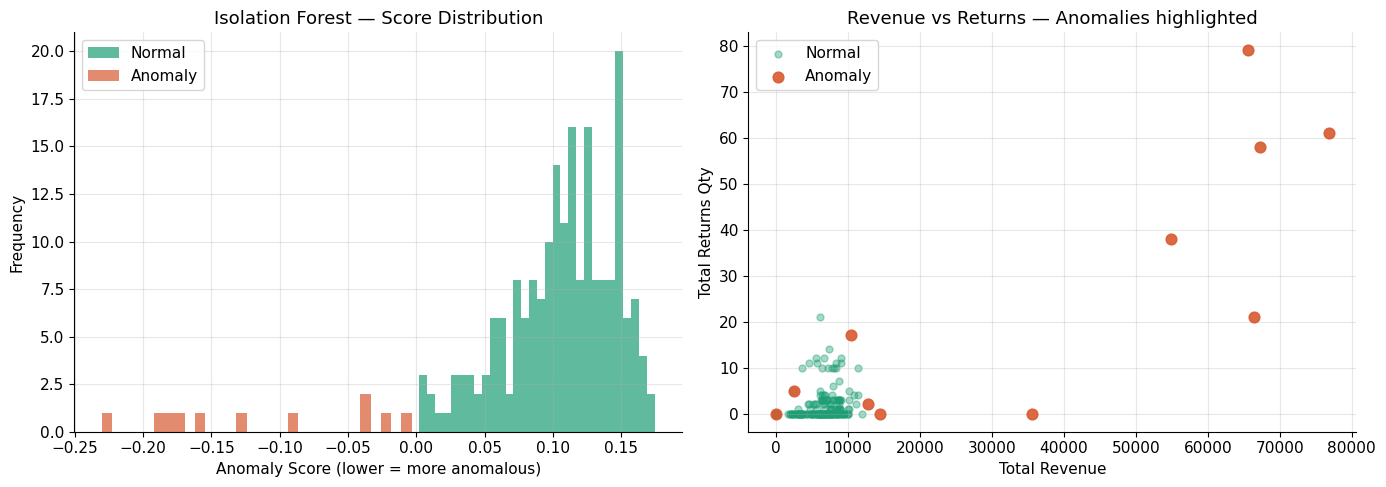

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(iso_scores[iso_labels == 1],  bins=30, color=C_ano['normal'],  alpha=0.7, label='Normal')
axes[0].hist(iso_scores[iso_labels == -1], bins=30, color=C_ano['anomaly'], alpha=0.7, label='Anomaly')
axes[0].set_title('Isolation Forest — Score Distribution', fontsize=13)
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2D scatter: revenue vs returns coloured by anomaly
axes[1].scatter(ano_daily['total_revenue'][iso_labels == 1],
                ano_daily['total_returns_qty'][iso_labels == 1],
                alpha=0.4, s=25, color=C_ano['normal'], label='Normal')
axes[1].scatter(ano_daily['total_revenue'][iso_labels == -1],
                ano_daily['total_returns_qty'][iso_labels == -1],
                alpha=0.9, s=60, color=C_ano['anomaly'], label='Anomaly', zorder=5)
axes[1].set_title('Revenue vs Returns — Anomalies highlighted', fontsize=13)
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Total Returns Qty')
axes[1].legend()

plt.tight_layout()
plt.savefig('anomaly_iso_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### C.4 — Autoencoder: Build & Train

In [88]:
if TF_AVAILABLE:
    input_dim = X_ano_scaled.shape[1]
    bottleneck = max(2, input_dim // 3)

    # ── Architecture
    inputs  = keras.Input(shape=(input_dim,))
    # Encoder
    x = layers.Dense(input_dim * 2, activation='relu')(inputs)
    x = layers.Dense(input_dim,     activation='relu')(x)
    encoded = layers.Dense(bottleneck, activation='relu', name='bottleneck')(x)
    # Decoder
    x = layers.Dense(input_dim,     activation='relu')(encoded)
    x = layers.Dense(input_dim * 2, activation='relu')(x)
    decoded = layers.Dense(input_dim, activation='linear')(x)

    autoencoder = keras.Model(inputs, decoded, name='Autoencoder')
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.summary()

    # Train on ALL data (unsupervised — no labels needed)
    history_ae = autoencoder.fit(
        X_ano_scaled, X_ano_scaled,
        epochs=100, batch_size=32,
        validation_split=0.1,
        shuffle=True,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
    )

    # Plot training loss
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history_ae.history['loss'],     label='Train Loss', color=C_ano['normal'])
    ax.plot(history_ae.history['val_loss'], label='Val Loss',   color=C_ano['anomaly'])
    ax.set_title('Autoencoder — Training Loss (MSE)', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    plt.tight_layout()
    plt.savefig('anomaly_ae_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Autoencoder trained")
else:
    print("⚠ Skipping Autoencoder — TensorFlow not installed")

⚠ Skipping Autoencoder — TensorFlow not installed


### C.5 — Autoencoder: Reconstruction Error & Threshold

In [89]:
if TF_AVAILABLE:
    # Reconstruction error per sample
    X_reconstructed = autoencoder.predict(X_ano_scaled, verbose=0)
    recon_errors     = np.mean(np.square(X_ano_scaled - X_reconstructed), axis=1)

    # Threshold = 95th percentile of reconstruction errors
    ae_threshold = np.percentile(recon_errors, 95)
    ae_labels    = (recon_errors > ae_threshold).astype(int)

    ano_daily['ae_recon_error'] = recon_errors
    ano_daily['is_anomaly_ae']  = ae_labels

    n_ae_anomalies = ae_labels.sum()
    print(f"Autoencoder — {n_ae_anomalies} anomalies detected ({n_ae_anomalies/len(ae_labels):.1%} of days)")
    print(f"Threshold (95th pct): {ae_threshold:.4f}")

    # Reconstruction error over time
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(ano_daily.index, recon_errors, color='#2C2C2A', lw=1, alpha=0.8, label='Reconstruction Error')
    ax.axhline(ae_threshold, color=C_ano['thresh'], lw=1.5, linestyle='--',
               label=f'Threshold (95th pct = {ae_threshold:.4f})')
    anomaly_ae_mask = ae_labels == 1
    ax.scatter(ano_daily.index[anomaly_ae_mask], recon_errors[anomaly_ae_mask],
               color=C_ano['anomaly'], s=50, zorder=5, label='Anomaly (AE)')
    ax.set_title('Autoencoder — Reconstruction Error over Time', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('MSE Reconstruction Error')
    ax.legend()
    plt.tight_layout()
    plt.savefig('anomaly_ae_recon.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠ Skipping — TensorFlow not installed")

⚠ Skipping — TensorFlow not installed


### C.6 — Ensemble: Agreement Between Isolation Forest & Autoencoder

In [90]:
if TF_AVAILABLE:
    # Consensus anomaly = flagged by BOTH models
    ano_daily['consensus_anomaly'] = (
        (ano_daily['is_anomaly_iso'] == 1) & (ano_daily['is_anomaly_ae'] == 1)
    ).astype(int)

    n_consensus = ano_daily['consensus_anomaly'].sum()
    print(f"Consensus anomalies (flagged by both): {n_consensus}")

    # Venn-style counts
    only_iso = ((ano_daily['is_anomaly_iso']==1) & (ano_daily['is_anomaly_ae']==0)).sum()
    only_ae  = ((ano_daily['is_anomaly_iso']==0) & (ano_daily['is_anomaly_ae']==1)).sum()
    both     = n_consensus
    print(f"  Only Isolation Forest : {only_iso}")
    print(f"  Only Autoencoder      : {only_ae}")
    print(f"  Both (consensus)      : {both}")

    # Timeline with consensus
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(ano_daily.index, ano_daily['total_revenue'],
            color='#2C2C2A', lw=1, alpha=0.7, label='Revenue')
    iso_only_mask = (ano_daily['is_anomaly_iso']==1) & (ano_daily['is_anomaly_ae']==0)
    ae_only_mask  = (ano_daily['is_anomaly_iso']==0) & (ano_daily['is_anomaly_ae']==1)
    con_mask      = ano_daily['consensus_anomaly'] == 1

    ax.scatter(ano_daily.index[iso_only_mask], ano_daily['total_revenue'][iso_only_mask],
               color='#F4A261', s=50, label='IF only',        zorder=4)
    ax.scatter(ano_daily.index[ae_only_mask],  ano_daily['total_revenue'][ae_only_mask],
               color=C_ano['thresh'], s=50, label='AE only',  zorder=4)
    ax.scatter(ano_daily.index[con_mask],      ano_daily['total_revenue'][con_mask],
               color=C_ano['anomaly'], s=80, label='Consensus', zorder=5, edgecolors='black')

    ax.set_title('Ensemble Anomaly Detection — Revenue Timeline', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Revenue')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('anomaly_ensemble_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # IF-only summary if no TF
    ano_daily['consensus_anomaly'] = ano_daily['is_anomaly_iso']
    print("Using Isolation Forest only (TensorFlow not available)")

Using Isolation Forest only (TensorFlow not available)


### C.7 — Top Anomalous Days Report

In [91]:
report_cols = ['total_revenue','total_qty_sold','nb_transactions',
               'total_returns_qty','total_discounts',
               'is_anomaly_iso','consensus_anomaly']
report_cols = [c for c in report_cols if c in ano_daily.columns]

top_anomalies = (ano_daily[ano_daily['consensus_anomaly'] == 1][report_cols]
                 .sort_values('total_revenue', ascending=False))

print(f"Top anomalous days ({len(top_anomalies)} total):")
print(top_anomalies.head(20).to_string())

Top anomalous days (11 total):
            total_revenue  total_qty_sold  nb_transactions  total_returns_qty  total_discounts  is_anomaly_iso  consensus_anomaly
date                                                                                                                             
2024-12-04   76788.025005          3148.0             88.0               61.0              0.0               1                  1
2025-03-01   67274.406962          2858.0             25.0               58.0              0.0               1                  1
2024-11-01   66369.792875          2620.0             87.0               21.0              0.0               1                  1
2025-01-02   65586.995054          2879.0             80.0               79.0              0.0               1                  1
2025-04-02   54818.151091          2295.0             88.0               38.0              0.0               1                  1
2024-11-29   35577.452052          1098.0            300.0 

### C.8 — Anomaly Detection on Customer Payment Signals (Isolation Forest)

In [92]:
# Apply Isolation Forest on credit/payment features (customer level)
scaler_cred = StandardScaler()
X_cred_scaled = scaler_cred.fit_transform(ano_credit.fillna(0))

iso_cred = IsolationForest(n_estimators=200, contamination=0.05,
                            random_state=42, n_jobs=-1)
iso_cred.fit(X_cred_scaled)

cred_labels = iso_cred.predict(X_cred_scaled)
cred_scores = iso_cred.decision_function(X_cred_scaled)

df_cred['payment_anomaly']       = (cred_labels == -1).astype(int)
df_cred['payment_anomaly_score'] = cred_scores

n_cred_ano = (cred_labels == -1).sum()
print(f"Payment anomalies detected: {n_cred_ano} customers ({n_cred_ano/len(cred_labels):.1%})")

# Top anomalous customers
cred_report_cols = ['ClientID','avg_payment_delay','max_payment_delay',
                    'nb_unpaid','total_receivable','payment_anomaly_score']
cred_report_cols = [c for c in cred_report_cols if c in df_cred.columns]

print("\nTop 10 most anomalous customers (payment behaviour):")
print(df_cred[df_cred['payment_anomaly']==1]
      .nsmallest(10, 'payment_anomaly_score')[cred_report_cols]
      .to_string(index=False))

Payment anomalies detected: 2 customers (8.0%)

Top 10 most anomalous customers (payment behaviour):
 ClientID  avg_payment_delay  max_payment_delay  nb_unpaid  total_receivable  payment_anomaly_score
        7           2.330113                 17       4412      7.882544e+07              -0.164713
       10           4.628627                 17        202      9.429011e+04              -0.011284


### C.9 — Payment Anomaly Visualisation

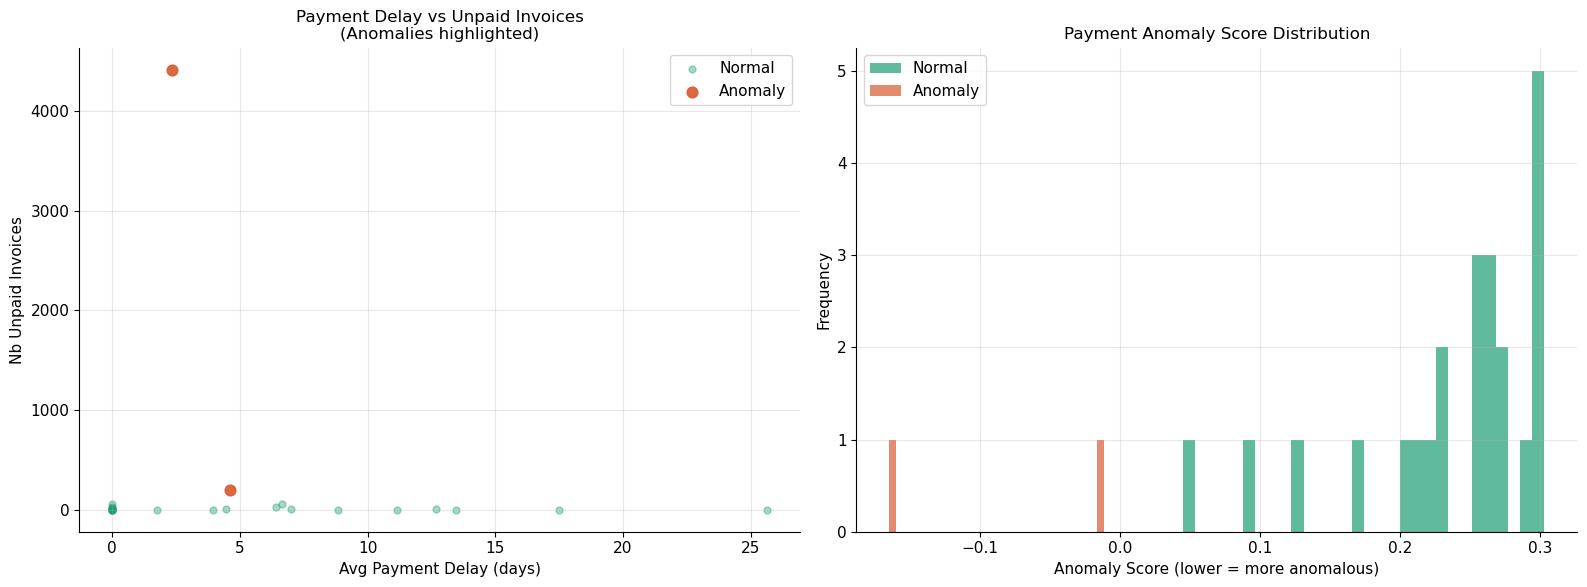

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# avg_payment_delay vs nb_unpaid
ax = axes[0]
normal_mask = df_cred['payment_anomaly'] == 0
ano_mask    = df_cred['payment_anomaly'] == 1
ax.scatter(df_cred['avg_payment_delay'][normal_mask],
           df_cred['nb_unpaid'][normal_mask],
           alpha=0.4, s=25, color=C_ano['normal'], label='Normal')
ax.scatter(df_cred['avg_payment_delay'][ano_mask],
           df_cred['nb_unpaid'][ano_mask],
           alpha=0.9, s=60, color=C_ano['anomaly'], label='Anomaly', zorder=5)
ax.set_title('Payment Delay vs Unpaid Invoices\n(Anomalies highlighted)', fontsize=12)
ax.set_xlabel('Avg Payment Delay (days)')
ax.set_ylabel('Nb Unpaid Invoices')
ax.legend()

# Anomaly score distribution
ax = axes[1]
ax.hist(cred_scores[cred_labels == 1],  bins=30, color=C_ano['normal'],  alpha=0.7, label='Normal')
ax.hist(cred_scores[cred_labels == -1], bins=30, color=C_ano['anomaly'], alpha=0.7, label='Anomaly')
ax.set_title('Payment Anomaly Score Distribution', fontsize=12)
ax.set_xlabel('Anomaly Score (lower = more anomalous)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('anomaly_payment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Results Summary — Anomaly Detection

| Aspect | Detail |
|--------|--------|
| Sales signals | Daily revenue, qty sold, transactions, returns, discounts + 7-day rolling z-scores |
| Payment signals | Avg/max payment delay, unpaid invoices, receivables, discounts, returns |
| Model A | **Isolation Forest** — contamination=5%, 200 trees |
| Model B | **Autoencoder** — encoder-bottleneck-decoder, MSE loss, threshold=95th pct |
| Ensemble | Consensus = flagged by **both** models (higher confidence) |
| Business use — Sales | Investigate abnormal revenue dips/spikes, seasonal fraud, data entry errors |
| Business use — Payments | Flag high-risk customers for credit hold; trigger collection workflows |
| Next step | Connect to alerting system (email/Slack) when new anomalies are detected daily |

---
## 🏁 All Goals Complete (4 Core + 2 Advanced)

| Goal | Type | Objective | Models |
|------|------|-----------|--------|
| Goal 1 | Core | Sales Volume Forecasting | SARIMA + XGBoost TS |
| Goal 2 | Core | Customer Segmentation | K-Means + DBSCAN |
| Goal 3 | Core | Creditworthiness Classification | Logistic Regression + Random Forest |
| Goal 4 | Core | Margin & Price Fluctuation | Ridge + XGBoost Regressor |
| Advanced A | Advanced | Product Recommendation System | Item-Based CF + SVD |
| Advanced B | Advanced | Anomaly Detection | Isolation Forest + Autoencoder |